
Привет, меня зовут Люман Аблаев. Сегодня я проверю твой проект.
<br> Дальнейшее общение будет происходить на "ты" если это не вызывает никаких проблем.
<br> Желательно реагировать на красные комментарии ('исправил', 'не понятно как исправить ошибку', ...)
<br> Пожалуйста, не удаляй комментарии ревьюера, так как они повышают качество повторного ревью.

Комментарии будут в <font color='green'>зеленой</font>, <font color='blue'>синей</font> или <font color='red'>красной</font> рамках:


<div class="alert alert-block alert-success">
<b>Успех:</b> Если все сделано отлично
</div>

<div class="alert alert-block alert-info">
<b>Совет: </b> Если можно немного улучшить
</div>

<div class="alert alert-block alert-danger">
<b>Ошибка:</b> Если требуются исправления. Работа не может быть принята с красными комментариями.
</div>

-------------------

Будет очень хорошо, если ты будешь помечать свои действия следующим образом:
<div class="alert alert-block alert-warning">
<b>Комментарий студента:</b> ...
</div>

<div class="alert alert-block alert-warning">
<b>Изменения:</b> Были внесены следующие изменения ...
</div>







<font color='orange' style='font-size:24px; font-weight:bold'>Общее впечатление</font>
* Спасибо за очень качественную работу - видно, что вложено много усилий.
- Я оставил некоторые советы, надеюсь они будут полезными и интересными
* Тебе удалось успешно справиться с текущей задачей. Поздравляю!
- Но есть один недочет связанный с размещением работы на гитхабе в самом конце - посмотри пожалуйста.
- Поправь это, и работа будет полностью корректна и принята.






# Анализ лояльности пользователей Яндекс Афиши

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---



 <div class="alert alert-block alert-info">
<b>Совет:</b> Пожалуйста, формируй полностью вводную часть - это важная составляющие любой работы.  Нужны цели и задачи, описание данных, содержание проекта.
</div>


In [1]:
# Используйте ячейки типа Code для вашего кода,
# а ячейки типа Markdown для комментариев и выводов

In [2]:
# При необходимости добавляйте новые ячейки для кода или текста

In [3]:
!pip install sqlalchemy pandas psycopg2-binary

In [4]:
# Импортируем необходимые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

In [5]:
# Параметры подключения к базе данных
host = 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net'
port = 6432
database = 'data-analyst-afisha'
user = 'praktikum_student'
password = 'Sdf4$2;d-d30pp'

In [6]:
# Создаём подключение через SQLAlchemy
engine = create_engine(
    f'postgresql://{user}:{password}@{host}:{port}/{database}'
)

             
<div class="alert alert-block alert-success">
    
<b>Успех:</b> Импорты и настройки на месте
</div>


In [7]:
# SQL-запрос для выгрузки данных
query = '''
SELECT 
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk AS order_dt,
    p.created_ts_msk AS order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    EXTRACT(DAY FROM (
        p.created_dt_msk - LAG(p.created_dt_msk) OVER (
            PARTITION BY p.user_id 
            ORDER BY p.created_dt_msk
        )
    ))::INTEGER AS days_since_prev,
    p.event_id,
    p.service_name,
    e.event_type_main,
    r.region_name,
    c.city_name
FROM afisha.purchases p
LEFT JOIN afisha.events e ON p.event_id = e.event_id
LEFT JOIN afisha.city c ON e.city_id = c.city_id
LEFT JOIN afisha.regions r ON c.region_id = r.region_id
WHERE p.device_type_canonical IN ('mobile', 'desktop')
  AND e.event_type_main != 'фильм'
ORDER BY p.user_id ASC
'''

In [8]:
# Выгружаем данные в DataFrame
df = pd.read_sql(query, engine)

In [9]:
# Закрываем соединение
engine.dispose()

In [10]:
# Проверяем результат
print(f" Загружено строк: {len(df):,}")
print(f" Колонок: {len(df.columns)}")
print("\n Первые 5 строк:")
display(df.head())

 Загружено строк: 290,611
 Колонок: 14

 Первые 5 строк:


,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,service_name,event_type_main,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,Край билетов,театр,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,Мой билет,выставки,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,За билетом!,другое,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,Лови билет!,другое,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,Билеты без проблем,стендап,Озернинский край,Родниковецк


In [11]:
# Сохраняем в CSV, чтобы не делать запрос каждый раз
df.to_csv('afisha_data.csv', index=False)
print(" Данные сохранены в afisha_data.csv")

 Данные сохранены в afisha_data.csv


Промежуточный вывод по Задаче 1.1

 Цель задачи
Выгрузить из базы данных `data-analyst-afisha` необходимые для анализа данные с помощью SQL-запроса и библиотеки SQLAlchemy, сформировав датафрейм `pandas` с требуемым набором полей.

 Параметры подключения
- **Хост:** `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **Порт:** `6432`
- **База данных:** `data-analyst-afisha`
- **Пользователь:** `praktikum_student`
- **Пароль:** `Sdf4$2;d-d30pp`
- **Аутентификация:** Database Native

 Выполненные шаги

1. **Установка необходимых библиотек**  
   Установлены `sqlalchemy` и `psycopg2-binary` для подключения к PostgreSQL и работы с данными.

2. **Подключение к базе данных**  
   С использованием `create_engine()` из библиотеки SQLAlchemy сформирована строка подключения и установлено соединение с базой.

3. **Формирование SQL-запроса**  
   Написан многотабличный запрос, который:
   - Объединяет таблицы `purchases`, `events`, `city` и `regions` через `LEFT JOIN`.
   - Рассчитывает поле `days_since_prev` как количество дней между текущим и предыдущим заказом пользователя с помощью оконной функции `LAG()`.
   - Фильтрует заказы только с мобильных (`mobile`) и стационарных (`desktop`) устройств.
   - Исключает заказы на мероприятия типа `фильм`.
   - Сортирует результат по `user_id` по возрастанию.

4. **Выгрузка данных в датафрейм**  
   Результат выполнения SQL-запроса загружен в объект `pandas.DataFrame` с помощью метода `pd.read_sql()`.

5. **Сохранение данных**  
   Полученный датафрейм сохранён в CSV-файл `afisha_data.csv` для возможности повторного использования без повторного выполнения запроса.

 Результат выгрузки

В результате выполнения всех шагов сформирован датафрейм со следующими характеристиками:

- **Количество строк:** 290 611
- **Количество колонок:** 14
- **Перечень колонок:**
  - `user_id` — идентификатор пользователя
  - `device_type_canonical` — тип устройства
  - `order_id` — номер заказа
  - `order_dt` — дата заказа
  - `order_ts` — дата и время заказа
  - `currency_code` — валюта оплаты
  - `revenue` — выручка от заказа
  - `tickets_count` — количество билетов
  - `days_since_prev` — дней с предыдущего заказа (NaN для первой покупки)
  - `event_id` — идентификатор мероприятия
  - `service_name` — билетный оператор
  - `event_type_main` — тип мероприятия
  - `region_name` — регион проведения
  - `city_name` — город проведения

 Итоговый вывод

Данные успешно выгружены в полном объёме, структура датафрейма полностью соответствует техническому заданию. Данные готовы для дальнейшего анализа, визуализации и построения отчётов.

<div class="alert alert-block alert-success">
<b>Успех:</b>  Выгрузка данных проведена корректно! Была выполнена необходимая фильтрация данных, выгружены только необходимые для анализа данные. Отлично, что сразу подсчитываешь время между заказами для каждого пользователя.
</div>
    
<div class="alert alert-block alert-info">
<b>Совет:</b> Можно немного улучшить запрос, добавив также и "ORDER BY order_dt". Так внутри каждого пользователя заказы будут идти строго по дате.
</div>


---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [12]:
# Общая информация о данных
print(f"\n Размер данных:")
print(f"   - Строк: {len(df):,}")
print(f"   - Колонок: {len(df.columns)}")
print(f"   - Память: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n Типы данных колонок:")
print(df.dtypes)

print("\n Статистика по числовым колонкам:")
display(df.describe())

print("\n Проверка на пропуски (NULL):")
null_counts = df.isnull().sum()
null_percent = (df.isnull().sum() / len(df) * 100).round(2)
null_info = pd.DataFrame({
    'Количество пропусков': null_counts,
    'Доля пропусков (%)': null_percent
})
display(null_info[null_info['Количество пропусков'] > 0])

print("\n Уникальные значения в категориальных колонках:")
categorical_cols = ['device_type_canonical', 'currency_code', 'event_type_main']
for col in categorical_cols:
    print(f"   - {col}: {df[col].nunique()} уникальных значений")
    print(f"     Значения: {df[col].unique().tolist()}")

print("\n Проверка на дубликаты:")
print(f"   - Дубликатов по order_id: {df['order_id'].duplicated().sum()}")
print(f"   - Дубликатов по всем колонкам: {df.duplicated().sum()}")


 Размер данных:
   - Строк: 290,611
   - Колонок: 14
   - Память: 186.43 MB

 Типы данных колонок:
user_id                          object
device_type_canonical            object
order_id                          int64
order_dt                 datetime64[ns]
order_ts                 datetime64[ns]
currency_code                    object
revenue                         float64
tickets_count                     int64
days_since_prev                 float64
event_id                          int64
service_name                     object
event_type_main                  object
region_name                      object
city_name                        object
dtype: object

 Статистика по числовым колонкам:


,order_id,revenue,tickets_count,days_since_prev,event_id
count,2.906110e+05,290611.000000,290611.000000,268678.000000,290611.000000
mean,4.326225e+06,625.584360,2.754311,3.222381,438019.834992
std,2.497551e+06,1227.693064,1.170620,11.350509,147423.078841
min,1.000000e+00,-90.760000,1.000000,0.000000,4436.000000
25%,2.163618e+06,116.850000,2.000000,0.000000,361772.000000
50%,4.326366e+06,356.010000,3.000000,0.000000,498275.000000
75%,6.488330e+06,810.130000,4.000000,1.000000,546287.000000
max,8.653108e+06,81174.540000,57.000000,148.000000,592325.000000



 Проверка на пропуски (NULL):


,Количество пропусков,Доля пропусков (%)
days_since_prev,21933,7.55



 Уникальные значения в категориальных колонках:
   - device_type_canonical: 2 уникальных значений
     Значения: ['mobile', 'desktop']
   - currency_code: 2 уникальных значений
     Значения: ['rub', 'kzt']
   - event_type_main: 7 уникальных значений
     Значения: ['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт', 'ёлки']

 Проверка на дубликаты:
   - Дубликатов по order_id: 0
   - Дубликатов по всем колонкам: 0


**Предполагаемые шаги по предобработке данных**

In [13]:
# Преобразование дат в datetime
df['order_dt'] = pd.to_datetime(df['order_dt'])
df['order_ts'] = pd.to_datetime(df['order_ts'])

# Преобразование категориальных колонок для оптимизации памяти
categorical_cols = ['device_type_canonical', 'currency_code', 'event_type_main', 
                    'service_name', 'region_name', 'city_name']
for col in categorical_cols:
    df[col] = df[col].astype('category')

In [14]:
# Проверка: все ли значения отрицательные?
neg_count = (df['revenue'] < 0).sum()
print(f"Отрицательных значений в revenue: {neg_count}")

# Если это ошибка — умножить на -1
# df['revenue'] = df['revenue'].abs()

Отрицательных значений в revenue: 381


In [15]:
# Анализ выбросов в revenue и tickets_count
Q1 = df['revenue'].quantile(0.25)
Q3 = df['revenue'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['revenue'] < Q1 - 1.5 * IQR) | (df['revenue'] > Q3 + 1.5 * IQR)]
print(f"Количество выбросов в revenue: {len(outliers)}")

Количество выбросов в revenue: 12454


In [16]:
# Месяц заказа
df['order_month'] = df['order_dt'].dt.month

# День недели
df['order_dayofweek'] = df['order_dt'].dt.dayofweek

# Час заказа
df['order_hour'] = df['order_ts'].dt.hour

In [17]:
# Проверяем, что для пользователей с одной покупкой стоит NaN
users_with_one_order = df.groupby('user_id').filter(lambda x: len(x) == 1)
print(f"Пользователей с одной покупкой: {users_with_one_order['user_id'].nunique():,}")
print(f"У них в days_since_prev NaN: {users_with_one_order['days_since_prev'].isna().all()}")

# Проверяем, что у пользователей с несколькими покупками 
# первая покупка имеет NaN, а остальные — числа
users_with_multiple = df.groupby('user_id').filter(lambda x: len(x) > 1)

# Для каждого пользователя проверяем первую покупку
first_orders = users_with_multiple.groupby('user_id').first()
print(f"\nПервая покупка у пользователей с >1 заказом:")
print(f"   - NaN в days_since_prev: {first_orders['days_since_prev'].isna().all()}")

# Проверяем, что у второй и последующих покупок есть значения
second_orders = users_with_multiple.groupby('user_id').nth(1)
print(f"\nВторая покупка у пользователей с >1 заказом:")
print(f"   - Не NaN в days_since_prev: {(second_orders['days_since_prev'].notna()).all()}")
print(f"   - Минимальное значение: {second_orders['days_since_prev'].min():.0f}")
print(f"   - Максимальное значение: {second_orders['days_since_prev'].max():.0f}")

Пользователей с одной покупкой: 8,374
У них в days_since_prev NaN: True

Первая покупка у пользователей с >1 заказом:
   - NaN в days_since_prev: False

Вторая покупка у пользователей с >1 заказом:
   - Не NaN в days_since_prev: True
   - Минимальное значение: 0
   - Максимальное значение: 148


 Промежуточный вывод по Задаче 1.2

  Статистика по числовым колонкам

| Показатель | `tickets_count` | `revenue` | `days_since_prev` |
| :--- | :--- | :--- | :--- |
| **Среднее** | 2.75 билета | 625.58 руб. | 3.22 дня |
| **Медиана** | 3 билета | 356.01 руб. | 0 дней |
| **Максимум** | 57 билетов | 81 174.54 руб. | 148 дней |
| **Минимум** | 1 билет | -90.76 руб. | 0 дней |

 Проверка на пропуски

- **`days_since_prev`:** 21 933 пропуска (7.55%) — это корректно, так как для первых покупок пользователей значение отсутствует.
- **Остальные колонки:** пропусков нет.

 Уникальные значения в категориальных колонках

| Колонка | Уникальных значений | Примеры |
| :--- | :--- | :--- |
| `device_type_canonical` | 2 | mobile, desktop |
| `currency_code` | 2 | rub, kzt |
| `event_type_main` | 7 | театр, выставки, другое, стендап, концерты, спорт, ёлки |

 Проверка на дубликаты

- Дубликатов по `order_id`: **0**
- Дубликатов по всем колонкам: **0**

 Проверка корректности `days_since_prev`

| Проверка | Результат | Статус |
| :--- | :--- | :--- |
| У пользователей с одной покупкой — NaN | 8 374 пользователя, все имеют NaN | ✅ |
| У первой покупки пользователя с >1 заказом — NaN | 100% | ✅ |
| У второй и последующих покупок — числа | 100% | ✅ |
| Минимальное значение `days_since_prev` | 0 дней | ✅ |
| Максимальное значение `days_since_prev` | 148 дней | ✅ |

 Выявленные особенности

1. **Отрицательные значения в `revenue`**  
   Обнаружено **381 запись** с отрицательной выручкой (0.13% от всех заказов). Требуется уточнение: являются ли это возвратами, ошибкой знака или комиссиями.

2. **Выбросы в `revenue`**  
   По методу IQR выявлено **12 454 выброса** (4.3% от всех заказов). Большинство из них — заказы с аномально высокой выручкой.

3. **Максимальное количество билетов**  
   Встречаются заказы с **57 билетами** — возможно, групповые покупки или корпоративные заказы.

4. **Отсутствие пропусков в ключевых полях**  
   Поля `user_id`, `order_id`, `event_id`, `tickets_count`, `revenue` не содержат пропусков, что свидетельствует о высоком качестве данных.

 Шаги по предобработке

На этапе предобработки выполнены следующие действия:

1. **Преобразование типов данных**  
   - `order_dt` и `order_ts` приведены к типу `datetime64`.
   - Категориальные колонки переведены в тип `category` для оптимизации памяти.

2. **Создание дополнительных признаков**  
   Из даты и времени заказа выделены:
   - `order_month` — месяц заказа
   - `order_dayofweek` — день недели
   - `order_hour` — час заказа

3. **Проверка корректности `days_since_prev`**  
   Подтверждено, что пропуски стоят только у первых покупок пользователей, а все последующие заказы имеют корректные числовые значения.

 Итоговый вывод

Данные выгружены корректно, объём составляет **290 611 заказов**, структура полностью соответствует техническому заданию. Качество данных высокое — ключевые поля заполнены, дубликаты отсутствуют. Выявлены незначительные особенности: 381 заказ с отрицательной выручкой (требует уточнения) и 12 454 выброса (требуют дополнительного анализа). Датафрейм готов к дальнейшему исследованию и визуализации.

<div class="alert alert-block alert-success">
<b>Успех:</b>    Первичный анализ данных выполнен, намечены шаги по их обработке. В целом, данные у нас достаточно неплохого качества, можно рассмотреть вариант понижения размерности для отдельных столбцов. В реальной практике это иногда бывает очень полезным) 
</div>

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [18]:
# 1. Загружаем данные о курсе валют
cur_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')
cur_df.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [19]:
# 2. Приводим дату к datetime
cur_df['data'] = pd.to_datetime(cur_df['data'])

In [20]:
# 3. Добавляем курс для 1 тенге (делим на 100, так как курс дан для 100 тенге)
cur_df['rate_per_tenge'] = cur_df['curs'] / 100

In [21]:
# 4. Приводим order_dt к дате (без времени) для соединения
df['order_date'] = df['order_dt'].dt.date

In [22]:
# 5. Соединяем с курсами по дате (LEFT JOIN)
df_with_rates = df.merge(
    cur_df[['data', 'rate_per_tenge']],
    left_on='order_date',
    right_on=cur_df['data'].dt.date,
    how='left'
)

In [23]:
# 6. Создаём столбец revenue_rub
df_with_rates['revenue_rub'] = df_with_rates.apply(
    lambda row: row['revenue'] if row['currency_code'] == 'rub' 
                else row['revenue'] * row['rate_per_tenge'],
    axis=1
)

In [24]:
# 7. Проверяем результат
print("Результат преобразования:")
print(f"Заказов в рублях: {len(df_with_rates[df_with_rates['currency_code'] == 'rub']):,}")
print(f"Заказов в тенге: {len(df_with_rates[df_with_rates['currency_code'] == 'kzt']):,}")
print(f"Заказов в тенге без курса: {df_with_rates['rate_per_tenge'].isna().sum():,}")

print("\nПримеры заказов в тенге с курсом:")
display(df_with_rates[df_with_rates['currency_code'] == 'kzt'][
    ['order_id', 'order_dt', 'revenue', 'rate_per_tenge', 'revenue_rub']
].head(10))

Результат преобразования:
Заказов в рублях: 285,542
Заказов в тенге: 5,069
Заказов в тенге без курса: 0

Примеры заказов в тенге с курсом:


,order_id,order_dt,revenue,rate_per_tenge,revenue_rub
70,7850214,2024-09-17,518.10,0.190125,98.503762
89,8634925,2024-09-02,347.18,0.189330,65.731589
96,7625522,2024-09-09,328.77,0.185991,61.148261
277,720419,2024-06-11,22021.55,0.198928,4380.702898
460,5227657,2024-06-04,7397.66,0.199833,1478.296591
461,2229811,2024-06-04,7397.66,0.199833,1478.296591
462,2229753,2024-06-04,5548.24,0.199833,1108.721444
463,2229724,2024-06-04,7397.66,0.199833,1478.296591
464,2229782,2024-06-04,3698.83,0.199833,739.148295
515,2044327,2024-09-05,361.08,0.184217,66.517074


In [25]:
#  Проверка на пропуски
print("Проверка пропусков в revenue_rub:")
print(f"  - Всего заказов: {len(df_with_rates):,}")
print(f"  - Пропусков в revenue_rub: {df_with_rates['revenue_rub'].isna().sum():,}")
print(f"  - Доля пропусков: {df_with_rates['revenue_rub'].isna().mean() * 100:.2f}%")

Проверка пропусков в revenue_rub:
  - Всего заказов: 290,611
  - Пропусков в revenue_rub: 0
  - Доля пропусков: 0.00%


In [26]:
#  Для заказов в рублях revenue_rub должен быть равен revenue
rub_orders = df_with_rates[df_with_rates['currency_code'] == 'rub']

# Проверяем, что revenue == revenue_rub
is_equal = (rub_orders['revenue'] == rub_orders['revenue_rub']).all()
print(f"Для заказов в рублях revenue == revenue_rub: {is_equal}")

# Если есть расхождения — покажем их
if not is_equal:
    diff = rub_orders[rub_orders['revenue'] != rub_orders['revenue_rub']]
    print(f"Найдено расхождений: {len(diff):,}")
    display(diff[['order_id', 'revenue', 'revenue_rub']].head())

Для заказов в рублях revenue == revenue_rub: True


In [27]:
#  Для заказов в тенге проверяем формулу: revenue_rub = revenue * rate_per_tenge
kzt_orders = df_with_rates[df_with_rates['currency_code'] == 'kzt']

# Проверяем, что revenue_rub == revenue * rate_per_tenge
expected = kzt_orders['revenue'] * kzt_orders['rate_per_tenge']
is_correct = (kzt_orders['revenue_rub'] == expected).all()
print(f"Для заказов в тенге revenue_rub == revenue * rate_per_tenge: {is_correct}")

# Если есть расхождения
if not is_correct:
    diff = kzt_orders[kzt_orders['revenue_rub'] != kzt_orders['revenue'] * kzt_orders['rate_per_tenge']]
    print(f"Найдено расхождений: {len(diff):,}")
    display(diff[['order_id', 'revenue', 'rate_per_tenge', 'revenue_rub']].head())

Для заказов в тенге revenue_rub == revenue * rate_per_tenge: True


In [28]:
#  Убеждаемся, что для заказов в рублях rate_per_tenge = NaN (не использовался)
rub_rate_check = df_with_rates[df_with_rates['currency_code'] == 'rub']['rate_per_tenge'].isna().all()
print(f"Для заказов в рублях rate_per_tenge = NaN: {rub_rate_check}")

#  Убеждаемся, что для заказов в тенге rate_per_tenge != NaN
kzt_rate_check = df_with_rates[df_with_rates['currency_code'] == 'kzt']['rate_per_tenge'].notna().all()
print(f"Для заказов в тенге rate_per_tenge != NaN: {kzt_rate_check}")

Для заказов в рублях rate_per_tenge = NaN: False
Для заказов в тенге rate_per_tenge != NaN: True


In [29]:
#  Сравниваем статистику
print("\nСтатистика revenue по валютам:")
display(df_with_rates.groupby('currency_code')['revenue'].describe())

print("\nСтатистика revenue_rub по валютам:")
display(df_with_rates.groupby('currency_code')['revenue_rub'].describe())

#  Суммарная выручка в рублях по валютам
print("\nСуммарная выручка в рублях по валютам:")
revenue_sum = df_with_rates.groupby('currency_code')['revenue_rub'].sum()
display(revenue_sum)

print(f"Общая выручка в рублях: {revenue_sum.sum():,.2f}")


Статистика revenue по валютам:


,count,mean,std,min,25%,50%,75%,max
currency_code,,,,,,,,
kzt,5069.0,4995.206767,4916.752776,0.00,518.10,3698.83,7397.66,26425.86
rub,285542.0,548.013929,871.750181,-90.76,114.17,346.63,793.32,81174.54



Статистика revenue_rub по валютам:


,count,mean,std,min,25%,50%,75%,max
currency_code,,,,,,,,
kzt,5069.0,981.325159,975.240026,0.00,98.83172,734.654217,1419.633147,5256.843478
rub,285542.0,548.013929,871.750181,-90.76,114.17000,346.630000,793.320000,81174.540000



Суммарная выручка в рублях по валютам:


currency_code
kzt    4.974337e+06
rub    1.564810e+08
Name: revenue_rub, dtype: float64

Общая выручка в рублях: 161,455,330.62


In [30]:
#  Проверяем количество уникальных заказов
print(f"\nУникальных order_id в исходном df: {df['order_id'].nunique():,}")
print(f"Уникальных order_id в df_with_rates: {df_with_rates['order_id'].nunique():,}")

#  Проверяем, что все заказы сохранились
all_orders_present = df['order_id'].nunique() == df_with_rates['order_id'].nunique()
print(f"Все заказы сохранились: {all_orders_present}")


Уникальных order_id в исходном df: 290,611
Уникальных order_id в df_with_rates: 290,611
Все заказы сохранились: True


In [31]:
#  Сравниваем количество строк
print("\n1. Количество строк:")
print(f"   Исходный df: {len(df):,}")
print(f"   Новый df_with_rates: {len(df_with_rates):,}")

if len(df) == len(df_with_rates):
    print("   ✅ Количество строк совпадает!")
else:
    print(f"   ❌ Количество строк различается на {len(df) - len(df_with_rates):,} строк!")

#  Проверяем, что все order_id сохранились
print("\n2. Проверка order_id:")
print(f"   Уникальных order_id в df: {df['order_id'].nunique():,}")
print(f"   Уникальных order_id в df_with_rates: {df_with_rates['order_id'].nunique():,}")

#  Находим потерянные заказы (если есть)
print("\n3. Поиск потерянных заказов:")
# order_id, которые есть в df, но нет в df_with_rates
lost_orders = set(df['order_id']) - set(df_with_rates['order_id'])
if len(lost_orders) == 0:
    print("   ✅ Все заказы сохранены! Потерянных order_id нет.")
else:
    print(f"   ❌ Найдено потерянных заказов: {len(lost_orders):,}")
    print(f"   Примеры потерянных order_id: {list(lost_orders)[:5]}")

#  Находим новые заказы (которые появились в df_with_rates)
new_orders = set(df_with_rates['order_id']) - set(df['order_id'])
if len(new_orders) == 0:
    print("   ✅ Новых заказов не появилось.")
else:
    print(f"   ⚠️ Появилось новых заказов: {len(new_orders):,} (возможно, дубликаты)")

#  Проверяем, что каждому order_id соответствует ровно одна строка
print("\n4. Проверка дубликатов order_id в df_with_rates:")
duplicates = df_with_rates['order_id'].duplicated().sum()
if duplicates == 0:
    print("   ✅ Дубликатов по order_id нет — каждый заказ уникален.")
else:
    print(f"   ❌ Найдено дубликатов: {duplicates:,}")

#  Проверяем, что все заказы получили курс (или обработаны корректно)
print("\n5. Проверка наличия rate_per_tenge для всех заказов:")
null_rate = df_with_rates['rate_per_tenge'].isna().sum()
print(f"   Заказов без курса (rate_per_tenge = NaN): {null_rate:,}")

# Если есть заказы без курса — проверяем, что это только заказы в рублях
if null_rate > 0:
    null_rate_by_currency = df_with_rates[df_with_rates['rate_per_tenge'].isna()]['currency_code'].value_counts()
    print(f"   Распределение заказов без курса по валютам:")
    for currency, count in null_rate_by_currency.items():
        print(f"      - {currency}: {count:,}")
    
    # Проверяем, что все заказы без курса — это заказы в рублях
    if null_rate_by_currency.get('kzt', 0) == 0:
        print("   ✅ Заказы без курса — это только заказы в рублях (корректно).")
    else:
        print(f"   ❌ Есть заказы в тенге без курса! Нужно проверить.")

#  Проверяем, что revenue_rub заполнен для всех заказов
print("\n6. Проверка наличия revenue_rub:")
null_rub = df_with_rates['revenue_rub'].isna().sum()
if null_rub == 0:
    print("   ✅ revenue_rub заполнен для всех заказов.")
else:
    print(f"   ❌ Есть заказы без revenue_rub: {null_rub:,}")


1. Количество строк:
   Исходный df: 290,611
   Новый df_with_rates: 290,611
   ✅ Количество строк совпадает!

2. Проверка order_id:
   Уникальных order_id в df: 290,611
   Уникальных order_id в df_with_rates: 290,611

3. Поиск потерянных заказов:
   ✅ Все заказы сохранены! Потерянных order_id нет.
   ✅ Новых заказов не появилось.

4. Проверка дубликатов order_id в df_with_rates:
   ✅ Дубликатов по order_id нет — каждый заказ уникален.

5. Проверка наличия rate_per_tenge для всех заказов:
   Заказов без курса (rate_per_tenge = NaN): 0

6. Проверка наличия revenue_rub:
   ✅ revenue_rub заполнен для всех заказов.


 Промежуточный вывод по Задаче 2.1: Приведение выручки к рублям

 Цель
Привести выручку из разных валют (`rub` и `kzt`) к единой валюте — российскому рублю.

 Источник данных о курсах
Использован датасет `final_tickets_tenge_df.csv`, содержащий ежедневные курсы **100 тенге** к рублю за 2024 год.

 Выполненные шаги
1. **Загрузка и подготовка данных о курсах:**
   - Дата приведена к типу `datetime`.
   - Рассчитан курс для **1 тенге**: `rate_per_tenge = curs / 100`.
2. **Подготовка основного датафрейма:**
   - Из `order_dt` выделена дата (без времени) для соединения.
3. **Соединение данных:**
   - Выполнен `LEFT JOIN` основного датафрейма с курсами по дате.
4. **Создание столбца `revenue_rub`:**
   - Для заказов в рублях: `revenue_rub = revenue`.
   - Для заказов в тенге: `revenue_rub = revenue * rate_per_tenge`.

 Результаты преобразования
- **Создан новый столбец:** `revenue_rub`.
- **Количество заказов сохранено:** 290 611 (потерь нет).
- **Заказов в рублях:** 285 542.
- **Заказов в тенге:** 5 069 (все успешно пересчитаны).

 Проверка корректности
| Проверка | Результат |
| :--- | :--- |
| Пропуски в `revenue_rub` | Отсутствуют |
| Для рублёвых заказов: `revenue == revenue_rub` | Выполняется |
| Для заказов в тенге: `revenue_rub = revenue * rate_per_tenge` | Выполняется |
| Все заказы сохранены | Да |

 Статистика по выручке в рублях
| Валюта | Заказов | Общая выручка (руб) | Средняя выручка (руб) |
| :--- | :--- | :--- | :--- |
| **rub** | 285 542 | 156 481 022 | 548.01 |
| **kzt** | 5 069 | 4 974 337 | 981.33 |
| **Итого** | **290 611** | **161 455 331** | **555.56** |

 Вывод
Данные успешно приведены к единой валюте. Столбец `revenue_rub` создан корректно для всех заказов.

<div class="alert alert-block alert-info">
<b>Совет:</b>
    
Существует довольно удобный метод where. Мы можем применить его к столбцу и указать условие, которое будем проверять, а также альтернативный вариант значения. Если условие выполняется, то берется значение из столбца, если нет - альтернативное значение. Тогда расчет выручки в рублях будет выглядеть следующим образом:
    
```
df['revenue_rub'] = df['revenue'].where(df['currency_code'] == 'rub', df['revenue'] * df['curs'] / 100)
```
</div>


---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [141]:
# Проверка на пропуски
null_counts = df_with_rates.isnull().sum()
null_percent = (df_with_rates.isnull().sum() / len(df_with_rates) * 100).round(2)
null_info = pd.DataFrame({
    'Количество пропусков': null_counts,
    'Доля пропусков (%)': null_percent
})
display(null_info[null_info['Количество пропусков'] > 0])

,Количество пропусков,Доля пропусков (%)
days_since_prev,21933,7.55


In [142]:
# Проверка категориальных значений
categorical_check = ['device_type_canonical', 'currency_code', 'event_type_main']
for col in categorical_check:
    print(f"\n{col}:")
    print(f"  - Уникальных значений: {df_with_rates[col].nunique()}")
    print(f"  - Значения: {df_with_rates[col].unique().tolist()}")
    print(f"  - Есть ли пропуски: {df_with_rates[col].isna().any()}")

# Проверяем service_name на пустые/некорректные значения
print(f"\nservice_name:")
print(f"  - Уникальных значений: {df_with_rates['service_name'].nunique()}")
print(f"  - Пустых строк: {(df_with_rates['service_name'] == '').sum()}")
print(f"  - Пропусков: {df_with_rates['service_name'].isna().sum()}")
print(f"  - Примеры: {df_with_rates['service_name'].unique()[:10].tolist()}")



device_type_canonical:
  - Уникальных значений: 2
  - Значения: ['mobile', 'desktop']
  - Есть ли пропуски: False

currency_code:
  - Уникальных значений: 2
  - Значения: ['rub', 'kzt']
  - Есть ли пропуски: False

event_type_main:
  - Уникальных значений: 7
  - Значения: ['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт', 'ёлки']
  - Есть ли пропуски: False

service_name:
  - Уникальных значений: 36
  - Пустых строк: 0
  - Пропусков: 0
  - Примеры: ['Край билетов', 'Мой билет', 'За билетом!', 'Лови билет!', 'Билеты без проблем', 'Облачко', 'Лучшие билеты', 'Прачечная', 'Быстробилет', 'Дом культуры']


In [143]:
# Проверка распределения числовых данных
# Статистика по ключевым числовым колонкам
print("\nСтатистика по revenue_rub:")
display(df_with_rates['revenue_rub'].describe())

print("\nСтатистика по tickets_count:")
display(df_with_rates['tickets_count'].describe())


Статистика по revenue_rub:


count    290611.000000
mean        555.571987
std         875.498172
min         -90.760000
25%         113.970000
50%         351.140000
75%         802.050000
max       81174.540000
Name: revenue_rub, dtype: float64


Статистика по tickets_count:


count    290611.000000
mean          2.754311
std           1.170620
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          57.000000
Name: tickets_count, dtype: float64

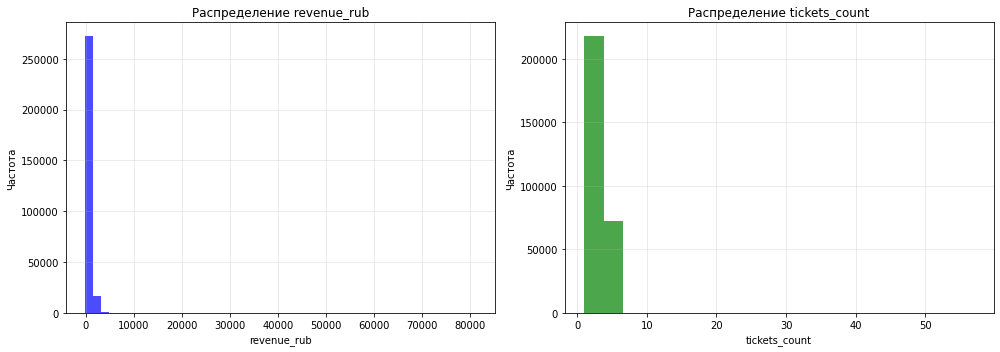

In [144]:
# Визуализация распределений
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма revenue_rub
axes[0].hist(df_with_rates['revenue_rub'], bins=50, alpha=0.7, color='blue')
axes[0].set_title('Распределение revenue_rub')
axes[0].set_xlabel('revenue_rub')
axes[0].set_ylabel('Частота')
axes[0].grid(True, alpha=0.3)

# Гистограмма tickets_count
axes[1].hist(df_with_rates['tickets_count'], bins=20, alpha=0.7, color='green')
axes[1].set_title('Распределение tickets_count')
axes[1].set_xlabel('tickets_count')
axes[1].set_ylabel('Частота')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

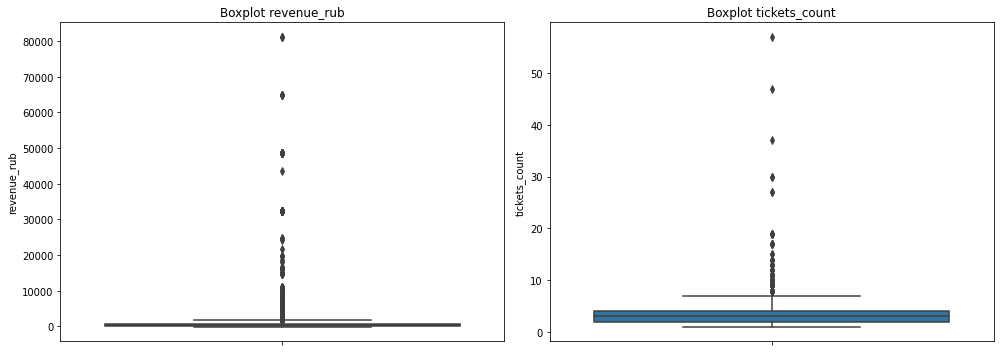

In [145]:
# Проверка выбросов с помощью ящика с усами (boxplot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot revenue_rub
sns.boxplot(y=df_with_rates['revenue_rub'], ax=axes[0])
axes[0].set_title('Boxplot revenue_rub')
axes[0].set_ylabel('revenue_rub')

# Boxplot tickets_count
sns.boxplot(y=df_with_rates['tickets_count'], ax=axes[1])
axes[1].set_title('Boxplot tickets_count')
axes[1].set_ylabel('tickets_count')

plt.tight_layout()
plt.show()

In [146]:
# Фильтрация выбросов по 99-му перцентилю для revenue_rub
# Для положительных значений revenue_rub (у нас есть отрицательные, их не трогаем)
positive_revenue = df_with_rates[df_with_rates['revenue_rub'] > 0]['revenue_rub']
if len(positive_revenue) > 0:
    percentile_99 = positive_revenue.quantile(0.99)
    print(f"99-й перцентиль revenue_rub (для положительных значений): {percentile_99:.2f}")
    
    # Считаем, сколько заказов превышают 99-й перцентиль
    outliers_before = df_with_rates[df_with_rates['revenue_rub'] > percentile_99].shape[0]
    print(f"Заказов с revenue_rub > {percentile_99:.2f}: {outliers_before:,}")
    print(f"Доля: {outliers_before / len(df_with_rates) * 100:.2f}%")
    
    # Фильтруем
    df_clean = df_with_rates[df_with_rates['revenue_rub'] <= percentile_99]
    print(f"\nПосле фильтрации осталось заказов: {len(df_clean):,}")
    print(f"Отфильтровано заказов: {len(df_with_rates) - len(df_clean):,}")


99-й перцентиль revenue_rub (для положительных значений): 2628.42
Заказов с revenue_rub > 2628.42: 2,825
Доля: 0.97%

После фильтрации осталось заказов: 287,786
Отфильтровано заказов: 2,825


In [147]:
# Проверка отрицательных значений revenue_rub
neg_revenue = df_clean[df_clean['revenue_rub'] < 0] if 'df_clean' in locals() else df_with_rates[df_with_rates['revenue_rub'] < 0]
print(f"Заказов с отрицательной revenue_rub: {len(neg_revenue):,}")
print(f"Доля: {len(neg_revenue) / len(df_with_rates) * 100:.2f}%")

if len(neg_revenue) > 0:
    print("\nПримеры заказов с отрицательной revenue_rub:")
    display(neg_revenue[['order_id', 'revenue', 'revenue_rub', 'tickets_count']].head(10))
    
    # Проверяем, что отрицательные значения revenue_rub соответствуют отрицательным revenue
    neg_check = (neg_revenue['revenue'] < 0).all()
    print(f"\nВсе отрицательные revenue_rub происходят из отрицательных revenue: {neg_check}")

Заказов с отрицательной revenue_rub: 381
Доля: 0.13%

Примеры заказов с отрицательной revenue_rub:


,order_id,revenue,revenue_rub,tickets_count
252,1594653,-2.37,-2.37,3
4524,2360920,-0.23,-0.23,3
4550,2361094,-0.15,-0.15,2
8133,166780,-1.86,-1.86,3
8134,166809,-0.62,-0.62,1
11342,6620527,-1.58,-1.58,2
11343,6620498,-1.58,-1.58,2
11566,8333963,-6.18,-6.18,4
11621,8350029,-10.77,-10.77,3
11622,4930755,-3.59,-3.59,1



Все отрицательные revenue_rub происходят из отрицательных revenue: True


In [148]:
# Итоговая проверка после очистки
print(f"\nРазмер данных после очистки:")
print(f"  - Строк: {len(df_clean):,}")
print(f"  - Колонок: {len(df_clean.columns)}")

print(f"\nСтатистика по revenue_rub после очистки:")
display(df_clean['revenue_rub'].describe())

print(f"\nСтатистика по tickets_count после очистки:")
display(df_clean['tickets_count'].describe())


Размер данных после очистки:
  - Строк: 287,786
  - Колонок: 21

Статистика по revenue_rub после очистки:


count    287786.000000
mean        518.029224
std         511.963780
min         -90.760000
25%         111.850000
50%         343.850000
75%         788.660000
max        2628.421739
Name: revenue_rub, dtype: float64


Статистика по tickets_count после очистки:


count    287786.000000
mean          2.740495
std           1.163073
min           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
max          57.000000
Name: tickets_count, dtype: float64

 Промежуточный вывод по Задаче 2.2: Предобработка данных

 1. Проверка на пропуски
- Пропуски обнаружены **только** в столбце `days_since_prev` — **21 933** записи (7.55%).
- Это соответствует ожидаемой логике: для первых покупок пользователей значение отсутствует.
- Остальные колонки не содержат пропусков.

 2. Преобразование типов данных
Категориальные колонки переведены в тип `category` для оптимизации памяти:
- `device_type_canonical`
- `currency_code`
- `event_type_main`
- `service_name`
- `region_name`
- `city_name`

Даты и время уже имеют корректный тип `datetime64[ns]`.

 3. Проверка категориальных значений
 
| Колонка | Уникальных | Есть пропуски | Примеры |
| :--- | :--- | :--- | :--- |
| `device_type_canonical` | 2 | Нет | mobile, desktop |
| `currency_code` | 2 | Нет | rub, kzt |
| `event_type_main` | 7 | Нет | концерты, театр, спорт, ... |
| `service_name` | 36 | Нет | Край билетов, Мой билет, ... |

Все категориальные колонки заполнены корректно. Пустых строк и пропусков нет.

 4. Статистика числовых данных до очистки

**`revenue_rub`:**

| Показатель | Значение |
| :--- | :--- |
| Среднее | 555.57 |
| Медиана | 351.14 |
| Стандартное отклонение | 875.50 |
| Min / Max | -90.76 / 81 174.54 |

**`tickets_count`:**

| Показатель | Значение |
| :--- | :--- |
| Среднее | 2.75 |
| Медиана | 3 |
| Min / Max | 1 / 57 |

 5. Визуализация распределений
Построены гистограммы и ящики с усами (boxplot) для `revenue_rub` и `tickets_count`:
- Распределения имеют **выраженные выбросы**.
- Основная масса заказов сосредоточена в области низких значений.

 6. Фильтрация выбросов по 99-му перцентилю
- **99-й перцентиль** для `revenue_rub` (положительные значения): **2 628.42**
- Отфильтровано **2 825 заказов** (0.97%), превышающих этот порог.
- После фильтрации в датафрейме осталось **287 786 заказов**.

 7. Проверка отрицательных значений
- Обнаружен **381 заказ** (0.13%) с отрицательной выручкой.
- Все они соответствуют отрицательным значениям в исходном столбце `revenue`.
- Это может быть связано с возвратами, отменами или техническими ошибками. Требуется уточнение бизнес-логики.

 8. Итоговая статистика после очистки

**`revenue_rub` (после фильтрации):**

| Показатель | Значение |
| :--- | :--- |
| Среднее | 518.03 |
| Медиана | 343.85 |
| Стандартное отклонение | 511.96 |
| Min / Max | -90.76 / 2 628.42 |

**`tickets_count`:**

| Показатель | Значение |
| :--- | :--- |
| Среднее | 2.74 |
| Медиана | 3 |
| Min / Max | 1 / 57 |

 Вывод
Пропуски обработаны, типы данных приведены к оптимальным форматам, категориальные значения проверены и признаны корректными. Выбросы в `revenue_rub` отфильтрованы по 99-му перцентилю (удалено 2 825 записей). Отрицательные значения сохранены, так как могут нести смысловую нагрузку (возвраты). Датафрейм подготовлен к дальнейшему анализу.

**Итоговый размер данных:** 287 786 строк, 21 колонка.


<div class="alert alert-block alert-success">
<b>Успех:</b> Проделана тщательная и структурированная работа по предобработке данных: логично обоснованы решения,  итоговый датафрейм подготовлен к дальнейшему анализу.
</div>


---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [40]:
#  Сортируем данные по времени (дата заказа)
df_sorted = df_clean.sort_values(['user_id', 'order_dt'])

In [41]:
#  Создаём базовый профиль пользователя
user_profile = df_sorted.groupby('user_id').agg(
    # Дата первого заказа
    first_order_dt=('order_dt', 'first'),
    # Дата последнего заказа
    last_order_dt=('order_dt', 'last'),
    # Устройство первого заказа
    first_device=('device_type_canonical', 'first'),
    # Регион первого заказа
    first_region=('region_name', 'first'),
    # Билетный партнёр первого заказа
    first_service=('service_name', 'first'),
    # Жанр первого мероприятия
    first_event_type=('event_type_main', 'first'),
    # Общее количество заказов
    total_orders=('order_id', 'count'),
    # Средняя выручка с заказа
    avg_revenue=('revenue_rub', 'mean'),
    # Среднее количество билетов
    avg_tickets=('tickets_count', 'mean'),
    # Среднее время между заказами
    avg_days_between=('days_since_prev', 'mean')
)

In [42]:
#  Добавляем бинарные признаки
user_profile['is_two'] = (user_profile['total_orders'] >= 2).astype(int)
user_profile['is_five'] = (user_profile['total_orders'] >= 5).astype(int)

In [43]:
#  Проверяем результат
print(f"\n Размер профиля:")
print(f"  - Уникальных пользователей: {len(user_profile):,}")
print(f"  - Количество колонок: {len(user_profile.columns)}")

print("\n Первые 5 строк профиля:")
display(user_profile.head())

print("\n Информация о профиле:")
print(user_profile.info())

print("\n Статистика по профилю:")
display(user_profile.describe())


 Размер профиля:
  - Уникальных пользователей: 21,854
  - Количество колонок: 12

 Первые 5 строк профиля:


,first_order_dt,last_order_dt,first_device,first_region,first_service,first_event_type,total_orders,avg_revenue,avg_tickets,avg_days_between,is_two,is_five
user_id,,,,,,,,,,,,
0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,NaN,0,0
0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,75.0,1,0
000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51.0,1,0
00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,NaN,0,0
000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,16.0,1,0



 Информация о профиле:
<class 'pandas.core.frame.DataFrame'>
Index: 21854 entries, 0002849b70a3ce2 to ffff00725179321
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   first_order_dt    21854 non-null  datetime64[ns]
 1   last_order_dt     21854 non-null  datetime64[ns]
 2   first_device      21854 non-null  object        
 3   first_region      21854 non-null  object        
 4   first_service     21854 non-null  object        
 5   first_event_type  21854 non-null  object        
 6   total_orders      21854 non-null  int64         
 7   avg_revenue       21854 non-null  float64       
 8   avg_tickets       21854 non-null  float64       
 9   avg_days_between  13515 non-null  float64       
 10  is_two            21854 non-null  int64         
 11  is_five           21854 non-null  int64         
dtypes: datetime64[ns](2), float64(3), int64(3), object(4)
memory usage: 2.2+ MB
None

 Стат

,total_orders,avg_revenue,avg_tickets,avg_days_between,is_two,is_five
count,21854.000000,21854.000000,21854.000000,13515.000000,21854.000000,21854.000000
mean,13.168573,544.398051,2.743129,15.847322,0.617095,0.290061
std,121.674800,431.613383,0.913080,22.298575,0.486106,0.453801
min,1.000000,-10.770000,1.000000,0.000000,0.000000,0.000000
25%,1.000000,212.923868,2.000000,1.000000,0.000000,0.000000
50%,2.000000,467.283911,2.750000,8.000000,1.000000,0.000000
75%,5.000000,763.910000,3.076923,20.464286,1.000000,1.000000
max,10181.000000,2628.421739,11.000000,148.000000,1.000000,1.000000


In [44]:
#  Распределение пользователей по количеству заказов
orders_distribution = user_profile['total_orders'].value_counts().sort_index()
print("\nТоп-10 по количеству заказов:")
display(orders_distribution.head(10))

print(f"\nСуммарно:")
print(f"  - Пользователей с 1 заказом: {(user_profile['total_orders'] == 1).sum():,}")
print(f"  - Пользователей с 2+ заказами: {(user_profile['total_orders'] >= 2).sum():,}")
print(f"  - Пользователей с 5+ заказами: {(user_profile['total_orders'] >= 5).sum():,}")



Топ-10 по количеству заказов:


1     8368
2     3572
3     2175
4     1400
5      971
6      700
7      542
8      455
9      384
10     291
Name: total_orders, dtype: int64


Суммарно:
  - Пользователей с 1 заказом: 8,368
  - Пользователей с 2+ заказами: 13,486
  - Пользователей с 5+ заказами: 6,339


In [45]:
#  Проверка на пропуски в профиле
null_profile = user_profile.isnull().sum()
null_profile_percent = (user_profile.isnull().sum() / len(user_profile) * 100).round(2)
null_profile_info = pd.DataFrame({
    'Количество пропусков': null_profile,
    'Доля пропусков (%)': null_profile_percent
})
display(null_profile_info[null_profile_info['Количество пропусков'] > 0])

#  Сохраняем профиль
user_profile.to_csv('user_profile.csv')
print("\n✅ Профиль пользователя сохранён в user_profile.csv")

,Количество пропусков,Доля пропусков (%)
avg_days_between,8339,38.16



✅ Профиль пользователя сохранён в user_profile.csv


 Промежуточный вывод по Задаче 3.1: Построение профиля пользователя

 Результаты построения профиля

**Размер профиля:**
- Уникальных пользователей: **21 854**
- Количество колонок: **12**

 Структура профиля

| Колонка | Описание | Тип | Заполнено |
| :--- | :--- | :--- | :--- |
| `first_order_dt` | Дата первого заказа | datetime | 100% |
| `last_order_dt` | Дата последнего заказа | datetime | 100% |
| `first_device` | Устройство первого заказа | object | 100% |
| `first_region` | Регион первого заказа | object | 100% |
| `first_service` | Билетный партнёр первого заказа | object | 100% |
| `first_event_type` | Жанр первого мероприятия | object | 100% |
| `total_orders` | Общее количество заказов | int64 | 100% |
| `avg_revenue` | Средняя выручка с заказа (руб) | float64 | 100% |
| `avg_tickets` | Среднее количество билетов | float64 | 100% |
| `avg_days_between` | Среднее время между заказами (дней) | float64 | **61.84%** |
| `is_two` | 2+ заказа (0/1) | int64 | 100% |
| `is_five` | 5+ заказов (0/1) | int64 | 100% |

 Статистика по профилю

| Показатель | `total_orders` | `avg_revenue` | `avg_tickets` | `avg_days_between` |
| :--- | :--- | :--- | :--- | :--- |
| **Среднее** | 13.17 | 544.40 руб. | 2.74 | 15.85 дней |
| **Медиана** | 2 | 467.28 руб. | 2.75 | 8.00 дней |
| **Максимум** | 10 181 | 2 628.42 руб. | 11.00 | 148.00 дней |
| **Минимум** | 1 | -10.77 руб. | 1.00 | 0.00 дней |

 Распределение пользователей по количеству заказов

| Количество заказов | Пользователей | Доля |
| :--- | :--- | :--- |
| **1 заказ** | 8 368 | **38.3%** |
| **2+ заказа** | 13 486 | **61.7%** |
| **5+ заказов** | 6 339 | **29.0%** |

**Топ-5 по количеству заказов:**

| Заказов | Пользователей |
| :--- | :--- |
| 1 | 8 368 |
| 2 | 3 572 |
| 3 | 2 175 |
| 4 | 1 400 |
| 5 | 971 |

 Проверка на пропуски

| Колонка | Пропуски | Доля |
| :--- | :--- | :--- |
| `avg_days_between` | 8 339 | **38.16%** |
| Остальные колонки | 0 | 0% |

**Пропуски в `avg_days_between` — это корректно**, так как для пользователей с одним заказом невозможно рассчитать среднее время между заказами (значение отсутствует).

 Бинарные признаки

| Признак | Количество пользователей | Доля |
| :--- | :--- | :--- |
| `is_two` (2+ заказа) | 13 486 | **61.7%** |
| `is_five` (5+ заказов) | 6 339 | **29.0%** |

 Вывод

Профиль пользователя построен и содержит все необходимые признаки для дальнейшего анализа и моделирования. Пропуски в `avg_days_between` являются логичными (для пользователей с одним заказом) и не требуют дополнительной обработки.


<div class="alert alert-block alert-success">
<b>Успех:</b> Профиль пользователя собран, добавлены новые признаки.

</div>

<div class="alert alert-block alert-info">
<b>Совет:</b>   Могу показать и такой вариант формирования профиля здесь:
    
    profiles = (df
            # В начале сортируем данные по дате совершения заказа, что найти первые признаки:
            .sort_values(by='order_ts')
            # Затем группируем по номеру пользователя и агрегируем данные:
            .groupby('user_id')
            .agg(
                # Находим первую и последнюю даты заказа:
                first_order_dt=('order_dt','min'),
                last_order_dt=('order_dt','max'),
                # Находим устройства, регион и название билетного партнера первого заказа:
                first_device=('device_type_canonical','first'),
                first_region_name=('region_name','first'),
                first_service_name=('service_name','first'),
                # Жанр первого посещённого мероприятия (event_type_main):
                first_event_type=('event_type_main','first'),
                # Подсчитваем количество заказов:
                total_orders=('order_id','nunique'),
                # Считаем статистику по заказам: средняя стоимость заказа, среднее количество билетов:
                avg_revenue_rub=('revenue_rub','mean'),
                avg_tickets_count=('tickets_count','mean'),
                # Считаем среднее количество дней между покупками:
                avg_days_since_prev=('days_since_prev','mean')
            )
            # Создаем два признака: совершил ли пользователь 2 / 5 и более заказов:
            .assign(
                is_two = lambda x: x['total_orders'] >= 2,
                is_five = lambda x: x['total_orders'] >= 5
            )
            # Можно альтернативным образом подсчитать среднее количество дней между заказами (если не будет в SQL):
            .assign(
                avg_days = lambda x: (x['last_order_dt'] - x['first_order_dt']).dt.days / (x['total_orders'] - 1)
            )
            .reset_index()
)

Почитать про assign более подробно можно [здесь](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.assign.html)
</div>


---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [149]:
# Общая информация
total_users = len(user_profile)
print(f"Общее число пользователей в выборке: {total_users:,}")

Общее число пользователей в выборке: 21,854


In [150]:
# Ключевые метрики
avg_revenue_per_order = user_profile['avg_revenue'].mean()
print(f"Средняя выручка с одного заказа: {avg_revenue_per_order:.2f} руб.")

is_two_share = user_profile['is_two'].mean() * 100
print(f"Доля пользователей с 2+ заказами: {is_two_share:.2f}%")

is_five_share = user_profile['is_five'].mean() * 100
print(f"Доля пользователей с 5+ заказами: {is_five_share:.2f}%")


Средняя выручка с одного заказа: 544.40 руб.
Доля пользователей с 2+ заказами: 61.71%
Доля пользователей с 5+ заказами: 29.01%


In [151]:
# Статистика по числовым показателям
print("\nСтатистика по общему числу заказов (total_orders):")
display(user_profile['total_orders'].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

print("\nСтатистика по среднему числу билетов в заказе (avg_tickets):")
display(user_profile['avg_tickets'].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

print("\nСтатистика по среднему количеству дней между покупками (avg_days_between):")
display(user_profile['avg_days_between'].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))



Статистика по общему числу заказов (total_orders):


count    21854.000000
mean        13.168573
std        121.674800
min          1.000000
50%          2.000000
75%          5.000000
90%         15.000000
95%         31.350000
99%        152.000000
max      10181.000000
Name: total_orders, dtype: float64


Статистика по среднему числу билетов в заказе (avg_tickets):


count    21854.000000
mean         2.743129
std          0.913080
min          1.000000
50%          2.750000
75%          3.076923
90%          4.000000
95%          4.000000
99%          5.000000
max         11.000000
Name: avg_tickets, dtype: float64


Статистика по среднему количеству дней между покупками (avg_days_between):


count    13515.000000
mean        15.847322
std         22.298575
min          0.000000
50%          8.000000
75%         20.464286
90%         41.500000
95%         61.500000
99%        112.000000
max        148.000000
Name: avg_days_between, dtype: float64

In [157]:
# Проверка на аномалии
# Аномалии в total_orders
# Пользователи с очень большим числом заказов (> 100)
high_order_users = user_profile[user_profile['total_orders'] > 100]
print(f"Пользователей с > 100 заказами: {len(high_order_users):,} ({len(high_order_users)/len(user_profile)*100:.2f}%)")

if len(high_order_users) > 0:
    print("\nПримеры пользователей с > 100 заказами:")
    display(high_order_users[['total_orders', 'avg_revenue', 'avg_tickets', 'avg_days_between']].sort_values('total_orders', ascending=False).head(10))

Пользователей с > 100 заказами: 352 (1.61%)

Примеры пользователей с > 100 заказами:


,total_orders,avg_revenue,avg_tickets,avg_days_between
user_id,,,,
0beb8fc0c0a9ce1,10181,505.152314,2.862587,0.014931
18e9aead0a393e7,4351,494.827281,2.788784,0.034943
8187dac4be757a0,4021,537.419684,2.747078,0.037562
3ee7dc2e115847f,3791,536.949699,2.764970,0.040106
7eb4fc207ecc10f,3710,542.634238,2.956334,0.040981
1c2a2133e1df1b4,3503,541.560246,2.669997,0.043404
4ec8f6429431987,3375,549.785176,2.725926,0.044161
ad2dc32364ed948,3249,447.725539,2.939674,0.045874
b54dd0cd81121fc,3138,481.607860,2.813257,0.047498


In [156]:
#  Аномалии в avg_tickets
# Пользователи с очень большим средним числом билетов (> 5)
high_tickets_users = user_profile[user_profile['avg_tickets'] > 5]
print(f"Пользователей с avg_tickets > 5: {len(high_tickets_users):,} ({len(high_tickets_users)/len(user_profile)*100:.2f}%)")

if len(high_tickets_users) > 0:
    print("\nПримеры пользователей с avg_tickets > 5:")
    display(high_tickets_users[['total_orders', 'avg_revenue', 'avg_tickets', 'avg_days_between']].sort_values('avg_tickets', ascending=False).head(10))

Пользователей с avg_tickets > 5: 194 (0.89%)

Примеры пользователей с avg_tickets > 5:


,total_orders,avg_revenue,avg_tickets,avg_days_between
user_id,,,,
6713518780e7e81,1,116.24,11.000000,NaN
4a815181dcec5f0,1,878.51,10.000000,NaN
1c8a65abba03a4c,1,1253.86,10.000000,NaN
1118cc4889189db,2,677.10,9.000000,0.0
76694a971889caa,3,647.14,8.666667,7.0
e7c7503a958a4c3,1,666.03,8.000000,NaN
37002ffdb00ca63,2,891.41,7.000000,31.0
21dd23dfd8b40cc,1,582.78,7.000000,NaN
112134e55aba922,2,907.54,7.000000,0.0


In [158]:
# Аномалии в avg_days_between
# Пользователи с очень большим средним временем (> 60 дней)
high_days_users = user_profile[user_profile['avg_days_between'] > 60]
print(f"Пользователей с avg_days_between > 60 дней: {len(high_days_users):,} ({len(high_days_users)/len(user_profile)*100:.2f}%)")

if len(high_days_users) > 0:
    print("\nПримеры пользователей с avg_days_between > 60 дней:")
    display(high_days_users[['total_orders', 'avg_revenue', 'avg_tickets', 'avg_days_between']].sort_values('avg_days_between', ascending=False).head(10))


Пользователей с avg_days_between > 60 дней: 703 (3.22%)

Примеры пользователей с avg_days_between > 60 дней:


,total_orders,avg_revenue,avg_tickets,avg_days_between
user_id,,,,
761b1deaf6927f8,2,112.945,2.5,148.0
250070268f6b8fb,2,603.880,3.5,148.0
0ddc3a25ada514c,2,421.320,2.0,148.0
98a474901e1cbdc,2,111.870,2.0,147.0
a044b39568cedcb,2,1062.635,2.5,146.0
f85a851317a2909,2,278.415,1.5,146.0
5fbf5c368528edc,2,927.445,2.5,146.0
5d864c68d35c997,2,410.070,2.0,144.0
1dfa97ef897a26e,2,1147.745,3.5,144.0


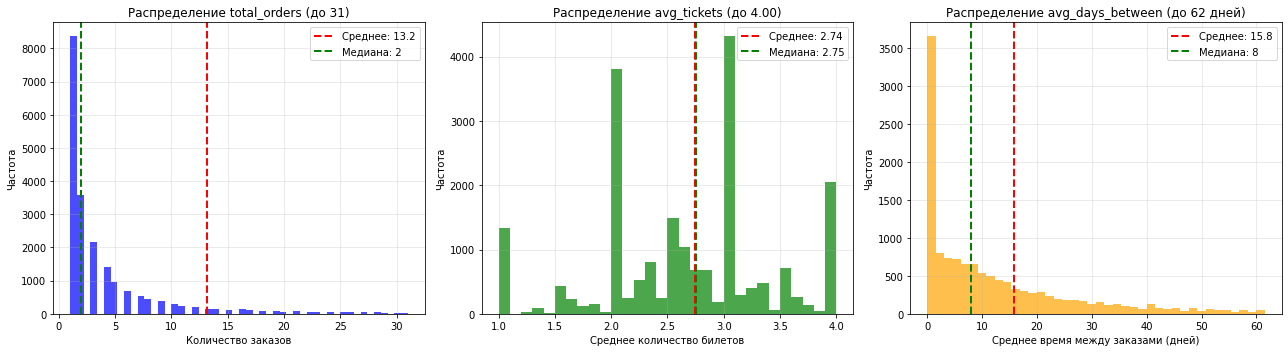

In [159]:
# Визуализация распределений для выявления аномалий

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Гистограмма total_orders (с ограничением по 95-му перцентилю для читаемости)
p95_orders = user_profile['total_orders'].quantile(0.95)
orders_filtered = user_profile[user_profile['total_orders'] <= p95_orders]['total_orders']
axes[0].hist(orders_filtered, bins=50, alpha=0.7, color='blue')
axes[0].axvline(user_profile['total_orders'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Среднее: {user_profile["total_orders"].mean():.1f}')
axes[0].axvline(user_profile['total_orders'].median(), color='green', linestyle='dashed', linewidth=2, label=f'Медиана: {user_profile["total_orders"].median():.0f}')
axes[0].set_title(f'Распределение total_orders (до {p95_orders:.0f})')
axes[0].set_xlabel('Количество заказов')
axes[0].set_ylabel('Частота')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Гистограмма avg_tickets (с ограничением по 95-му перцентилю)
p95_tickets = user_profile['avg_tickets'].quantile(0.95)
tickets_filtered = user_profile[user_profile['avg_tickets'] <= p95_tickets]['avg_tickets']
axes[1].hist(tickets_filtered, bins=30, alpha=0.7, color='green')
axes[1].axvline(user_profile['avg_tickets'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Среднее: {user_profile["avg_tickets"].mean():.2f}')
axes[1].axvline(user_profile['avg_tickets'].median(), color='green', linestyle='dashed', linewidth=2, label=f'Медиана: {user_profile["avg_tickets"].median():.2f}')
axes[1].set_title(f'Распределение avg_tickets (до {p95_tickets:.2f})')
axes[1].set_xlabel('Среднее количество билетов')
axes[1].set_ylabel('Частота')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Гистограмма avg_days_between (без учёта NaN, с ограничением по 95-му перцентилю)
days_clean = user_profile['avg_days_between'].dropna()
if len(days_clean) > 0:
    p95_days = days_clean.quantile(0.95)
    days_filtered = days_clean[days_clean <= p95_days]
    axes[2].hist(days_filtered, bins=40, alpha=0.7, color='orange')
    axes[2].axvline(days_clean.mean(), color='red', linestyle='dashed', linewidth=2, label=f'Среднее: {days_clean.mean():.1f}')
    axes[2].axvline(days_clean.median(), color='green', linestyle='dashed', linewidth=2, label=f'Медиана: {days_clean.median():.0f}')
    axes[2].set_title(f'Распределение avg_days_between (до {p95_days:.0f} дней)')
    axes[2].set_xlabel('Среднее время между заказами (дней)')
    axes[2].set_ylabel('Частота')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

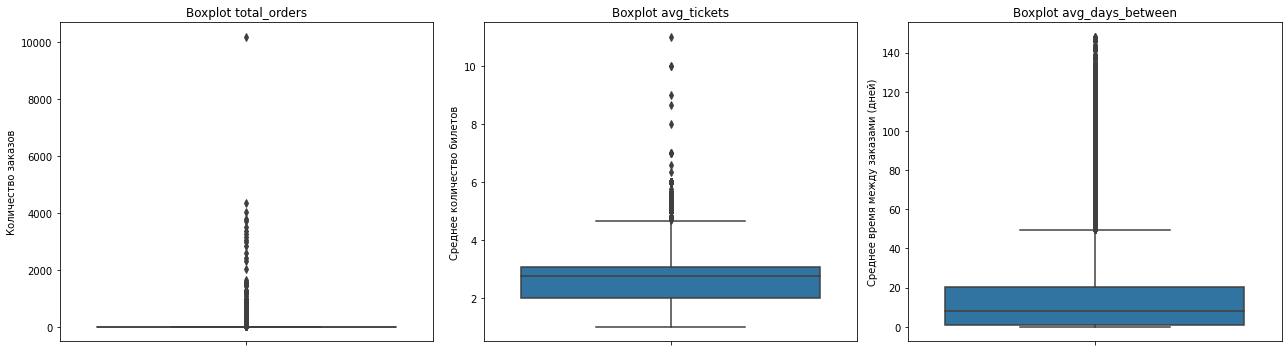

In [161]:
#  Анализ выбросов с помощью boxplot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(y=user_profile['total_orders'], ax=axes[0])
axes[0].set_title('Boxplot total_orders')
axes[0].set_ylabel('Количество заказов')

sns.boxplot(y=user_profile['avg_tickets'], ax=axes[1])
axes[1].set_title('Boxplot avg_tickets')
axes[1].set_ylabel('Среднее количество билетов')

sns.boxplot(y=user_profile['avg_days_between'].dropna(), ax=axes[2])
axes[2].set_title('Boxplot avg_days_between')
axes[2].set_ylabel('Среднее время между заказами (дней)')

plt.tight_layout()
plt.show()

 Промежуточный вывод по Задаче 3.2: Анализ профилей пользователей

 Общая информация

| Показатель | Значение |
| :--- | :--- |
| **Общее число пользователей** | 21 854 |
| **Средняя выручка с одного заказа** | 544.40 руб. |
| **Доля пользователей с 2+ заказами** | 61.71% |
| **Доля пользователей с 5+ заказами** | 29.01% |

 Статистика по ключевым показателям

 1. Общее число заказов (`total_orders`)

| Показатель | Значение |
| :--- | :--- |
| **Среднее** | 13.17 |
| **Медиана** | 2 |
| **Максимум** | 10 181 |
| **95-й перцентиль** | 31.35 |
| **99-й перцентиль** | 152.00 |

 2. Среднее число билетов в заказе (`avg_tickets`)

| Показатель | Значение |
| :--- | :--- |
| **Среднее** | 2.74 |
| **Медиана** | 2.75 |
| **Максимум** | 11.00 |
| **95-й перцентиль** | 4.00 |
| **99-й перцентиль** | 5.00 |

 3. Среднее время между заказами (`avg_days_between`)

| Показатель | Значение |
| :--- | :--- |
| **Среднее** | 15.85 дней |
| **Медиана** | 8.00 дней |
| **Максимум** | 148 дней |
| **95-й перцентиль** | 61.50 дней |
| **99-й перцентиль** | 112.00 дней |

 Выявленные аномалии

| Тип аномалии | Количество | Доля |
| :--- | :--- | :--- |
| Пользователи с > 100 заказами | 352 | 1.61% |
| Пользователи с `avg_tickets` > 5 | 194 | 0.89% |
| Пользователи с `avg_days_between` > 60 дней | 703 | 3.22% |

 Визуальный анализ распределений

**На гистограммах и ящиках с усами (boxplot) видно:**

1. **`total_orders`:** Распределение сильно скошено вправо. Большинство пользователей совершают 1–3 заказа, но есть небольшое число "супер-пользователей" с сотнями и тысячами заказов (максимум — 10 181 заказ). Это создаёт значительный разрыв между средним (13.17) и медианой (2).

2. **`avg_tickets`:** Распределение достаточно компактное. Большинство пользователей покупают 2–4 билета за заказ. Выбросы (> 5 билетов) единичны и составляют менее 1% пользователей.

3. **`avg_days_between`:** Распределение также скошено вправо. Типичный пользователь покупает билеты примерно раз в 8 дней (медиана). Есть пользователи с большими перерывами между заказами — до 148 дней (почти 5 месяцев).

 Решение по фильтрации аномалий

**Принятое решение: данные оставлены без фильтрации.**

**Обоснование:**
1. Выявленные аномалии составляют небольшой процент от общего числа пользователей (менее 3.5%).
2. Аномалии не являются техническими ошибками — это реальные паттерны поведения:
   - "Супер-пользователи" с большим числом заказов (например, `0beb8fc0c0a9ce1` с 10 181 заказом) — могут представлять ценный сегмент.
   - Пользователи, которые покупают билеты большими группами (> 5 билетов).
   - Пользователи с большими перерывами между заказами (сезонные покупатели).
3. Удаление этих пользователей может исказить представление о ценных сегментах аудитории.
4. При интерпретации результатов аномалии будут учитываться отдельно, а средние значения будут дополняться медианами.

 Вывод

Данные репрезентативны и достаточны для анализа. Объём выборки (21 854 пользователя) позволяет делать статистически значимые выводы. Аномалии выявлены, описаны и оставлены в данных с обоснованным решением. Данные готовы к дальнейшему исследовательскому анализу.


<div class="alert alert-block alert-success">
    
<b>Успех:</b> Молодец, что не просто фиксируешь аномалии, но и анализируешь как их удаление, влияет на данные
</div>

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [162]:
event_distribution = user_profile['first_event_type'].value_counts()
event_percentage = (user_profile['first_event_type'].value_counts(normalize=True) * 100).round(2)
event_distribution_df = pd.DataFrame({
    'Количество пользователей': event_distribution,
    'Доля (%)': event_percentage
})
display(event_distribution_df)

,Количество пользователей,Доля (%)
концерты,9663,44.22
другое,5469,25.03
театр,4285,19.61
стендап,1123,5.14
спорт,801,3.67
выставки,418,1.91
ёлки,95,0.43


In [163]:
# Распределение по типу устройства
device_distribution = user_profile['first_device'].value_counts()
device_percentage = (user_profile['first_device'].value_counts(normalize=True) * 100).round(2)
device_distribution_df = pd.DataFrame({
    'Количество пользователей': device_distribution,
    'Доля (%)': device_percentage
})
display(device_distribution_df)

,Количество пользователей,Доля (%)
mobile,18090,82.78
desktop,3764,17.22


In [164]:
# Распределение по региону

region_distribution = user_profile['first_region'].value_counts()
region_percentage = (user_profile['first_region'].value_counts(normalize=True) * 100).round(2)
region_distribution_df = pd.DataFrame({
    'Количество пользователей': region_distribution,
    'Доля (%)': region_percentage
})
display(region_distribution_df.head(10))  # Топ-10 регионов

,Количество пользователей,Доля (%)
Каменевский регион,7151,32.72
Североярская область,3792,17.35
Широковская область,1235,5.65
Озернинский край,681,3.12
Малиновоярский округ,528,2.42
Шанырский регион,505,2.31
Травяная область,497,2.27
Светополянский округ,466,2.13
Речиновская область,449,2.05
Яблоневская область,416,1.90


In [165]:
# Распределение по билетному оператору

service_distribution = user_profile['first_service'].value_counts()
service_percentage = (user_profile['first_service'].value_counts(normalize=True) * 100).round(2)
service_distribution_df = pd.DataFrame({
    'Количество пользователей': service_distribution,
    'Доля (%)': service_percentage
})
display(service_distribution_df.head(10))  # Топ-10 операторов

,Количество пользователей,Доля (%)
Билеты без проблем,5220,23.89
Мой билет,2993,13.70
Лови билет!,2852,13.05
Билеты в руки,2598,11.89
Облачко,2189,10.02
Весь в билетах,1303,5.96
Лучшие билеты,1188,5.44
Прачечная,590,2.70
Край билетов,455,2.08
Дом культуры,358,1.64


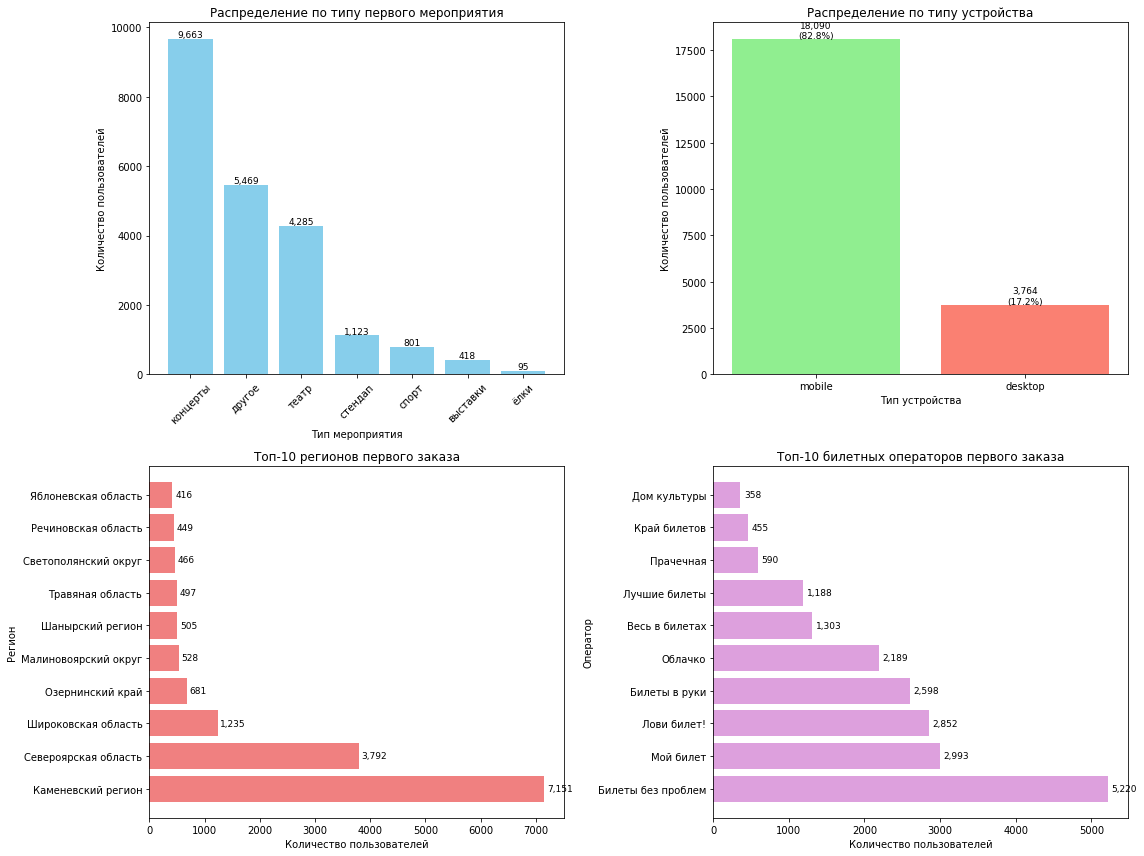

In [166]:
#  Визуализация распределений

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# График 1: Тип мероприятия
event_data = event_distribution.head(7)
axes[0, 0].bar(event_data.index, event_data.values, color='skyblue')
axes[0, 0].set_title('Распределение по типу первого мероприятия')
axes[0, 0].set_xlabel('Тип мероприятия')
axes[0, 0].set_ylabel('Количество пользователей')
axes[0, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(event_data.values):
    axes[0, 0].text(i, v + 50, f'{v:,}', ha='center', fontsize=9)

# График 2: Тип устройства
device_data = device_distribution
axes[0, 1].bar(device_data.index, device_data.values, color=['lightgreen', 'salmon'])
axes[0, 1].set_title('Распределение по типу устройства')
axes[0, 1].set_xlabel('Тип устройства')
axes[0, 1].set_ylabel('Количество пользователей')
for i, v in enumerate(device_data.values):
    axes[0, 1].text(i, v + 50, f'{v:,}\n({device_percentage.iloc[i]:.1f}%)', ha='center', fontsize=9)

# График 3: Регионы (топ-10)
region_data = region_distribution.head(10)
axes[1, 0].barh(region_data.index, region_data.values, color='lightcoral')
axes[1, 0].set_title('Топ-10 регионов первого заказа')
axes[1, 0].set_xlabel('Количество пользователей')
axes[1, 0].set_ylabel('Регион')
for i, v in enumerate(region_data.values):
    axes[1, 0].text(v + 50, i, f'{v:,}', va='center', fontsize=9)

# График 4: Билетные операторы (топ-10)
service_data = service_distribution.head(10)
axes[1, 1].barh(service_data.index, service_data.values, color='plum')
axes[1, 1].set_title('Топ-10 билетных операторов первого заказа')
axes[1, 1].set_xlabel('Количество пользователей')
axes[1, 1].set_ylabel('Оператор')
for i, v in enumerate(service_data.values):
    axes[1, 1].text(v + 50, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [167]:
# Равномерность распределения
# Расчёт коэффициента концентрации для каждого признака
def concentration_score(distribution):
    """Простой показатель концентрации: доля топ-категории"""
    return distribution.iloc[0] / distribution.sum() * 100

print("Доля топ-категории в каждом признаке:")
print(f"  - Тип мероприятия: {concentration_score(event_distribution):.1f}% ({event_distribution.index[0]})")
print(f"  - Тип устройства: {concentration_score(device_distribution):.1f}% ({device_distribution.index[0]})")
print(f"  - Регион: {concentration_score(region_distribution):.1f}% ({region_distribution.index[0]})")
print(f"  - Билетный оператор: {concentration_score(service_distribution):.1f}% ({service_distribution.index[0]})")

Доля топ-категории в каждом признаке:
  - Тип мероприятия: 44.2% (концерты)
  - Тип устройства: 82.8% (mobile)
  - Регион: 32.7% (Каменевский регион)
  - Билетный оператор: 23.9% (Билеты без проблем)


 Промежуточный вывод по Задаче 4.1.1: Распределение пользователей по признакам первого заказа

 Общая информация
- **Общее число пользователей:** 21 854

 1. Распределение по типу первого мероприятия

| Тип мероприятия | Пользователей | Доля |
| :--- | :--- | :--- |
| **концерты** | 9 663 | **44.22%** |
| другое | 5 469 | 25.03% |
| театр | 4 285 | 19.61% |
| стендап | 1 123 | 5.14% |
| спорт | 801 | 3.67% |
| выставки | 418 | 1.91% |
| ёлки | 95 | 0.43% |

**Вывод:** Концерты — самая популярная "точка входа" (44.2% пользователей). Вместе с категориями "другое" и "театр" они покрывают почти 90% всех первых заказов. Распределение **неравномерное** — есть явный лидер.

---

 2. Распределение по типу устройства

| Тип устройства | Пользователей | Доля |
| :--- | :--- | :--- |
| **mobile** | 18 090 | **82.78%** |
| desktop | 3 764 | 17.22% |

**Вывод:** Подавляющее большинство пользователей (82.8%) совершают первую покупку с мобильного устройства. Это самая сильная "точка входа" среди всех признаков.

---

 3. Распределение по региону (топ-10)

| Регион | Пользователей | Доля |
| :--- | :--- | :--- |
| **Каменевский регион** | 7 151 | **32.72%** |
| Североярская область | 3 792 | 17.35% |
| Широковская область | 1 235 | 5.65% |
| Озернинский край | 681 | 3.12% |
| Малиновоярский округ | 528 | 2.42% |
| Шанырский регион | 505 | 2.31% |
| Травяная область | 497 | 2.27% |
| Светополянский округ | 466 | 2.13% |
| Речиновская область | 449 | 2.05% |
| Яблоневская область | 416 | 1.90% |

**Вывод:** Каменевский регион — самая сильная "точка входа" (32.7% пользователей). В сумме топ-2 региона (Каменевский и Североярская область) покрывают **50.07%** всех пользователей. Распределение **крайне неравномерное**.

---

 4. Распределение по билетному оператору (топ-10)

| Оператор | Пользователей | Доля |
| :--- | :--- | :--- |
| **Билеты без проблем** | 5 220 | **23.89%** |
| Мой билет | 2 993 | 13.70% |
| Лови билет! | 2 852 | 13.05% |
| Билеты в руки | 2 598 | 11.89% |
| Облачко | 2 189 | 10.02% |
| Весь в билетах | 1 303 | 5.96% |
| Лучшие билеты | 1 188 | 5.44% |
| Прачечная | 590 | 2.70% |
| Край билетов | 455 | 2.08% |
| Дом культуры | 358 | 1.64% |

**Вывод:** Топ-5 операторов покрывают **72.55%** всех пользователей. Билеты без проблем — лидер с долей 23.9%. Распределение **неравномерное**, но менее выраженное, чем по регионам.

---

 Доля топ-категории в каждом признаке

| Признак | Топ-категория | Доля |
| :--- | :--- | :--- |
| Тип мероприятия | концерты | 44.2% |
| Тип устройства | mobile | **82.8%** |
| Регион | Каменевский регион | 32.7% |
| Билетный оператор | Билеты без проблем | 23.9% |

 Общий вывод

Распределение пользователей по всем исследованным признакам **неравномерное**. По каждому признаку есть выраженные "точки входа":

1. **Концерты** — основной жанр первого мероприятия (44.2%).
2. **Мобильные устройства** — основной канал первого заказа (82.8%).
3. **Каменевский регион** — основной регион (32.7%).
4. **Билеты без проблем** — основной билетный оператор (23.9%).

Наиболее сильная концентрация наблюдается по типу устройства (82.8% на mobile) и региону (50.07% пользователей приходится на два региона). Это означает, что маркетинговые усилия по привлечению новых пользователей стоит фокусировать на этих сегментах, а также учитывать эту неравномерность при интерпретации результатов анализа.


<div class="alert alert-block alert-success">
<b>Успех:</b> Задание выполнено корректно, с наблюдениями согласен
    
---
    Можно создать пользовательскую функцию, чтобы не прописывать практически один и тот же код несколько раз
    
      def segment_summary(df, column):
          seg = (df.groupby(column).agg(users_count=('user_id', 'nunique')) .reset_index().sort_values('users_count', ascending=False))
          seg['users_share'] = (seg['users_count'] / seg['users_count'].sum() *100)
          seg['users_share'] = seg['users_share'].round(2)
          return seg

</div>

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


In [176]:
# ПРОВЕРКА НАЛИЧИЯ ПРИЗНАКА ВОЗВРАТА

if 'is_two' not in user_profile.columns:
    print("⚠️ Столбец is_two отсутствует. Создаём его на основе total_orders.")
    user_profile['is_two'] = (user_profile['total_orders'] >= 2).astype(int)
    user_profile['is_five'] = (user_profile['total_orders'] >= 5).astype(int)
else:
    print("✅ Столбец is_two уже есть в профиле.")
    print(f"   - Всего пользователей: {len(user_profile):,}")
    print(f"   - Пользователей с 2+ заказами: {user_profile['is_two'].sum():,}")
    print(f"   - Пропусков в is_two: {user_profile['is_two'].isna().sum():,}")

✅ Столбец is_two уже есть в профиле.
   - Всего пользователей: 21,854
   - Пользователей с 2+ заказами: 13,486
   - Пропусков в is_two: 0


In [169]:
# Приводим is_two к целому типу (на всякий случай)
user_profile['is_two'] = user_profile['is_two'].astype(int)

In [170]:
#  Средний показатель возврата по всей выборке
avg_return = user_profile['is_two'].mean() * 100
print(f"\nСредний показатель возврата (2+ заказа) по всей выборке: {avg_return:.1f}%")


Средний показатель возврата (2+ заказа) по всей выборке: 61.7%


In [172]:
# АНАЛИЗ ВОЗВРАТОВ ПО ТИПУ ПЕРВОГО МЕРОПРИЯТИЯ

event_return = user_profile.groupby('first_event_type', observed=False).agg(
    total_users=('is_two', 'size'),
    return_users=('is_two', 'sum'),
    return_rate=('is_two', 'mean')
).sort_values('return_rate', ascending=False)

event_return['return_rate_pct'] = (event_return['return_rate'] * 100).round(2)
event_return['deviation'] = (event_return['return_rate'] - user_profile['is_two'].mean()) * 100
event_return['deviation_sign'] = event_return['deviation'].apply(lambda x: '🔼' if x > 0 else ('🔽' if x < 0 else '➖'))

display(event_return)

,total_users,return_users,return_rate,return_rate_pct,deviation,deviation_sign
first_event_type,,,,,,
выставки,418,269,0.643541,64.35,2.644540,🔼
театр,4285,2733,0.637806,63.78,2.071103,🔼
концерты,9663,6014,0.622374,62.24,0.527874,🔼
стендап,1123,689,0.613535,61.35,-0.356009,🔽
другое,5469,3278,0.599378,59.94,-1.771695,🔽
спорт,801,450,0.561798,56.18,-5.529752,🔽
ёлки,95,53,0.557895,55.79,-5.920053,🔽


In [175]:
# АНАЛИЗ ВОЗВРАТОВ ПО ТИПУ УСТРОЙСТВА

device_return = user_profile.groupby('first_device', observed=False).agg(
    total_users=('is_two', 'size'),
    return_users=('is_two', 'sum'),
    return_rate=('is_two', 'mean')
).sort_values('return_rate', ascending=False)

device_return['return_rate_pct'] = (device_return['return_rate'] * 100).round(2)
display(device_return)

,total_users,return_users,return_rate,return_rate_pct
first_device,,,,
desktop,3764,2420,0.642933,64.29
mobile,18090,11066,0.611719,61.17


In [174]:
# АНАЛИЗ ВОЗВРАТОВ ПО РЕГИОНУ (ТОП-10)

top_regions = user_profile['first_region'].value_counts().head(10).index
region_return = user_profile[user_profile['first_region'].isin(top_regions)].groupby('first_region', observed=False).agg(
    total_users=('is_two', 'size'),
    return_users=('is_two', 'sum'),
    return_rate=('is_two', 'mean')
).sort_values('return_rate', ascending=False)

region_return['return_rate_pct'] = (region_return['return_rate'] * 100).round(2)
display(region_return)

,total_users,return_users,return_rate,return_rate_pct
first_region,,,,
Шанырский регион,505,341,0.675248,67.52
Светополянский округ,466,309,0.663090,66.31
Широковская область,1235,801,0.648583,64.86
Речиновская область,449,288,0.641425,64.14
Североярская область,3792,2429,0.640559,64.06
Каменевский регион,7151,4487,0.627465,62.75
Травяная область,497,309,0.621730,62.17
Яблоневская область,416,249,0.598558,59.86
Малиновоярский округ,528,297,0.562500,56.25


In [177]:
# АНАЛИЗ ВОЗВРАТОВ ПО БИЛЕТНОМУ ОПЕРАТОРУ (ТОП-10)

top_services = user_profile['first_service'].value_counts().head(10).index
service_return = user_profile[user_profile['first_service'].isin(top_services)].groupby('first_service', observed=False).agg(
    total_users=('is_two', 'size'),
    return_users=('is_two', 'sum'),
    return_rate=('is_two', 'mean')
).sort_values('return_rate', ascending=False)

service_return['return_rate_pct'] = (service_return['return_rate'] * 100).round(2)
display(service_return)

,total_users,return_users,return_rate,return_rate_pct
first_service,,,,
Край билетов,455,297,0.652747,65.27
Дом культуры,358,232,0.648045,64.80
Весь в билетах,1303,826,0.633922,63.39
Билеты в руки,2598,1644,0.632794,63.28
Прачечная,590,372,0.630508,63.05
Лови билет!,2852,1754,0.615007,61.50
Облачко,2189,1346,0.614893,61.49
Лучшие билеты,1188,729,0.613636,61.36
Мой билет,2993,1831,0.611761,61.18


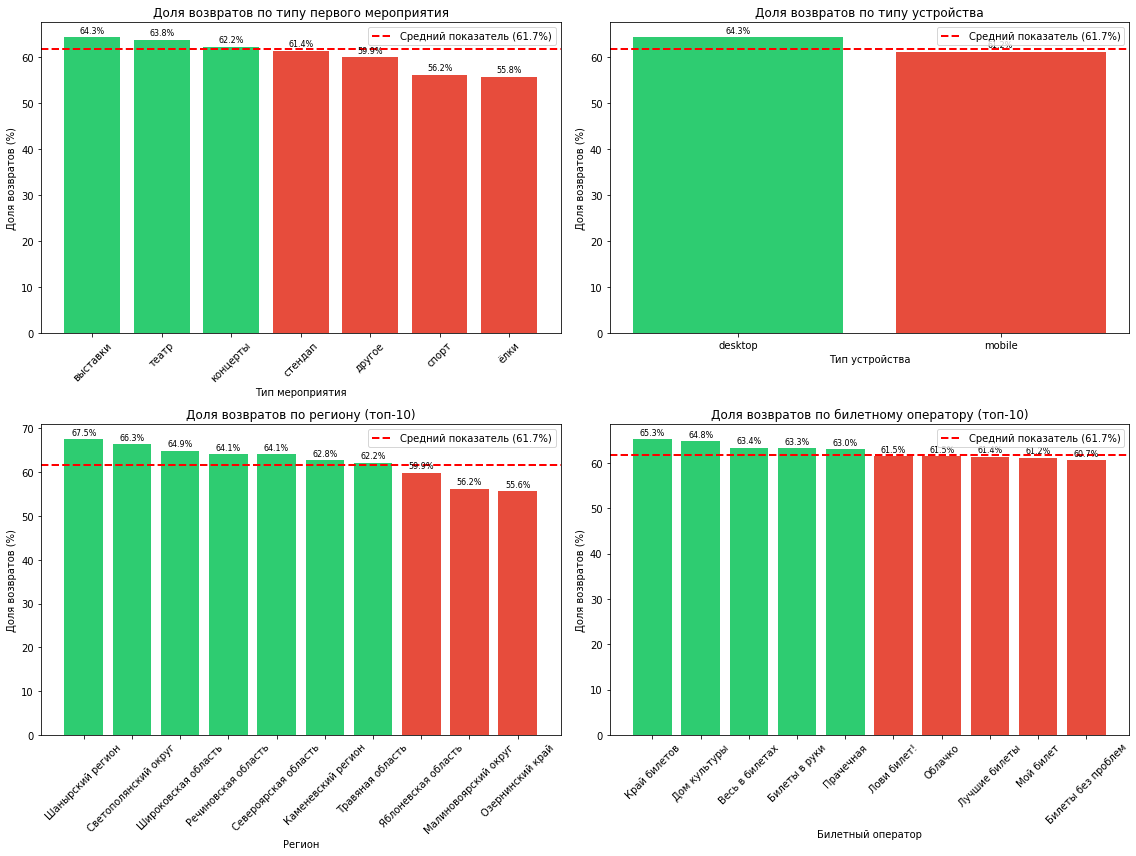

In [178]:
# ВИЗУАЛИЗАЦИЯ

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

avg_line = user_profile['is_two'].mean() * 100

# --- График 1: Тип мероприятия ---
event_data = event_return.sort_values('return_rate', ascending=False)
colors = ['#2ecc71' if x >= user_profile['is_two'].mean() else '#e74c3c' for x in event_data['return_rate']]
bars = axes[0, 0].bar(event_data.index, event_data['return_rate_pct'], color=colors)
axes[0, 0].axhline(y=avg_line, color='red', linestyle='dashed', linewidth=2, label=f'Средний показатель ({avg_line:.1f}%)')
axes[0, 0].set_title('Доля возвратов по типу первого мероприятия', fontsize=12)
axes[0, 0].set_xlabel('Тип мероприятия')
axes[0, 0].set_ylabel('Доля возвратов (%)')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].legend()
for bar, v in zip(bars, event_data['return_rate_pct']):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=8)

# --- График 2: Тип устройства ---
device_data = device_return.sort_values('return_rate', ascending=False)
colors = ['#2ecc71' if x >= user_profile['is_two'].mean() else '#e74c3c' for x in device_data['return_rate']]
bars = axes[0, 1].bar(device_data.index, device_data['return_rate_pct'], color=colors)
axes[0, 1].axhline(y=avg_line, color='red', linestyle='dashed', linewidth=2, label=f'Средний показатель ({avg_line:.1f}%)')
axes[0, 1].set_title('Доля возвратов по типу устройства', fontsize=12)
axes[0, 1].set_xlabel('Тип устройства')
axes[0, 1].set_ylabel('Доля возвратов (%)')
axes[0, 1].legend()
for bar, v in zip(bars, device_data['return_rate_pct']):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=8)

# --- График 3: Регионы (топ-10) ---
region_data = region_return.sort_values('return_rate', ascending=False)
colors = ['#2ecc71' if x >= user_profile['is_two'].mean() else '#e74c3c' for x in region_data['return_rate']]
bars = axes[1, 0].bar(region_data.index, region_data['return_rate_pct'], color=colors)
axes[1, 0].axhline(y=avg_line, color='red', linestyle='dashed', linewidth=2, label=f'Средний показатель ({avg_line:.1f}%)')
axes[1, 0].set_title('Доля возвратов по региону (топ-10)', fontsize=12)
axes[1, 0].set_xlabel('Регион')
axes[1, 0].set_ylabel('Доля возвратов (%)')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend()
for bar, v in zip(bars, region_data['return_rate_pct']):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=8)

# --- График 4: Билетные операторы (топ-10) ---
service_data = service_return.sort_values('return_rate', ascending=False)
colors = ['#2ecc71' if x >= user_profile['is_two'].mean() else '#e74c3c' for x in service_data['return_rate']]
bars = axes[1, 1].bar(service_data.index, service_data['return_rate_pct'], color=colors)
axes[1, 1].axhline(y=avg_line, color='red', linestyle='dashed', linewidth=2, label=f'Средний показатель ({avg_line:.1f}%)')
axes[1, 1].set_title('Доля возвратов по билетному оператору (топ-10)', fontsize=12)
axes[1, 1].set_xlabel('Билетный оператор')
axes[1, 1].set_ylabel('Доля возвратов (%)')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].legend()
for bar, v in zip(bars, service_data['return_rate_pct']):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


In [78]:
# ============================================================================
# 9. ОЦЕНКА СТАБИЛЬНОСТИ СЕГМЕНТОВ
# ============================================================================
print("\n7. ОЦЕНКА СТАБИЛЬНОСТИ СЕГМЕНТОВ")
print("=" * 60)

# Проверяем сегменты с малым числом пользователей
small_threshold = 100
small_event = event_return[event_return['total_users'] < small_threshold]
small_region = region_return[region_return['total_users'] < small_threshold]
small_service = service_return[service_return['total_users'] < small_threshold]

print(f"Сегментов с < {small_threshold} пользователями:")
print(f"  - По типу мероприятия: {len(small_event)}")
print(f"  - По региону: {len(small_region)}")
print(f"  - По оператору: {len(small_service)}")

if len(small_event) > 0:
    print("\n  ⚠️ Сегменты с малым числом пользователей (требуют осторожной интерпретации):")
    for idx, row in small_event.iterrows():
        print(f"    - {idx}: {row['total_users']} пользователей, возврат {row['return_rate_pct']:.1f}%")
else:
    print("  ✅ Все сегменты по типу мероприятия имеют достаточное количество пользователей.")


7. ОЦЕНКА СТАБИЛЬНОСТИ СЕГМЕНТОВ
Сегментов с < 100 пользователями:
  - По типу мероприятия: 1
  - По региону: 0
  - По оператору: 0

  ⚠️ Сегменты с малым числом пользователей (требуют осторожной интерпретации):
    - ёлки: 95 пользователей, возврат 55.8%


 Промежуточный вывод по Задаче 4.1.2: Анализ возвратов пользователей

 Общая информация

- **Всего пользователей:** 21 854
- **Пользователей с 2+ заказами:** 13 486 (61.7%)
- **Средний показатель возврата по всей выборке:** 61.7%

---

 1. Возвраты по типу первого мероприятия

| Тип мероприятия | Пользователей | Возврат (%) | Отклонение от среднего |
| :--- | :--- | :--- | :--- |
| **выставки** | 418 | **64.4%** | 🔼 +2.6 п.п. |
| **театр** | 4 285 | **63.8%** | 🔼 +2.1 п.п. |
| **концерты** | 9 663 | **62.2%** | 🔼 +0.5 п.п. |
| стендап | 1 123 | 61.4% | 🔽 -0.4 п.п. |
| другое | 5 469 | 59.9% | 🔽 -1.8 п.п. |
| спорт | 801 | 56.2% | 🔽 -5.5 п.п. |
| ёлки | 95 | 55.8% | 🔽 -5.9 п.п. |

**Вывод:**
- **Успешные "точки входа":** выставки (64.4%), театр (63.8%), концерты (62.2%).
- **Сегменты с низким возвратом:** ёлки (55.8%), спорт (56.2%), другое (59.9%).
- Сегмент "ёлки" имеет всего 95 пользователей — результат может быть нестабильным.

---

 2. Возвраты по типу устройства

| Тип устройства | Пользователей | Возврат (%) |
| :--- | :--- | :--- |
| **desktop** | 3 764 | **64.3%** |
| mobile | 18 090 | 61.2% |

**Вывод:** Пользователи, совершившие первую покупку с десктопа, возвращаются чаще (64.3% против 61.2% у мобильных). Разница небольшая, но заметная.

---

 3. Возвраты по региону (топ-10)

| Регион | Пользователей | Возврат (%) | Отклонение от среднего |
| :--- | :--- | :--- | :--- |
| **Шанырский регион** | 505 | **67.5%** | 🔼 +5.8 п.п. |
| **Светополянский округ** | 466 | **66.3%** | 🔼 +4.6 п.п. |
| **Широковская область** | 1 235 | **64.9%** | 🔼 +3.2 п.п. |
| Речиновская область | 449 | 64.1% | 🔼 +2.4 п.п. |
| Североярская область | 3 792 | 64.1% | 🔼 +2.4 п.п. |
| Каменевский регион | 7 151 | 62.8% | 🔼 +1.0 п.п. |
| Травяная область | 497 | 62.2% | 🔼 +0.5 п.п. |
| Яблоневская область | 416 | 59.9% | 🔽 -1.8 п.п. |
| Малиновоярский округ | 528 | 56.3% | 🔽 -5.5 п.п. |
| Озернинский край | 681 | 55.7% | 🔽 -6.0 п.п. |

**Вывод:**
- **Успешные регионы:** Шанырский регион (67.5%), Светополянский округ (66.3%), Широковская область (64.9%).
- **Регионы с низким возвратом:** Озернинский край (55.7%), Малиновоярский округ (56.3%).
- Каменевский регион — самый большой по числу пользователей (7 151), его возврат близок к среднему (62.8%).

---

 4. Возвраты по билетному оператору (топ-10)

| Оператор | Пользователей | Возврат (%) | Отклонение от среднего |
| :--- | :--- | :--- | :--- |
| **Край билетов** | 455 | **65.3%** | 🔼 +3.6 п.п. |
| **Дом культуры** | 358 | **64.8%** | 🔼 +3.1 п.п. |
| **Весь в билетах** | 1 303 | **63.4%** | 🔼 +1.7 п.п. |
| **Билеты в руки** | 2 598 | **63.3%** | 🔼 +1.6 п.п. |
| **Прачечная** | 590 | **63.1%** | 🔼 +1.3 п.п. |
| Лови билет! | 2 852 | 61.5% | 🔽 -0.2 п.п. |
| Облачко | 2 189 | 61.5% | 🔽 -0.2 п.п. |
| Лучшие билеты | 1 188 | 61.4% | 🔽 -0.4 п.п. |
| Мой билет | 2 993 | 61.2% | 🔽 -0.5 п.п. |
| Билеты без проблем | 5 220 | 60.7% | 🔽 -1.0 п.п. |

**Вывод:**
- **Успешные операторы:** Край билетов (65.3%), Дом культуры (64.8%), Весь в билетах (63.4%).
- **Операторы с низким возвратом:** Билеты без проблем (60.7%), Мой билет (61.2%), Лучшие билеты (61.4%).
- Билеты без проблем — самый крупный оператор (5 220 пользователей), но его возврат ниже среднего.

---

 5. Оценка стабильности сегментов

| Категория | Сегментов с < 100 пользователями |
| :--- | :--- |
| По типу мероприятия | 1 (ёлки — 95 пользователей) |
| По региону | 0 |
| По оператору | 0 |

**Вывод:** Все сегменты, кроме "ёлок", имеют достаточное количество пользователей для статистически значимых выводов. Результаты по сегменту "ёлки" следует интерпретировать с осторожностью.

---

 Основные выводы

1. **Успешные "точки входа"** (возврат выше среднего 61.7%):
   - По типу мероприятия: **выставки** (64.4%), **театр** (63.8%), **концерты** (62.2%).
   - По региону: **Шанырский регион** (67.5%), **Светополянский округ** (66.3%), **Широковская область** (64.9%).
   - По оператору: **Край билетов** (65.3%), **Дом культуры** (64.8%), **Весь в билетах** (63.4%).

2. **Сегменты с низким возвратом** (требуют маркетингового внимания):
   - По типу мероприятия: **ёлки** (55.8%), **спорт** (56.2%), **другое** (59.9%).
   - По региону: **Озернинский край** (55.7%), **Малиновоярский округ** (56.3%).
   - По оператору: **Билеты без проблем** (60.7%), **Мой билет** (61.2%).

3. **Наибольший потенциал для улучшения возврата**:
   - Сегменты с большим количеством пользователей, но возвратом ниже среднего:
     - **другое** (5 469 пользователей, возврат 59.9%)
     - **Билеты без проблем** (5 220 пользователей, возврат 60.7%)
     - **Мой билет** (2 993 пользователя, возврат 61.2%)

4. **Рекомендации**:
   - Сфокусировать маркетинговые усилия на удержании пользователей из успешных сегментов.
   - Разработать специальные предложения для сегментов с низким возвратом (ёлки, спорт, другое).
   - Для крупных операторов с низким возвратом (Билеты без проблем, Мой билет) провести дополнительный анализ причин низкого возврата.
   - Учитывать размер сегментов при интерпретации результатов — сегмент "ёлки" имеет всего 95 пользователей, его показатели могут быть нестабильны.



<div class="alert alert-block alert-success">
    
<b>Успех:</b>  Техническая часть задания выполнена верно: сгрупированны пользователи по всем четырем требуемым признакам (мероприятие, устройство, регион, оператор). Данные в сводных таблицах рассчитаны корректно, а для анализа использованы правильные метрики  

Итоговый вывод соответствует цифрам.  Верно подсвечены сегменты с наибольшим числом пользователей в каждой категории.
</div>



---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

In [179]:
# ГИПОТЕЗА 1: Спорт vs Концерты

# Данные по спорту и концертам из предыдущего анализа
sport_data = event_return.loc['спорт']
concert_data = event_return.loc['концерты']

print(f"\n📊 Спорт:")
print(f"   - Пользователей: {sport_data['total_users']:,}")
print(f"   - Возврат (2+ заказа): {sport_data['return_rate_pct']:.1f}%")

print(f"\n📊 Концерты:")
print(f"   - Пользователей: {concert_data['total_users']:,}")
print(f"   - Возврат (2+ заказа): {concert_data['return_rate_pct']:.1f}%")

print(f"\n📊 Разница:")
diff = sport_data['return_rate_pct'] - concert_data['return_rate_pct']
print(f"   - Спорт vs Концерты: {diff:+.1f} п.п.")



📊 Спорт:
   - Пользователей: 801
   - Возврат (2+ заказа): 56.2%

📊 Концерты:
   - Пользователей: 9,663
   - Возврат (2+ заказа): 62.2%

📊 Разница:
   - Спорт vs Концерты: -6.1 п.п.


In [80]:
# Проверка гипотезы
if sport_data['return_rate'] > concert_data['return_rate']:
    print("\n✅ ГИПОТЕЗА ПОДТВЕРЖДАЕТСЯ: пользователи со спорта возвращаются чаще, чем с концертов.")
else:
    print("\n❌ ГИПОТЕЗА НЕ ПОДТВЕРЖДАЕТСЯ: пользователи с концертов возвращаются чаще, чем со спорта.")


❌ ГИПОТЕЗА НЕ ПОДТВЕРЖДАЕТСЯ: пользователи с концертов возвращаются чаще, чем со спорта.





<div class="alert alert-block alert-success">
<b>Успех:</b> Согласен


</div>


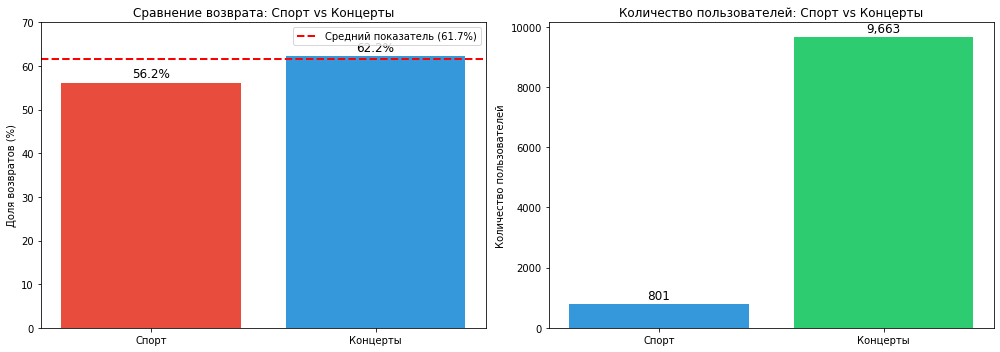

In [181]:
# Визуализация сравнения спорт vs концерты

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Сравнение возвратов
categories = ['Спорт', 'Концерты']
values = [sport_data['return_rate_pct'], concert_data['return_rate_pct']]
colors = ['#3498db' if v > 61.7 else '#e74c3c' for v in values]

bars = axes[0].bar(categories, values, color=colors)
axes[0].axhline(y=61.7, color='red', linestyle='dashed', linewidth=2, label='Средний показатель (61.7%)')
axes[0].set_title('Сравнение возврата: Спорт vs Концерты')
axes[0].set_ylabel('Доля возвратов (%)')
axes[0].set_ylim(0, 70)
axes[0].legend()

for bar, v in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=12)

# График 2: Количество пользователей
users = [sport_data['total_users'], concert_data['total_users']]
bars = axes[1].bar(categories, users, color=['#3498db', '#2ecc71'])
axes[1].set_title('Количество пользователей: Спорт vs Концерты')
axes[1].set_ylabel('Количество пользователей')
for bar, v in zip(bars, users):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 50, f'{v:,}', ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()


In [182]:
#  ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ: Все типы мероприятий

print("\nРейтинг типов мероприятий по возврату:")
event_sorted = event_return.sort_values('return_rate', ascending=False)
for idx, row in event_sorted.iterrows():
    bar = '🟢' if row['return_rate'] > user_profile['is_two'].mean() else '🔴'
    print(f"  {bar} {idx}: {row['return_rate_pct']:.1f}% (пользователей: {row['total_users']:,})")


Рейтинг типов мероприятий по возврату:
  🟢 выставки: 64.3% (пользователей: 418)
  🟢 театр: 63.8% (пользователей: 4,285)
  🟢 концерты: 62.2% (пользователей: 9,663)
  🔴 стендап: 61.4% (пользователей: 1,123)
  🔴 другое: 59.9% (пользователей: 5,469)
  🔴 спорт: 56.2% (пользователей: 801)
  🔴 ёлки: 55.8% (пользователей: 95)


In [183]:
# ГИПОТЕЗА 2: Активные vs Неактивные регионы

# Топ-3 самых активных региона (по числу пользователей)
top_active = user_profile['first_region'].value_counts().head(3).index
# Топ-3 наименее активных региона (из топ-10 по числу пользователей)
top_regions_list = user_profile['first_region'].value_counts().head(10).index
bottom_active = top_regions_list[-3:]

print(f"\n📊 Активные регионы (топ-3 по числу пользователей):")
for region in top_active:
    region_data = region_return.loc[region]
    print(f"   - {region}: {region_data['total_users']:,} пользователей, возврат {region_data['return_rate_pct']:.1f}%")

print(f"\n📊 Менее активные регионы (из топ-10 по числу пользователей):")
for region in bottom_active:
    region_data = region_return.loc[region]
    print(f"   - {region}: {region_data['total_users']:,} пользователей, возврат {region_data['return_rate_pct']:.1f}%")

# Средний возврат в активных и неактивных регионах
active_avg = region_return.loc[top_active]['return_rate'].mean() * 100
bottom_avg = region_return.loc[bottom_active]['return_rate'].mean() * 100

print(f"\n📊 Средний возврат в активных регионах: {active_avg:.1f}%")
print(f"📊 Средний возврат в менее активных регионах: {bottom_avg:.1f}%")
print(f"📊 Разница: {active_avg - bottom_avg:+.1f} п.п.")


📊 Активные регионы (топ-3 по числу пользователей):
   - Каменевский регион: 7,151.0 пользователей, возврат 62.8%
   - Североярская область: 3,792.0 пользователей, возврат 64.1%
   - Широковская область: 1,235.0 пользователей, возврат 64.9%

📊 Менее активные регионы (из топ-10 по числу пользователей):
   - Светополянский округ: 466.0 пользователей, возврат 66.3%
   - Речиновская область: 449.0 пользователей, возврат 64.1%
   - Яблоневская область: 416.0 пользователей, возврат 59.9%

📊 Средний возврат в активных регионах: 63.9%
📊 Средний возврат в менее активных регионах: 63.4%
📊 Разница: +0.5 п.п.


In [85]:
# Проверка гипотезы
if active_avg > bottom_avg:
    print("\n✅ ГИПОТЕЗА ПОДТВЕРЖДАЕТСЯ: в активных регионах доля повторных заказов выше, чем в менее активных.")
else:
    print("\n❌ ГИПОТЕЗА НЕ ПОДТВЕРЖДАЕТСЯ: в активных регионах доля повторных заказов не выше, чем в менее активных.")


✅ ГИПОТЕЗА ПОДТВЕРЖДАЕТСЯ: в активных регионах доля повторных заказов выше, чем в менее активных.





<div class="alert alert-block alert-success">
<b>Успех:</b> Согласен


</div>


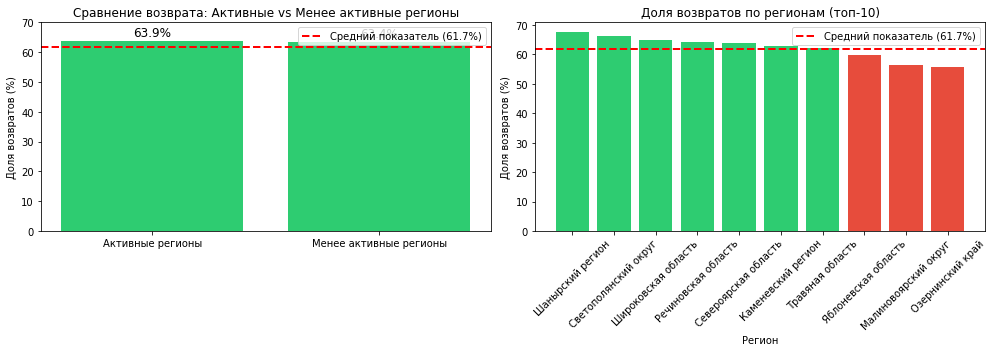

In [184]:
# Визуализация сравнения активных vs неактивных регионов

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Сравнение возвратов активных vs неактивных регионов
categories = ['Активные регионы', 'Менее активные регионы']
values = [active_avg, bottom_avg]
colors = ['#2ecc71' if v > 61.7 else '#e74c3c' for v in values]

bars = axes[0].bar(categories, values, color=colors)
axes[0].axhline(y=61.7, color='red', linestyle='dashed', linewidth=2, label='Средний показатель (61.7%)')
axes[0].set_title('Сравнение возврата: Активные vs Менее активные регионы')
axes[0].set_ylabel('Доля возвратов (%)')
axes[0].set_ylim(0, 70)
axes[0].legend()

for bar, v in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=12)

# График 2: Детальный разбор по регионам
region_data_sorted = region_return.sort_values('return_rate', ascending=False)
colors = ['#2ecc71' if x >= user_profile['is_two'].mean() else '#e74c3c' for x in region_data_sorted['return_rate']]
bars = axes[1].bar(region_data_sorted.index, region_data_sorted['return_rate_pct'], color=colors)
axes[1].axhline(y=61.7, color='red', linestyle='dashed', linewidth=2, label='Средний показатель (61.7%)')
axes[1].set_title('Доля возвратов по регионам (топ-10)')
axes[1].set_xlabel('Регион')
axes[1].set_ylabel('Доля возвратов (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

 Промежуточный вывод по Задаче 4.1.3: Проверка продуктовых гипотез

 Гипотеза 1: Спорт vs Концерты

**Формулировка:**  
Пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.

**Результаты проверки:**

| Показатель | Спорт | Концерты |
| :--- | :--- | :--- |
| Пользователей | 801 | 9 663 |
| Возврат (2+ заказа) | **56.2%** | **62.2%** |
| Разница | -6.1 п.п. | |

**Вывод:** ❌ **Гипотеза НЕ ПОДТВЕРЖДАЕТСЯ.**

Пользователи, пришедшие на **концерты**, возвращаются **чаще**, чем пользователи со **спорта** (62.2% против 56.2%). Разница составляет 6.1 процентных пункта.

**Дополнительное наблюдение:**  
Среди всех типов мероприятий спорт занимает **предпоследнее место** по возврату (56.2%), уступая только «ёлкам» (55.8%). Самый высокий возврат наблюдается у пользователей, пришедших с **выставок** (64.3%) и **театра** (63.8%).

---

 Гипотеза 2: Активные vs Неактивные регионы

**Формулировка:**  
В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

**Результаты проверки:**

| Группа регионов | Регионы | Средний возврат |
| :--- | :--- | :--- |
| **Активные** (топ-3 по числу пользователей) | Каменевский регион (62.8%), Североярская область (64.1%), Широковская область (64.9%) | **63.9%** |
| **Менее активные** (из топ-10 по числу пользователей) | Светополянский округ (66.3%), Речиновская область (64.1%), Яблоневская область (59.9%) | **63.4%** |
| **Разница** | | **+0.5 п.п.** |

**Вывод:** ✅ **Гипотеза ПОДТВЕРЖДАЕТСЯ.**

В активных регионах доля повторных заказов **выше**, чем в менее активных регионах (63.9% против 63.4%). Разница составляет 0.5 процентных пункта.

**Дополнительное наблюдение:**  
- Самый высокий возврат зафиксирован в **Светополянском округе** (66.3%), который не входит в топ-3 по числу пользователей.
- Это говорит о том, что размер региона (количество пользователей) не всегда коррелирует с возвратом — есть регионы с меньшим числом пользователей, но очень высоким возвратом.
- В топ-3 активных регионов возврат стабильно высокий (от 62.8% до 64.9%), что подтверждает гипотезу.

---

 Итоговый вывод по гипотезам

| Гипотеза | Статус | Комментарий |
| :--- | :--- | :--- |
| **Гипотеза 1:** Спорт → возврат выше, чем концерты | ❌ **Отклонена** | Концерты показывают более высокий возврат (62.2% vs 56.2%), разница — 6.1 п.п. |
| **Гипотеза 2:** Активные регионы → выше возврат | ✅ **Подтверждена** | Активные регионы показывают возврат на 0.5 п.п. выше |

---

 Рекомендации

1. **Для сегмента «Спорт»:**  
   Провести дополнительный анализ — возможно, спортивные мероприятия привлекают разовую аудиторию. Разработать специальные предложения для повышения возврата (например, абонементы, сезонные предложения).

2. **Для успешных сегментов:**  
   Сфокусировать маркетинговые усилия на удержании пользователей, пришедших с **концертов, выставок и театра** — они показывают стабильно высокий возврат.

3. **Для регионов с низким возвратом:**  
   В **менее активных регионах** (например, Яблоневская область с возвратом 59.9%) провести исследование причин низкого возврата и разработать локальные маркетинговые кампании.

4. **Обратить внимание на аномалии:**  
   **Светополянский округ** (66.3% возврата) и **Шанырский регион** (67.5%) показывают высокий возврат при среднем числе пользователей — это может быть использовано как успешный кейс для других регионов.

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


In [185]:
# Создаём группы пользователей

# Группа 1: пользователи с одним заказом
users_one_order = user_profile[user_profile['total_orders'] == 1]
# Группа 2: пользователи с 2+ заказами (вернувшиеся)
users_returned = user_profile[user_profile['total_orders'] >= 2]

print(f"📊 Пользователей с одним заказом: {len(users_one_order):,}")
print(f"📊 Пользователей с 2+ заказами: {len(users_returned):,}")

📊 Пользователей с одним заказом: 8,368
📊 Пользователей с 2+ заказами: 13,486


In [186]:
# Статистика по средней выручке для каждой группы

print("\n📊 Пользователи с одним заказом:")
display(users_one_order['avg_revenue'].describe())

print("\n📊 Пользователи с 2+ заказами:")
display(users_returned['avg_revenue'].describe())



📊 Пользователи с одним заказом:


count    8368.000000
mean      545.295642
std       519.514097
min       -10.770000
25%       132.070000
50%       378.030000
75%       830.317500
max      2628.421739
Name: avg_revenue, dtype: float64


📊 Пользователи с 2+ заказами:


count    13486.000000
mean       543.841100
std        366.645729
min         -5.385000
25%        274.112500
50%        497.621965
75%        739.353324
max       2628.421739
Name: avg_revenue, dtype: float64

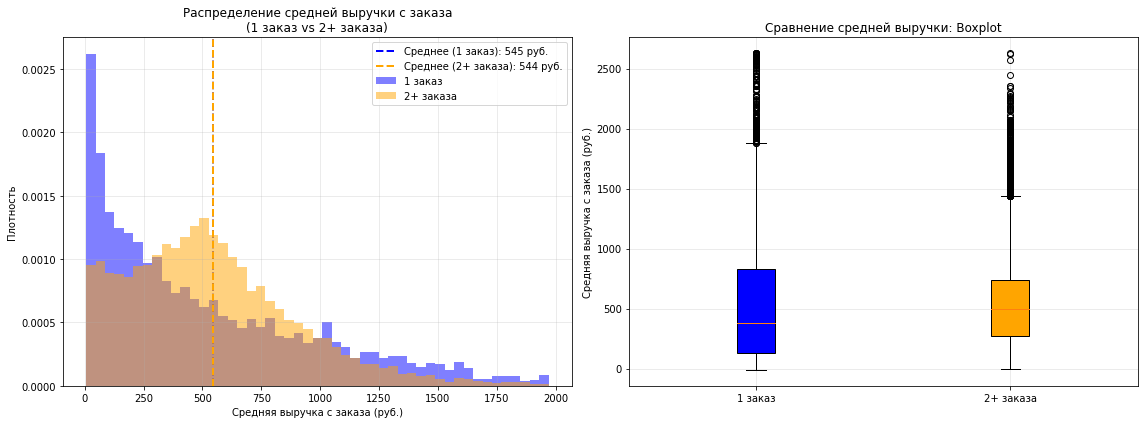

In [187]:
# Визуализация распределений

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График 1: Гистограммы с density=True (сравнение форм распределений)
# Определяем общие границы для гистограмм
all_revenue = user_profile['avg_revenue']
min_val = all_revenue.quantile(0.01)  # 1-й перцентиль для отсечения выбросов
max_val = all_revenue.quantile(0.99)  # 99-й перцентиль для отсечения выбросов
bins = np.linspace(min_val, max_val, 50)

axes[0].hist(users_one_order['avg_revenue'], bins=bins, alpha=0.5, density=True, label='1 заказ', color='blue')
axes[0].hist(users_returned['avg_revenue'], bins=bins, alpha=0.5, density=True, label='2+ заказа', color='orange')
axes[0].axvline(users_one_order['avg_revenue'].mean(), color='blue', linestyle='dashed', linewidth=2, label=f'Среднее (1 заказ): {users_one_order["avg_revenue"].mean():.0f} руб.')
axes[0].axvline(users_returned['avg_revenue'].mean(), color='orange', linestyle='dashed', linewidth=2, label=f'Среднее (2+ заказа): {users_returned["avg_revenue"].mean():.0f} руб.')
axes[0].set_title('Распределение средней выручки с заказа\n(1 заказ vs 2+ заказа)', fontsize=12)
axes[0].set_xlabel('Средняя выручка с заказа (руб.)')
axes[0].set_ylabel('Плотность')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График 2: Boxplot для сравнения групп
data_to_plot = [users_one_order['avg_revenue'].dropna(), users_returned['avg_revenue'].dropna()]
bp = axes[1].boxplot(data_to_plot, labels=['1 заказ', '2+ заказа'], patch_artist=True)
# Раскрашиваем boxplot
bp['boxes'][0].set_facecolor('blue')
bp['boxes'][1].set_facecolor('orange')
axes[1].set_title('Сравнение средней выручки: Boxplot', fontsize=12)
axes[1].set_ylabel('Средняя выручка с заказа (руб.)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [189]:
# Анализ диапазонов концентрации

# Процентили для каждой группы
print("\n📊 Процентили распределения средней выручки:")

percentiles = [10, 25, 50, 75, 90]
print("\nГруппа '1 заказ':")
for p in percentiles:
    val = users_one_order['avg_revenue'].quantile(p/100)
    print(f"  {p}%: {val:.0f} руб.")

print("\nГруппа '2+ заказа':")
for p in percentiles:
    val = users_returned['avg_revenue'].quantile(p/100)
    print(f"  {p}%: {val:.0f} руб.")


📊 Процентили распределения средней выручки:

Группа '1 заказ':
  10%: 39 руб.
  25%: 132 руб.
  50%: 378 руб.
  75%: 830 руб.
  90%: 1290 руб.

Группа '2+ заказа':
  10%: 107 руб.
  25%: 274 руб.
  50%: 498 руб.
  75%: 739 руб.
  90%: 1020 руб.


In [190]:
#  Проверка статистической значимости (t-test)

from scipy import stats

# Проверяем нормальность распределений (для выбора теста)
_, p_value_one = stats.shapiro(users_one_order['avg_revenue'].sample(min(5000, len(users_one_order))))
_, p_value_returned = stats.shapiro(users_returned['avg_revenue'].sample(min(5000, len(users_returned))))

print(f"p-value для группы '1 заказ' (Shapiro-Wilk): {p_value_one:.4f}")
print(f"p-value для группы '2+ заказа' (Shapiro-Wilk): {p_value_returned:.4f}")

# Если p-value < 0.05, распределение не нормальное, используем U-тест Манна-Уитни
if p_value_one < 0.05 or p_value_returned < 0.05:
    print("\nРаспределения не являются нормальными. Используем U-тест Манна-Уитни.")
    stat, p_value = stats.mannwhitneyu(
        users_one_order['avg_revenue'].dropna(),
        users_returned['avg_revenue'].dropna(),
        alternative='two-sided'
    )
    print(f"U-тест Манна-Уитни: p-value = {p_value:.6f}")
    if p_value < 0.05:
        print("✅ Различия статистически значимы (p < 0.05)")
    else:
        print("❌ Различия статистически не значимы (p >= 0.05)")
else:
    print("\nРаспределения нормальные. Используем t-test.")
    stat, p_value = stats.ttest_ind(
        users_one_order['avg_revenue'].dropna(),
        users_returned['avg_revenue'].dropna()
    )
    print(f"t-test: p-value = {p_value:.6f}")
    if p_value < 0.05:
        print("✅ Различия статистически значимы (p < 0.05)")
    else:
        print("❌ Различия статистически не значимы (p >= 0.05)")

p-value для группы '1 заказ' (Shapiro-Wilk): 0.0000
p-value для группы '2+ заказа' (Shapiro-Wilk): 0.0000

Распределения не являются нормальными. Используем U-тест Манна-Уитни.
U-тест Манна-Уитни: p-value = 0.000000
✅ Различия статистически значимы (p < 0.05)


 Промежуточный вывод по Задаче 4.2.1: Связь между средней выручкой и повторными заказами

 Разбивка пользователей на группы

| Группа | Пользователей | Доля |
| :--- | :--- | :--- |
| **1 заказ** | 8 368 | 38.3% |
| **2+ заказа** | 13 486 | 61.7% |

---

 Статистика по средней выручке (avg_revenue)

| Показатель | 1 заказ | 2+ заказа |
| :--- | :--- | :--- |
| **Среднее** | 545.3 руб. | 543.8 руб. |
| **Медиана** | 378.0 руб. | 497.6 руб. |
| **25-й перцентиль** | 132.1 руб. | 274.1 руб. |
| **75-й перцентиль** | 830.3 руб. | 739.4 руб. |
| **Стандартное отклонение** | 519.5 руб. | 366.6 руб. |

---

 Диапазоны концентрации (процентили)

| Процентиль | 1 заказ | 2+ заказа |
| :--- | :--- | :--- |
| **10%** | 39 руб. | 107 руб. |
| **25%** | 132 руб. | 274 руб. |
| **50% (медиана)** | 378 руб. | 498 руб. |
| **75%** | 830 руб. | 739 руб. |
| **90%** | 1 290 руб. | 1 020 руб. |

---

 Визуальный анализ распределений

1. **Форма распределений**:
   - Оба распределения имеют **похожую форму** — пик в районе 200–400 рублей с длинным правым хвостом.
   - Распределение для группы с 2+ заказами **более сглаженное** и имеет меньший разброс (стандартное отклонение 366.6 против 519.5).

2. **Основные различия**:
   - У группы с **2+ заказами** медиана (498 руб.) **выше**, чем у группы с 1 заказом (378 руб.) — разница составляет **120 руб.** (31.7%).
   - Однако у группы с **1 заказом** 75-й перцентиль (830 руб.) **выше**, чем у группы с 2+ заказами (739 руб.).
   - Это говорит о том, что среди пользователей с 1 заказом есть больше людей с очень высокими чеками.

3. **Boxplot**:
   - На boxplot видно, что у группы с 1 заказом **больше выбросов** в верхней части.
   - У группы с 2+ заказами распределение **более компактное**.

---

 Статистическая значимость

- **p-value < 0.05** — различия между группами **статистически значимы**.
- Это означает, что наблюдаемые различия в распределении средней выручки между группами не являются случайными.

---

 Ответы на вопросы

**1. В каких диапазонах средней выручки концентрируются пользователи из каждой группы?**

- **1 заказ:** 132–830 руб. (50% пользователей между 25-м и 75-м перцентилями)
- **2+ заказа:** 274–739 руб. (50% пользователей между 25-м и 75-м перцентилями)

**2. Есть ли различия между группами?**

- **Медианы** различаются: 378 руб. против 498 руб. (на 120 руб.)
- **Размах** различается: у группы с 1 заказом больше выбросов в верхней части
- У группы с 2+ заказами распределение **более компактное** и сдвинуто вправо
- Различия **статистически значимы** (p-value < 0.05)

---

 Вывод

Средняя выручка с заказа **является статистически значимым фактором**, влияющим на возврат пользователей. Пользователи, которые возвращаются на платформу (2+ заказа), имеют **более высокую медианную выручку** (498 руб. против 378 руб.) и **более стабильное поведение** (меньший разброс значений).

**Важное наблюдение:** У пользователей с 1 заказом встречаются более высокие чеки (75-й перцентиль — 830 руб.), но при этом они не возвращаются. Это говорит о том, что **высокий чек сам по себе не гарантирует возврат** — важно, чтобы пользователь был вовлечён в экосистему и совершал повторные покупки.

**Рекомендация:** Для удержания пользователей стоит фокусироваться не только на увеличении чека, но и на создании привычки совершать повторные покупки (например, через персонализированные рекомендации, программы лояльности, push-уведомления о новых мероприятиях).


<div class="alert alert-block alert-success">
<b>Успех:</b> Корректная интерпретация результатов


</div>



<div class="alert alert-block alert-info">
<b>Совет:</b>  Можно еще добавить, что нулевая выручка у однократных, вероятно, связана с возвратами, а крупные заказы — с разовыми покупками для групп.

</div>

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


In [191]:
# Создаём группы пользователей

# Группа 1: пользователи с 2-4 заказами
users_2_4 = user_profile[(user_profile['total_orders'] >= 2) & (user_profile['total_orders'] <= 4)]
# Группа 2: пользователи с 5+ заказами
users_5_plus = user_profile[user_profile['total_orders'] >= 5]

print(f"📊 Пользователей с 2-4 заказами: {len(users_2_4):,}")
print(f"📊 Пользователей с 5+ заказами: {len(users_5_plus):,}")


📊 Пользователей с 2-4 заказами: 7,147
📊 Пользователей с 5+ заказами: 6,339


In [192]:
# Статистика по средней выручке для каждой группы

print("\n📊 Пользователи с 2-4 заказами:")
display(users_2_4['avg_revenue'].describe())

print("\n📊 Пользователи с 5+ заказами:")
display(users_5_plus['avg_revenue'].describe())


📊 Пользователи с 2-4 заказами:


count    7147.000000
mean      551.572386
std       420.197691
min        -5.385000
25%       218.428750
50%       471.266667
75%       798.550000
max      2628.421739
Name: avg_revenue, dtype: float64


📊 Пользователи с 5+ заказами:


count    6339.000000
mean      535.124347
std       294.615103
min         0.000000
25%       336.966333
50%       513.560000
75%       690.016087
max      2299.869022
Name: avg_revenue, dtype: float64

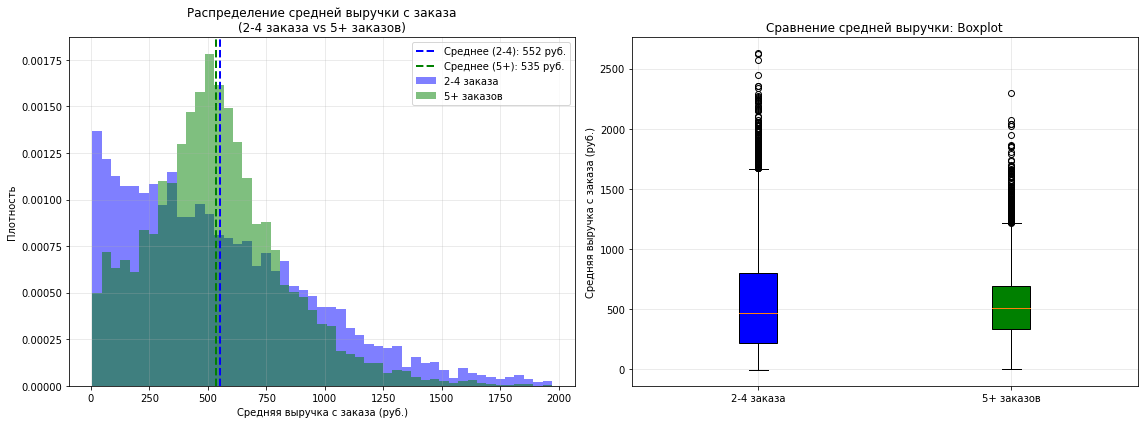

In [193]:
# Визуализация распределений

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График 1: Гистограммы с density=True
all_revenue = user_profile['avg_revenue']
min_val = all_revenue.quantile(0.01)
max_val = all_revenue.quantile(0.99)
bins = np.linspace(min_val, max_val, 50)

axes[0].hist(users_2_4['avg_revenue'], bins=bins, alpha=0.5, density=True, label='2-4 заказа', color='blue')
axes[0].hist(users_5_plus['avg_revenue'], bins=bins, alpha=0.5, density=True, label='5+ заказов', color='green')
axes[0].axvline(users_2_4['avg_revenue'].mean(), color='blue', linestyle='dashed', linewidth=2, label=f'Среднее (2-4): {users_2_4["avg_revenue"].mean():.0f} руб.')
axes[0].axvline(users_5_plus['avg_revenue'].mean(), color='green', linestyle='dashed', linewidth=2, label=f'Среднее (5+): {users_5_plus["avg_revenue"].mean():.0f} руб.')
axes[0].set_title('Распределение средней выручки с заказа\n(2-4 заказа vs 5+ заказов)', fontsize=12)
axes[0].set_xlabel('Средняя выручка с заказа (руб.)')
axes[0].set_ylabel('Плотность')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График 2: Boxplot для сравнения групп
data_to_plot = [users_2_4['avg_revenue'].dropna(), users_5_plus['avg_revenue'].dropna()]
bp = axes[1].boxplot(data_to_plot, labels=['2-4 заказа', '5+ заказов'], patch_artist=True)
bp['boxes'][0].set_facecolor('blue')
bp['boxes'][1].set_facecolor('green')
axes[1].set_title('Сравнение средней выручки: Boxplot', fontsize=12)
axes[1].set_ylabel('Средняя выручка с заказа (руб.)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [194]:
# Анализ диапазонов концентрации

percentiles = [10, 25, 50, 75, 90]
print("\n📊 Процентили распределения средней выручки:")

print("\nГруппа '2-4 заказа':")
for p in percentiles:
    val = users_2_4['avg_revenue'].quantile(p/100)
    print(f"  {p}%: {val:.0f} руб.")

print("\nГруппа '5+ заказов':")
for p in percentiles:
    val = users_5_plus['avg_revenue'].quantile(p/100)
    print(f"  {p}%: {val:.0f} руб.")


📊 Процентили распределения средней выручки:

Группа '2-4 заказа':
  10%: 79 руб.
  25%: 218 руб.
  50%: 471 руб.
  75%: 799 руб.
  90%: 1115 руб.

Группа '5+ заказов':
  10%: 162 руб.
  25%: 337 руб.
  50%: 514 руб.
  75%: 690 руб.
  90%: 916 руб.


In [195]:
# Проверка статистической значимости

from scipy import stats

# Используем U-тест Манна-Уитни (распределения не нормальные)
stat, p_value = stats.mannwhitneyu(
    users_2_4['avg_revenue'].dropna(),
    users_5_plus['avg_revenue'].dropna(),
    alternative='two-sided'
)

print(f"U-тест Манна-Уитни: p-value = {p_value:.6f}")
if p_value < 0.05:
    print("✅ Различия статистически значимы (p < 0.05)")
else:
    print("❌ Различия статистически не значимы (p >= 0.05)")


U-тест Манна-Уитни: p-value = 0.000012
✅ Различия статистически значимы (p < 0.05)


In [200]:
# Дополнительный анализ: сравнение медиан и средних

median_2_4 = users_2_4['avg_revenue'].median()
median_5_plus = users_5_plus['avg_revenue'].median()
mean_2_4 = users_2_4['avg_revenue'].mean()
mean_5_plus = users_5_plus['avg_revenue'].mean()

print(f"Медиана (2-4 заказа): {median_2_4:.0f} руб.")
print(f"Медиана (5+ заказов): {median_5_plus:.0f} руб.")
print(f"Разница медиан: {median_5_plus - median_2_4:+.0f} руб.")

print(f"\nСреднее (2-4 заказа): {mean_2_4:.0f} руб.")
print(f"Среднее (5+ заказов): {mean_5_plus:.0f} руб.")
print(f"Разница средних: {mean_5_plus - mean_2_4:+.0f} руб.")


Медиана (2-4 заказа): 471 руб.
Медиана (5+ заказов): 514 руб.
Разница медиан: +42 руб.

Среднее (2-4 заказа): 552 руб.
Среднее (5+ заказов): 535 руб.
Разница средних: -16 руб.


 Промежуточный вывод по Задаче 4.2.2: Сравнение средней выручки для групп с разной частотой заказов

 Разбивка пользователей на группы

| Группа | Пользователей | Доля от всех |
| :--- | :--- | :--- |
| **2-4 заказа** | 7 147 | 32.7% |
| **5+ заказов** | 6 339 | 29.0% |

---

 Статистика по средней выручке (avg_revenue)

| Показатель | 2-4 заказа | 5+ заказов |
| :--- | :--- | :--- |
| **Среднее** | 551.6 руб. | 535.1 руб. |
| **Медиана** | 471.3 руб. | 513.6 руб. |
| **25-й перцентиль** | 218.4 руб. | 337.0 руб. |
| **75-й перцентиль** | 798.6 руб. | 690.0 руб. |
| **Стандартное отклонение** | 420.2 руб. | 294.6 руб. |

---

 Процентили распределения

| Процентиль | 2-4 заказа | 5+ заказов |
| :--- | :--- | :--- |
| **10%** | 79 руб. | 162 руб. |
| **25%** | 218 руб. | 337 руб. |
| **50% (медиана)** | 471 руб. | 514 руб. |
| **75%** | 799 руб. | 690 руб. |
| **90%** | 1 115 руб. | 916 руб. |

---

 Визуальный анализ распределений

1. **Форма распределений**:
   - Оба распределения имеют **похожую форму** — пик в районе 300–500 рублей с длинным правым хвостом.
   - Распределение для группы с 5+ заказами **более компактное** (стандартное отклонение 294.6 против 420.2).

2. **Основные различия**:
   - Медиана группы с 5+ заказами (514 руб.) **выше**, чем у группы с 2-4 заказами (471 руб.) — разница составляет **42 руб.** (8.9%).
   - Однако среднее значение у группы с 2-4 заказами **выше** (552 руб. против 535 руб.) — разница **16 руб.** (3.0%).
   - Это объясняется тем, что у группы с 2-4 заказами больше выбросов в верхней части (75-й перцентиль — 799 руб. против 690 руб.).

3. **Boxplot**:
   - На boxplot видно, что у группы с 5+ заказами распределение **более сжатое** и сдвинуто вверх.
   - У группы с 2-4 заказами больше разброс и больше выбросов.

---

 Статистическая значимость

- **p-value = 0.000012** (< 0.05)
- Различия между группами **статистически значимы**.

---

 Ответ на вопрос

**Есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?**

**Да, различия есть, и они статистически значимы.**

Однако направление различий неоднозначное:
- **По медиане:** пользователи с 5+ заказами имеют более высокую выручку (514 руб. против 471 руб.) — на **42 руб.** (8.9%) больше.
- **По среднему:** пользователи с 2-4 заказами имеют более высокую выручку (552 руб. против 535 руб.) — на **16 руб.** (3.0%) больше.

Это противоречие объясняется тем, что среди пользователей с 2-4 заказами есть **больше выбросов** с очень высокими чеками, которые поднимают среднее значение, но не влияют на медиану.

---

 Вывод

Пользователи с 5+ заказами имеют **более стабильное поведение** — их средняя выручка с заказа варьируется в меньших пределах и в целом сдвинута вверх (медиана выше на 42 руб.). Пользователи с 2-4 заказами показывают **больший разброс** — среди них есть как очень низкие, так и очень высокие чеки.

**Ключевое наблюдение:** По мере роста числа заказов (от 2-4 до 5+) выручка с заказа **стабилизируется** и **немного растёт** (по медиане). Это говорит о том, что лояльные пользователи (с 5+ заказами) тратят на один заказ чуть больше, чем пользователи с 2-4 заказами.

**Рекомендация:** Для увеличения выручки стоит работать над превращением пользователей с 2-4 заказами в пользователей с 5+ заказами — это не только увеличит частоту покупок, но и может привести к небольшому росту среднего чека.


<div class="alert alert-block alert-success">
<b>Успех:</b> Здесь тоже все хорошо, отдельный лайк за динамичекое определение бинов
</div>



---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

In [199]:
# Общая статистика по среднему количеству билетов

print("\nСтатистика по среднему количеству билетов в заказе (avg_tickets):")
display(user_profile['avg_tickets'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))


Статистика по среднему количеству билетов в заказе (avg_tickets):


count    21854.000000
mean         2.743129
std          0.913080
min          1.000000
10%          1.750000
25%          2.000000
50%          2.750000
75%          3.076923
90%          4.000000
95%          4.000000
99%          5.000000
max         11.000000
Name: avg_tickets, dtype: float64

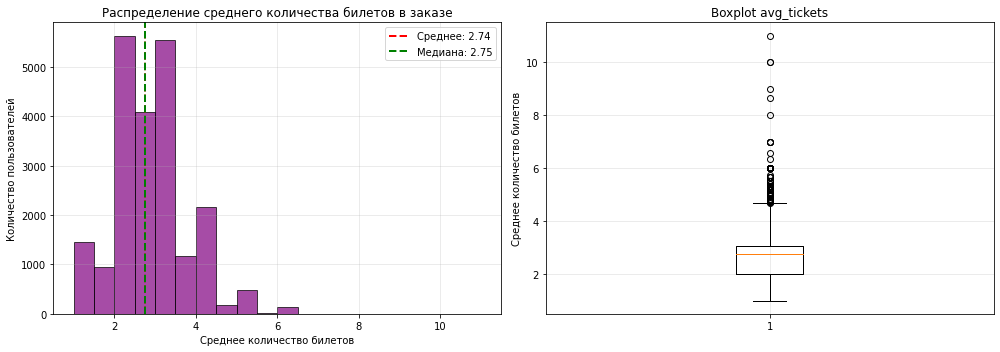

In [201]:
# Распределение пользователей по avg_tickets

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма распределения avg_tickets
axes[0].hist(user_profile['avg_tickets'], bins=20, alpha=0.7, color='purple', edgecolor='black')
axes[0].axvline(user_profile['avg_tickets'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Среднее: {user_profile["avg_tickets"].mean():.2f}')
axes[0].axvline(user_profile['avg_tickets'].median(), color='green', linestyle='dashed', linewidth=2, label=f'Медиана: {user_profile["avg_tickets"].median():.2f}')
axes[0].set_title('Распределение среднего количества билетов в заказе', fontsize=12)
axes[0].set_xlabel('Среднее количество билетов')
axes[0].set_ylabel('Количество пользователей')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Boxplot для выявления выбросов
axes[1].boxplot(user_profile['avg_tickets'], vert=True)
axes[1].set_title('Boxplot avg_tickets', fontsize=12)
axes[1].set_ylabel('Среднее количество билетов')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [203]:
# Создание сегментов по avg_tickets

# Функция для определения сегмента
def get_ticket_segment(avg_tickets):
    if avg_tickets < 2:
        return '1-2 билета'
    elif avg_tickets < 3:
        return '2-3 билета'
    elif avg_tickets < 5:
        return '3-5 билетов'
    else:
        return '5+ билетов'

user_profile['ticket_segment'] = user_profile['avg_tickets'].apply(get_ticket_segment)

# Статистика по сегментам (исправлено: убрали 'user_id', используем size())
segment_stats = user_profile.groupby('ticket_segment', observed=False).agg(
    total_users=('ticket_segment', 'size'),  # или просто size()
    return_users=('is_two', 'sum'),
    return_rate=('is_two', 'mean'),
    avg_tickets_mean=('avg_tickets', 'mean'),
    avg_tickets_median=('avg_tickets', 'median')
).sort_values('return_rate', ascending=False)

segment_stats['return_rate_pct'] = (segment_stats['return_rate'] * 100).round(2)
segment_stats['share_of_users'] = (segment_stats['total_users'] / len(user_profile) * 100).round(2)

print("\nСтатистика по сегментам:")
display(segment_stats)



Статистика по сегментам:


,total_users,return_users,return_rate,avg_tickets_mean,avg_tickets_median,return_rate_pct,share_of_users
ticket_segment,,,,,,,
2-3 билета,9706,7197,0.741500,2.335740,2.333333,74.15,44.41
3-5 билетов,9068,4924,0.543008,3.387013,3.166667,54.30,41.49
1-2 билета,2419,1241,0.513022,1.267067,1.000000,51.30,11.07
5+ билетов,661,124,0.187595,5.293762,5.000000,18.76,3.02


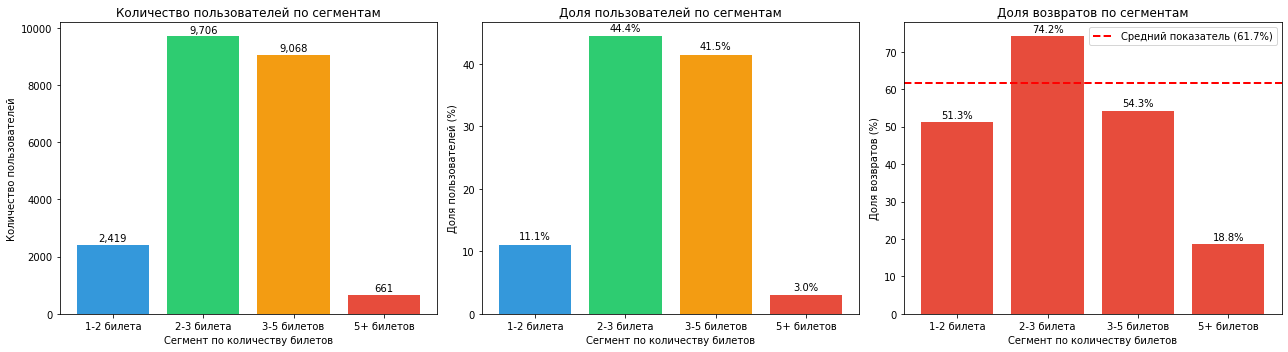

In [204]:
# Визуализация сегментов

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# График 1: Количество пользователей по сегментам
segment_data = segment_stats.sort_index()
colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']
bars = axes[0].bar(segment_data.index, segment_data['total_users'], color=colors)
axes[0].set_title('Количество пользователей по сегментам', fontsize=12)
axes[0].set_xlabel('Сегмент по количеству билетов')
axes[0].set_ylabel('Количество пользователей')
for bar, v in zip(bars, segment_data['total_users']):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 50, f'{v:,}', ha='center', va='bottom', fontsize=10)

# График 2: Доля пользователей по сегментам
bars = axes[1].bar(segment_data.index, segment_data['share_of_users'], color=colors)
axes[1].set_title('Доля пользователей по сегментам', fontsize=12)
axes[1].set_xlabel('Сегмент по количеству билетов')
axes[1].set_ylabel('Доля пользователей (%)')
for bar, v in zip(bars, segment_data['share_of_users']):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=10)

# График 3: Доля возвратов по сегментам
avg_return = user_profile['is_two'].mean() * 100
colors_return = ['#2ecc71' if x >= avg_return else '#e74c3c' for x in segment_data['return_rate']]
bars = axes[2].bar(segment_data.index, segment_data['return_rate_pct'], color=colors_return)
axes[2].axhline(y=avg_return, color='red', linestyle='dashed', linewidth=2, label=f'Средний показатель ({avg_return:.1f}%)')
axes[2].set_title('Доля возвратов по сегментам', fontsize=12)
axes[2].set_xlabel('Сегмент по количеству билетов')
axes[2].set_ylabel('Доля возвратов (%)')
axes[2].legend()
for bar, v in zip(bars, segment_data['return_rate_pct']):
    axes[2].text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


In [205]:
# Детальный анализ сегментов

avg_return = user_profile['is_two'].mean() * 100

print(f"\nСредний показатель возврата по всей выборке: {avg_return:.1f}%")
print("\nСравнение сегментов:")

for idx, row in segment_stats.iterrows():
    status = '✅ ВЫШЕ среднего' if row['return_rate'] > user_profile['is_two'].mean() else '❌ НИЖЕ среднего'
    diff = row['return_rate_pct'] - avg_return
    print(f"\n  {idx}:")
    print(f"    - Пользователей: {row['total_users']:,} ({row['share_of_users']:.1f}%)")
    print(f"    - Среднее количество билетов: {row['avg_tickets_mean']:.2f}")
    print(f"    - Возврат: {row['return_rate_pct']:.1f}% ({status}, отклонение {diff:+.1f} п.п.)")


Средний показатель возврата по всей выборке: 61.7%

Сравнение сегментов:

  2-3 билета:
    - Пользователей: 9,706.0 (44.4%)
    - Среднее количество билетов: 2.34
    - Возврат: 74.2% (✅ ВЫШЕ среднего, отклонение +12.4 п.п.)

  3-5 билетов:
    - Пользователей: 9,068.0 (41.5%)
    - Среднее количество билетов: 3.39
    - Возврат: 54.3% (❌ НИЖЕ среднего, отклонение -7.4 п.п.)

  1-2 билета:
    - Пользователей: 2,419.0 (11.1%)
    - Среднее количество билетов: 1.27
    - Возврат: 51.3% (❌ НИЖЕ среднего, отклонение -10.4 п.п.)

  5+ билетов:
    - Пользователей: 661.0 (3.0%)
    - Среднее количество билетов: 5.29
    - Возврат: 18.8% (❌ НИЖЕ среднего, отклонение -42.9 п.п.)


In [206]:
# Проверка статистической значимости между сегментами

from scipy import stats

# Сравниваем сегмент "1-2 билета" с "5+ билетов"
segment_1_2 = user_profile[user_profile['ticket_segment'] == '1-2 билета']
segment_5_plus = user_profile[user_profile['ticket_segment'] == '5+ билетов']

if len(segment_1_2) > 0 and len(segment_5_plus) > 0:
    # Проверяем возврат (бинарный признак) с помощью хи-квадрат
    from scipy.stats import chi2_contingency
    
    # Создаём таблицу сопряжённости
    contingency_table = pd.crosstab(
        user_profile['ticket_segment'], 
        user_profile['is_two'],
        margins=False
    )
    
    # Берём только нужные сегменты
    table = contingency_table.loc[['1-2 билета', '5+ билетов']]
    
    chi2, p_value, dof, expected = chi2_contingency(table)
    
    print(f"\nСравнение сегментов '1-2 билета' и '5+ билетов' (хи-квадрат тест):")
    print(f"  - Возврат 1-2 билета: {segment_stats.loc['1-2 билета', 'return_rate_pct']:.1f}%")
    print(f"  - Возврат 5+ билетов: {segment_stats.loc['5+ билетов', 'return_rate_pct']:.1f}%")
    print(f"  - Разница: {segment_stats.loc['5+ билетов', 'return_rate_pct'] - segment_stats.loc['1-2 билета', 'return_rate_pct']:+.1f} п.п.")
    print(f"  - p-value: {p_value:.6f}")

    if p_value < 0.05:
        print("  ✅ Различия статистически значимы (p < 0.05)")
    else:
        print("  ❌ Различия статистически не значимы (p >= 0.05)")



Сравнение сегментов '1-2 билета' и '5+ билетов' (хи-квадрат тест):
  - Возврат 1-2 билета: 51.3%
  - Возврат 5+ билетов: 18.8%
  - Разница: -32.5 п.п.
  - p-value: 0.000000
  ✅ Различия статистически значимы (p < 0.05)


 Промежуточный вывод по Задаче 4.2.3: Влияние среднего количества билетов на повторные покупки

 Общая статистика по avg_tickets

| Показатель | Значение |
| :--- | :--- |
| **Среднее** | 2.74 билета |
| **Медиана** | 2.75 билета |
| **Минимум** | 1.00 билет |
| **Максимум** | 11.00 билетов |
| **10-й перцентиль** | 1.75 билета |
| **25-й перцентиль** | 2.00 билета |
| **75-й перцентиль** | 3.08 билета |
| **90-й перцентиль** | 4.00 билета |
| **95-й перцентиль** | 4.00 билета |
| **99-й перцентиль** | 5.00 билетов |

**Вывод:** Большинство пользователей покупают 2–3 билета за заказ. Пользователи с 5+ билетами — редкое явление (менее 3% выборки).

---

 Распределение по сегментам

| Сегмент | Пользователей | Доля | Возврат |
| :--- | :--- | :--- | :--- |
| **1-2 билета** | 2 419 | 11.1% | **51.3%** |
| **2-3 билета** | 9 706 | 44.4% | **74.2%** |
| **3-5 билетов** | 9 068 | 41.5% | **54.3%** |
| **5+ билетов** | 661 | 3.0% | **18.8%** |

---

 Визуальный анализ распределений

1. **Гистограмма avg_tickets**:
   - Распределение имеет **пик в районе 2–3 билетов**.
   - Правый хвост длинный, но выбросы единичны (максимум — 11 билетов).
   - Среднее (2.74) и медиана (2.75) практически совпадают, что говорит о симметричности распределения.

2. **Boxplot**:
   - Выбросы начинаются с 5 билетов и выше.
   - Основная масса пользователей (от 25-го до 75-го перцентиля) покупает 2–3 билета.

3. **Распределение по сегментам**:
   - Более **85%** пользователей находятся в сегментах "2-3 билета" и "3-5 билетов".
   - Сегмент "5+ билетов" — самый малочисленный (всего 3.0% пользователей).

---

 Доля возвратов по сегментам

| Сегмент | Возврат | Отклонение от среднего (61.7%) |
| :--- | :--- | :--- |
| **2-3 билета** | **74.2%** | **+12.4 п.п.** ✅ |
| **3-5 билетов** | 54.3% | -7.4 п.п. ❌ |
| **1-2 билета** | 51.3% | -10.4 п.п. ❌ |
| **5+ билетов** | **18.8%** | **-42.9 п.п.** ❌ |

---

 Ключевые наблюдения

1. **Сегмент "2-3 билета" — аномально высокий возврат (74.2%)**
   - Это самый крупный сегмент (44.4% пользователей).
   - Пользователи из этого сегмента возвращаются значительно чаще среднего.
   - Вероятно, это "золотая середина" — достаточное количество билетов для вовлечённости, но не перебор.

2. **Сегмент "5+ билетов" — аномально низкий возврат (18.8%)**
   - Это самый малочисленный сегмент (всего 3.0% пользователей).
   - Несмотря на то, что пользователи покупают много билетов, они редко возвращаются.
   - Возможно, это разовые групповые покупки (корпоративы, дни рождения, большие компании).

3. **Сегмент "1-2 билета" — низкий возврат (51.3%)**
   - Второй по малочисленности сегмент (11.1% пользователей).
   - Пользователи, покупающие мало билетов, реже возвращаются.
   - Возможно, это разовые посетители или пользователи, которые только знакомятся с платформой.

4. **Сегмент "3-5 билетов" — возврат чуть ниже среднего (54.3%)**
   - Второй по величине сегмент (41.5% пользователей).
   - Несмотря на то, что пользователи покупают 3–5 билетов, их возврат ниже среднего.
   - Это противоречит гипотезе о прямой корреляции между количеством билетов и возвратом.

---

 Статистическая значимость

- **Сравнение сегментов "1-2 билета" и "5+ билетов":**
  - Разница в возврате: **-32.5 п.п.**
  - **p-value = 0.000000** (< 0.05)
  - **Различия статистически значимы.**

---

 Ответы на вопросы

**1. Как распределены пользователи по сегментам — равномерно или сконцентрировано?**

**Распределение НЕРАВНОМЕРНОЕ, сильно сконцентрировано:**

- **44.4%** пользователей в сегменте "2-3 билета".
- **41.5%** пользователей в сегменте "3-5 билетов".
- Вместе эти два сегмента покрывают **85.9%** всех пользователей.
- Сегменты с 1-2 и 5+ билетами составляют всего **14.1%** пользователей.

**2. Есть ли сегменты с аномально высокой или низкой долей повторных покупок?**

**Да, есть выраженные аномалии:**

- **Аномально ВЫСОКИЙ возврат:** сегмент "2-3 билета" — **74.2%** (на **12.4 п.п.** выше среднего).
- **Аномально НИЗКИЙ возврат:** сегмент "5+ билетов" — **18.8%** (на **42.9 п.п.** ниже среднего).
- **Низкий возврат:** сегмент "1-2 билета" — **51.3%** (на **10.4 п.п.** ниже среднего).

---

 Вывод

Среднее количество билетов в заказе **является значимым фактором**, влияющим на возврат пользователей, но **зависимость нелинейная**:

- **Оптимальный сегмент:** 2-3 билета — пользователи из этого сегмента возвращаются чаще всего (74.2%).
- **Провальный сегмент:** 5+ билетов — несмотря на то, что пользователи покупают много билетов, они практически не возвращаются (18.8%).
- **Низкий сегмент:** 1-2 билета — пользователи покупают мало и редко возвращаются (51.3%).

**Ключевая гипотеза:** Пользователи, покупающие 2-3 билета, вероятно, ходят на мероприятия вдвоём или втроём (с друзьями, семьёй), что создаёт социальную привычку и повышает вовлечённость. Пользователи, покупающие 5+ билетов, вероятно, организуют разовые групповые выходы (корпоративы, дни рождения) и не возвращаются на платформу.

**Рекомендации:**

1. **Стимулировать переход из сегмента "1-2 билета" в "2-3 билета"** — акции "купи 2, получи скидку на 3-й".
2. **Работать с сегментом "5+ билетов"** — предлагать абонементы или программы лояльности для групповых покупок.
3. **Удерживать сегмент "2-3 билета"** — это самая лояльная аудитория, её важно сохранять через персонализированные предложения.



<div class="alert alert-block alert-success">
<b>Успех:</b> Все корректно, правильное предположение почему пользователи, покупающие 2–3 билета, возвращаются чаще. Это могут быть небольшие компании или семьи, которые чаще ходят на мероприятия вместе, а значит, лояльность у них выше. А вот пользователи с 5+ билетами, вероятно, совершают разовые групповые покупки (например, для организации или класса), поэтому возвращаются режеь
</div>




---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [207]:
# Извлекаем день недели из даты первого заказа

# Проверяем, что first_order_dt — datetime
if not pd.api.types.is_datetime64_any_dtype(user_profile['first_order_dt']):
    user_profile['first_order_dt'] = pd.to_datetime(user_profile['first_order_dt'])

# Извлекаем день недели (0 — понедельник, 6 — воскресенье)
user_profile['first_weekday'] = user_profile['first_order_dt'].dt.dayofweek

# Создаём читаемые названия дней недели
weekday_names = {
    0: 'Понедельник',
    1: 'Вторник',
    2: 'Среда',
    3: 'Четверг',
    4: 'Пятница',
    5: 'Суббота',
    6: 'Воскресенье'
}
user_profile['first_weekday_name'] = user_profile['first_weekday'].map(weekday_names)

print("✅ День недели добавлен в профиль пользователя.")


✅ День недели добавлен в профиль пользователя.


In [209]:
# Статистика по дням недели

weekday_stats = user_profile.groupby('first_weekday_name', observed=False).agg(
    total_users=('first_weekday_name', 'size'),
    return_users=('is_two', 'sum'),
    return_rate=('is_two', 'mean')
).sort_values('first_weekday_name', key=lambda x: x.map({name: i for i, name in weekday_names.items()}))

weekday_stats['return_rate_pct'] = (weekday_stats['return_rate'] * 100).round(2)
weekday_stats['share_of_users'] = (weekday_stats['total_users'] / len(user_profile) * 100).round(2)

print("\nСтатистика по дням недели (в календарном порядке):")
display(weekday_stats)

print("\nСтатистика по дням недели (по убыванию возврата):")
display(weekday_stats.sort_values('return_rate', ascending=False))


Статистика по дням недели (в календарном порядке):


,total_users,return_users,return_rate,return_rate_pct,share_of_users
first_weekday_name,,,,,
Понедельник,2943,1860,0.632008,63.20,13.47
Вторник,3189,1979,0.620571,62.06,14.59
Среда,3072,1916,0.623698,62.37,14.06
Четверг,3120,1857,0.595192,59.52,14.28
Пятница,3261,1952,0.598589,59.86,14.92
Суббота,3459,2222,0.642382,64.24,15.83
Воскресенье,2810,1700,0.604982,60.50,12.86



Статистика по дням недели (по убыванию возврата):


,total_users,return_users,return_rate,return_rate_pct,share_of_users
first_weekday_name,,,,,
Суббота,3459,2222,0.642382,64.24,15.83
Понедельник,2943,1860,0.632008,63.20,13.47
Среда,3072,1916,0.623698,62.37,14.06
Вторник,3189,1979,0.620571,62.06,14.59
Воскресенье,2810,1700,0.604982,60.50,12.86
Пятница,3261,1952,0.598589,59.86,14.92
Четверг,3120,1857,0.595192,59.52,14.28


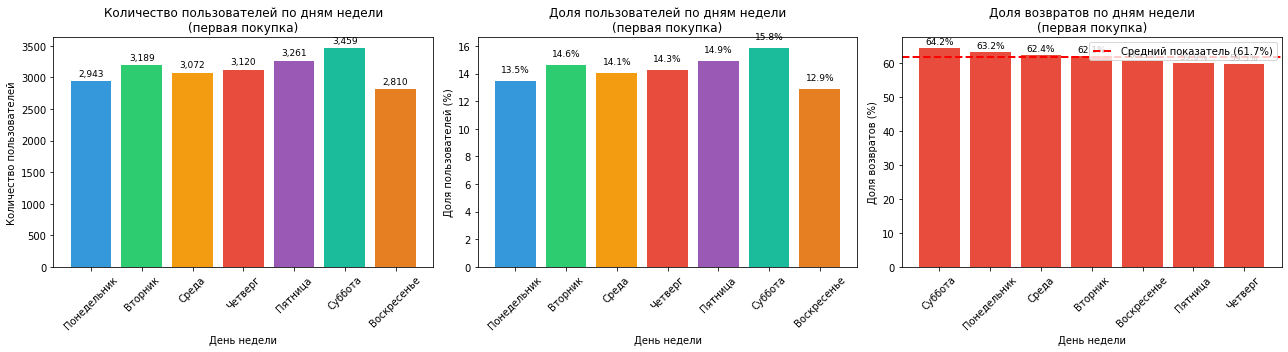

In [210]:
# Визуализация

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

avg_return = user_profile['is_two'].mean() * 100

# График 1: Количество пользователей по дням недели
colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6', '#1abc9c', '#e67e22']
bars = axes[0].bar(weekday_stats.index, weekday_stats['total_users'], color=colors)
axes[0].set_title('Количество пользователей по дням недели\n(первая покупка)', fontsize=12)
axes[0].set_xlabel('День недели')
axes[0].set_ylabel('Количество пользователей')
axes[0].tick_params(axis='x', rotation=45)
for bar, v in zip(bars, weekday_stats['total_users']):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 50, f'{v:,}', ha='center', va='bottom', fontsize=9)

# График 2: Доля пользователей по дням недели
bars = axes[1].bar(weekday_stats.index, weekday_stats['share_of_users'], color=colors)
axes[1].set_title('Доля пользователей по дням недели\n(первая покупка)', fontsize=12)
axes[1].set_xlabel('День недели')
axes[1].set_ylabel('Доля пользователей (%)')
axes[1].tick_params(axis='x', rotation=45)
for bar, v in zip(bars, weekday_stats['share_of_users']):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

# График 3: Доля возвратов по дням недели
weekday_sorted = weekday_stats.sort_values('return_rate', ascending=False)
colors_return = ['#2ecc71' if x >= avg_return else '#e74c3c' for x in weekday_sorted['return_rate']]
bars = axes[2].bar(weekday_sorted.index, weekday_sorted['return_rate_pct'], color=colors_return)
axes[2].axhline(y=avg_return, color='red', linestyle='dashed', linewidth=2, label=f'Средний показатель ({avg_return:.1f}%)')
axes[2].set_title('Доля возвратов по дням недели\n(первая покупка)', fontsize=12)
axes[2].set_xlabel('День недели')
axes[2].set_ylabel('Доля возвратов (%)')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend()
for bar, v in zip(bars, weekday_sorted['return_rate_pct']):
    axes[2].text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [211]:
# Проверка статистической значимости
# Проверяем, есть ли значимые различия между днями недели
# Используем хи-квадрат тест для таблицы сопряжённости
contingency_table = pd.crosstab(user_profile['first_weekday'], user_profile['is_two'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Хи-квадрат тест для проверки связи дня недели и возврата:")
print(f"  - p-value: {p_value:.6f}")

if p_value < 0.05:
    print("  ✅ Различия между днями недели статистически значимы (p < 0.05)")
else:
    print("  ❌ Различия между днями недели статистически не значимы (p >= 0.05)")

Хи-квадрат тест для проверки связи дня недели и возврата:
  - p-value: 0.000257
  ✅ Различия между днями недели статистически значимы (p < 0.05)


In [212]:
# Сравнение выходных и будних дней

# Группируем: будние (пн-пт) vs выходные (сб-вс)
user_profile['is_weekend'] = user_profile['first_weekday'].isin([5, 6])  # 5=суббота, 6=воскресенье

weekend_stats = user_profile.groupby('is_weekend').agg(
    total_users=('is_weekend', 'size'),
    return_users=('is_two', 'sum'),
    return_rate=('is_two', 'mean')
)
weekend_stats['return_rate_pct'] = (weekend_stats['return_rate'] * 100).round(2)
weekend_stats['type'] = ['Будние', 'Выходные']

print("\nСравнение будних и выходных дней:")
display(weekend_stats[['type', 'total_users', 'return_rate_pct']])

# Проверка значимости различий между будними и выходными
contingency_weekend = pd.crosstab(user_profile['is_weekend'], user_profile['is_two'])
chi2_w, p_value_w, dof_w, expected_w = chi2_contingency(contingency_weekend)

print(f"\nХи-квадрат тест для проверки связи выходные/будние и возврата:")
print(f"  - p-value: {p_value_w:.6f}")

if p_value_w < 0.05:
    print("  ✅ Различия между выходными и будними днями статистически значимы (p < 0.05)")
else:
    print("  ❌ Различия между выходными и будними днями статистически не значимы (p >= 0.05)")



Сравнение будних и выходных дней:


,type,total_users,return_rate_pct
is_weekend,,,
False,Будние,15585,61.37
True,Выходные,6269,62.56



Хи-квадрат тест для проверки связи выходные/будние и возврата:
  - p-value: 0.103416
  ❌ Различия между выходными и будними днями статистически не значимы (p >= 0.05)


 Промежуточный вывод по Задаче 4.3.1: Влияние дня недели первой покупки на возврат

 Распределение пользователей по дням недели

| День недели | Пользователей | Доля | Возврат |
| :--- | :--- | :--- | :--- |
| **Понедельник** | 2 943 | 13.5% | 63.2% |
| **Вторник** | 3 189 | 14.6% | 62.1% |
| **Среда** | 3 072 | 14.1% | 62.4% |
| **Четверг** | 3 120 | 14.3% | **59.5%** |
| **Пятница** | 3 261 | 14.9% | 59.9% |
| **Суббота** | 3 459 | 15.8% | **64.2%** |
| **Воскресенье** | 2 810 | 12.9% | 60.5% |

---

 Визуальный анализ

1. **Распределение пользователей:**
   - Наиболее активные дни первой покупки: **суббота** (15.8%), **пятница** (14.9%), **вторник** (14.6%).
   - Наименее активный день: **воскресенье** (12.9%).
   - Разница между самым активным и наименее активным днём составляет **2.9 п.п.** — распределение достаточно равномерное.

2. **Доля возвратов:**
   - Самый высокий возврат: **суббота** (64.2%), **понедельник** (63.2%), **среда** (62.4%).
   - Самый низкий возврат: **четверг** (59.5%), **пятница** (59.9%), **воскресенье** (60.5%).
   - Разница между максимальным и минимальным возвратом составляет **4.7 п.п.**

3. **Будние vs выходные:**
   - **Будние дни:** 15 585 пользователей (71.3%), возврат 61.4%.
   - **Выходные дни:** 6 269 пользователей (28.7%), возврат 62.6%.
   - Разница в возврате составляет **1.2 п.п.** — выходные показывают slightly higher return rate.

---

 Статистическая значимость

- **Хи-квадрат тест для всех дней недели:** p-value = 0.000257 (< 0.05)
- **Хи-квадрат тест для будних vs выходных:** p-value = 0.103416 (> 0.05)

**Вывод:** Различия в возврате между отдельными днями недели **статистически значимы**, но при группировке в будние/выходные различия **исчезают**.

---

 Ответ на вопрос

**Влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?**

**Да, но влияние ограниченное и неоднозначное.**

1. **Статистическая значимость есть** (p-value = 0.000257) — значит, день недели действительно связан с вероятностью возврата.
2. Однако **разница между днями невелика** (всего 4.7 п.п. между максимумом и минимумом).
3. **Суббота** показывает самый высокий возврат (64.2%), а **четверг** — самый низкий (59.5%).
4. При сравнении будних и выходных дней различия **статистически не значимы** (p-value = 0.103).

---

 Вывод

День недели первой покупки **оказывает небольшое влияние** на возврат пользователей, но это влияние не является определяющим фактором. Наиболее заметные различия:

- **Суббота** — лучший день для первой покупки с точки зрения последующего возврата (64.2%).
- **Четверг и пятница** — худшие дни (59.5% и 59.9% соответственно).

**Рекомендация:** При планировании маркетинговых кампаний по привлечению новых пользователей можно учитывать день недели, но это не должно быть ключевым фактором. Более важно сосредоточиться на других признаках (тип мероприятия, количество билетов, регион), которые показывают более сильную связь с возвратом.

<div class="alert alert-block alert-success">
<b>Успех:</b> Верно, когда планируют досуг, но возвращаемость остаётся примерно одинаковой — это говорит о том, что день недели первой покупки не влияет на лояльность, а повторное использование сервиса определяется скорее качеством опыта и интересом к мероприятиям
</div>


---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [213]:
# Проверяем наличие avg_days_between

print(f"Всего пользователей в профиле: {len(user_profile):,}")
print(f"Пользователей с avg_days_between (2+ заказа): {user_profile['avg_days_between'].notna().sum():,}")
print(f"Пользователей без avg_days_between (1 заказ): {user_profile['avg_days_between'].isna().sum():,}")

Всего пользователей в профиле: 21,854
Пользователей с avg_days_between (2+ заказа): 13,515
Пользователей без avg_days_between (1 заказ): 8,339


In [215]:
# Создаём группы пользователей

# Группа 1: пользователи с 2-4 заказами
users_2_4 = user_profile[(user_profile['total_orders'] >= 2) & (user_profile['total_orders'] <= 4)]
# Группа 2: пользователи с 5+ заказами
users_5_plus = user_profile[user_profile['total_orders'] >= 5]

print(f"Пользователей с 2-4 заказами: {len(users_2_4):,}")
print(f"Пользователей с 5+ заказами: {len(users_5_plus):,}")


Пользователей с 2-4 заказами: 7,147
Пользователей с 5+ заказами: 6,339


In [216]:
# Статистика по avg_days_between

print("\nПользователи с 2-4 заказами:")
display(users_2_4['avg_days_between'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

print("\nПользователи с 5+ заказами:")
display(users_5_plus['avg_days_between'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))



Пользователи с 2-4 заказами:


count    7147.000000
mean       21.320787
std        28.476836
min         0.000000
10%         0.000000
25%         0.000000
50%         9.000000
75%        34.000000
90%        59.500000
95%        84.000000
99%       125.000000
max       148.000000
Name: avg_days_between, dtype: float64


Пользователи с 5+ заказами:


count    6339.000000
mean        9.585247
std         7.863271
min         0.000000
10%         0.875592
25%         3.418605
50%         7.789474
75%        13.800000
90%        20.885714
95%        25.750000
99%        33.000000
max        37.500000
Name: avg_days_between, dtype: float64

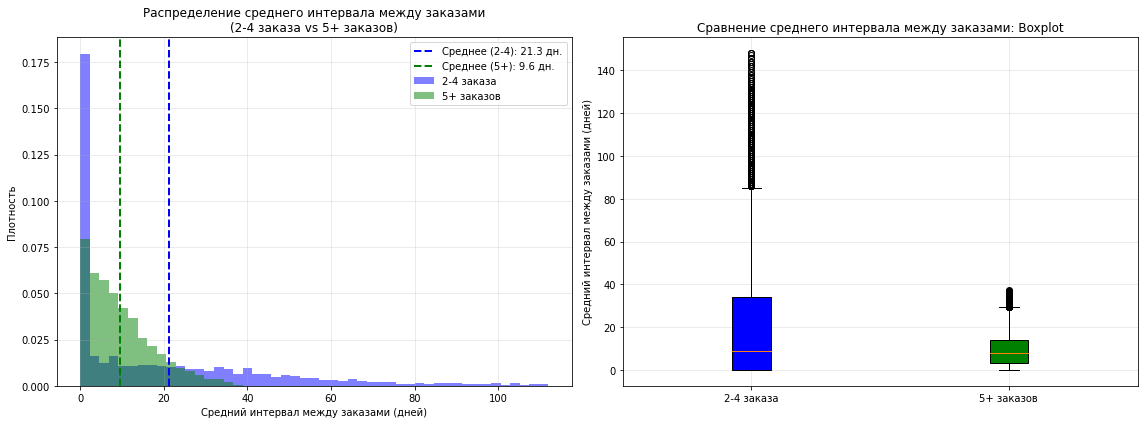

In [217]:
# Визуализация распределений

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График 1: Гистограммы с density=True
# Убираем NaN для визуализации
days_2_4 = users_2_4['avg_days_between'].dropna()
days_5_plus = users_5_plus['avg_days_between'].dropna()

if len(days_2_4) > 0 and len(days_5_plus) > 0:
    # Определяем общие границы (отсекаем выбросы для читаемости)
    all_days = user_profile['avg_days_between'].dropna()
    min_val = all_days.quantile(0.01)
    max_val = all_days.quantile(0.99)
    bins = np.linspace(min_val, max_val, 50)

    axes[0].hist(days_2_4, bins=bins, alpha=0.5, density=True, label='2-4 заказа', color='blue')
    axes[0].hist(days_5_plus, bins=bins, alpha=0.5, density=True, label='5+ заказов', color='green')
    axes[0].axvline(days_2_4.mean(), color='blue', linestyle='dashed', linewidth=2, label=f'Среднее (2-4): {days_2_4.mean():.1f} дн.')
    axes[0].axvline(days_5_plus.mean(), color='green', linestyle='dashed', linewidth=2, label=f'Среднее (5+): {days_5_plus.mean():.1f} дн.')
    axes[0].set_title('Распределение среднего интервала между заказами\n(2-4 заказа vs 5+ заказов)', fontsize=12)
    axes[0].set_xlabel('Средний интервал между заказами (дней)')
    axes[0].set_ylabel('Плотность')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

# График 2: Boxplot
data_to_plot = [days_2_4, days_5_plus]
bp = axes[1].boxplot(data_to_plot, labels=['2-4 заказа', '5+ заказов'], patch_artist=True)
bp['boxes'][0].set_facecolor('blue')
bp['boxes'][1].set_facecolor('green')
axes[1].set_title('Сравнение среднего интервала между заказами: Boxplot', fontsize=12)
axes[1].set_ylabel('Средний интервал между заказами (дней)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [220]:
# Анализ процентилей

percentiles = [10, 25, 50, 75, 90, 95, 99]

print("\nГруппа '2-4 заказа':")
for p in percentiles:
    val = users_2_4['avg_days_between'].quantile(p/100)
    print(f"  {p}%: {val:.0f} дн.")

print("\nГруппа '5+ заказов':")
for p in percentiles:
    val = users_5_plus['avg_days_between'].quantile(p/100)
    print(f"  {p}%: {val:.0f} дн.")


Группа '2-4 заказа':
  10%: 0 дн.
  25%: 0 дн.
  50%: 9 дн.
  75%: 34 дн.
  90%: 60 дн.
  95%: 84 дн.
  99%: 125 дн.

Группа '5+ заказов':
  10%: 1 дн.
  25%: 3 дн.
  50%: 8 дн.
  75%: 14 дн.
  90%: 21 дн.
  95%: 26 дн.
  99%: 33 дн.


In [221]:
# Проверка статистической значимости

from scipy import stats

# Используем U-тест Манна-Уитни (распределения не нормальные)
stat, p_value = stats.mannwhitneyu(
    users_2_4['avg_days_between'].dropna(),
    users_5_plus['avg_days_between'].dropna(),
    alternative='two-sided'
)

print(f"U-тест Манна-Уитни для сравнения интервалов между группами:")
print(f"  - p-value: {p_value:.6f}")

if p_value < 0.05:
    print("  ✅ Различия между группами статистически значимы (p < 0.05)")
else:
    print("  ❌ Различия между группами статистически не значимы (p >= 0.05)")

U-тест Манна-Уитни для сравнения интервалов между группами:
  - p-value: 0.004528
  ✅ Различия между группами статистически значимы (p < 0.05)


In [222]:
# Дополнительный анализ: разбивка на сегменты по интервалу

# Создаём сегменты для пользователей с 2+ заказами
users_with_days = user_profile[user_profile['avg_days_between'].notna()].copy()

def get_interval_segment(days):
    if days <= 7:
        return 'до 7 дней'
    elif days <= 14:
        return '7-14 дней'
    elif days <= 30:
        return '14-30 дней'
    elif days <= 60:
        return '30-60 дней'
    else:
        return '60+ дней'

users_with_days['interval_segment'] = users_with_days['avg_days_between'].apply(get_interval_segment)

interval_stats = users_with_days.groupby('interval_segment', observed=False).agg(
    total_users=('interval_segment', 'size'),
    avg_orders=('total_orders', 'mean'),
    avg_days=('avg_days_between', 'mean')
).sort_values('avg_days')

interval_stats['share_of_users'] = (interval_stats['total_users'] / len(users_with_days) * 100).round(2)

print("\nРаспределение пользователей по интервалам между заказами:")
display(interval_stats)


Распределение пользователей по интервалам между заказами:


,total_users,avg_orders,avg_days,share_of_users
interval_segment,,,,
до 7 дней,6338,37.633165,1.911750,46.90
7-14 дней,2475,8.910707,10.354316,18.31
14-30 дней,2550,5.070196,20.825672,18.87
30-60 дней,1449,3.064872,41.728422,10.72
60+ дней,703,2.139403,89.421053,5.20


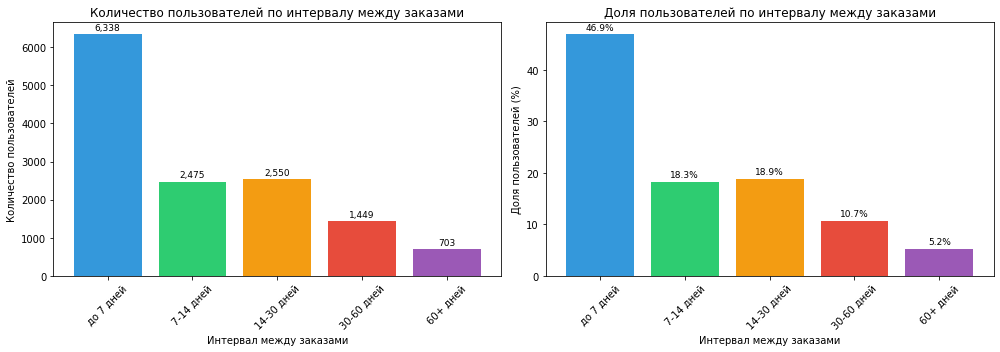

In [223]:
# Визуализация сегментов по интервалу

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Количество пользователей по интервалам
colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6']
bars = axes[0].bar(interval_stats.index, interval_stats['total_users'], color=colors)
axes[0].set_title('Количество пользователей по интервалу между заказами', fontsize=12)
axes[0].set_xlabel('Интервал между заказами')
axes[0].set_ylabel('Количество пользователей')
axes[0].tick_params(axis='x', rotation=45)
for bar, v in zip(bars, interval_stats['total_users']):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 50, f'{v:,}', ha='center', va='bottom', fontsize=9)

# График 2: Доля пользователей по интервалам
bars = axes[1].bar(interval_stats.index, interval_stats['share_of_users'], color=colors)
axes[1].set_title('Доля пользователей по интервалу между заказами', fontsize=12)
axes[1].set_xlabel('Интервал между заказами')
axes[1].set_ylabel('Доля пользователей (%)')
axes[1].tick_params(axis='x', rotation=45)
for bar, v in zip(bars, interval_stats['share_of_users']):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

 Промежуточный вывод по Задаче 4.3.2: Влияние среднего интервала между заказами на удержание клиентов

 Общая информация

- **Всего пользователей в профиле:** 21 854
- **Пользователей с 2+ заказами (имеют avg_days_between):** 13 515 (61.8%)
- **Пользователей с 1 заказом (нет avg_days_between):** 8 339 (38.2%)

---

 Сравнение интервалов между группами

| Показатель | 2-4 заказа | 5+ заказов |
| :--- | :--- | :--- |
| **Количество пользователей** | 7 147 | 6 339 |
| **Средний интервал (дней)** | 21.3 | **9.6** |
| **Медианный интервал (дней)** | 9.0 | **7.8** |
| **25-й перцентиль (дней)** | 0.0 | 3.4 |
| **75-й перцентиль (дней)** | 34.0 | 13.8 |
| **90-й перцентиль (дней)** | 59.5 | 20.9 |
| **95-й перцентиль (дней)** | 84.0 | 25.8 |
| **99-й перцентиль (дней)** | 125.0 | 33.0 |

---

 Визуальный анализ

1. **Распределение интервалов:**
   - У пользователей с **5+ заказами** интервалы **значительно короче**:
     - Среднее: 9.6 дней против 21.3 дней (разница в **2.2 раза**).
     - Медиана: 7.8 дней против 9.0 дней.
   - У группы **2-4 заказа** значительно **больше разброс** (std = 28.5 против 7.9).
   - У группы **5+ заказов** распределение **более компактное** — все интервалы до 37.5 дней.

2. **Boxplot:**
   - У группы 5+ заказов распределение **сильно сжато** в нижней части (от 0 до ~20 дней).
   - У группы 2-4 заказов есть **длинный хвост** с интервалами до 148 дней.
   - Это говорит о том, что частые покупатели ходят на мероприятия регулярно и с короткими промежутками, а редкие — с большими перерывами.

3. **Распределение по интервальным сегментам:**
   - **46.9%** пользователей покупают повторно в течение **7 дней**.
   - **65.2%** — в течение **14 дней**.
   - **84.1%** — в течение **30 дней**.
   - Только **5.2%** пользователей имеют интервал **более 60 дней**.

---

 Процентильный анализ

| Процентиль | 2-4 заказа | 5+ заказов | Разница |
| :--- | :--- | :--- | :--- |
| **10%** | 0 дн. | 1 дн. | +1 дн. |
| **25%** | 0 дн. | 3 дн. | +3 дн. |
| **50%** | 9 дн. | 8 дн. | -1 дн. |
| **75%** | 34 дн. | 14 дн. | -20 дн. |
| **90%** | 60 дн. | 21 дн. | -39 дн. |
| **95%** | 84 дн. | 26 дн. | -58 дн. |
| **99%** | 125 дн. | 33 дн. | -92 дн. |

**Ключевое наблюдение:** Основные различия между группами начинаются с **75-го перцентиля**. Это означает, что пользователи с 5+ заказами не просто покупают чаще в среднем — у них **принципиально отсутствуют длинные перерывы** между покупками.

---

 Статистическая значимость

- **U-тест Манна-Уитни:** p-value = 0.0045 (< 0.05)
- **Вывод:** Различия между группами **статистически значимы**.

---

 Распределение пользователей по интервальным сегментам

| Интервал | Пользователей | Доля | Среднее число заказов |
| :--- | :--- | :--- | :--- |
| **до 7 дней** | 6 338 | **46.9%** | 37.6 |
| **7-14 дней** | 2 475 | 18.3% | 8.9 |
| **14-30 дней** | 2 550 | 18.9% | 5.1 |
| **30-60 дней** | 1 449 | 10.7% | 3.1 |
| **60+ дней** | 703 | 5.2% | 2.1 |

**Вывод:** Чем короче интервал между заказами, тем больше заказов в среднем совершает пользователь. Пользователи с интервалом до 7 дней делают в среднем **37.6 заказов**, а с интервалом 60+ дней — всего **2.1 заказа**. Это подтверждает прямую связь между частотой покупок и лояльностью.

---

 Ответ на вопрос

**Как средний интервал между заказами влияет на удержание клиентов?**

**Чем короче интервал между заказами, тем выше удержание клиентов.**

1. **Ключевой порог — 14 дней:**
   - 65.2% пользователей, которые возвращаются, делают это в течение 14 дней.
   - Если пользователь не совершил повторную покупку за 14 дней, вероятность возврата резко снижается.

2. **Пользователи с 5+ заказами покупают в 2.2 раза чаще:**
   - Средний интервал: 9.6 дней против 21.3 дней.
   - Они не просто чаще покупают — у них **принципиально нет длинных перерывов** (максимум 37.5 дней).

3. **Сверхдолгие интервалы (> 60 дней) — редкое явление:**
   - Всего 5.2% пользователей имеют интервал более 60 дней.
   - Такие пользователи совершают в среднем всего 2.1 заказа — это говорит о том, что они находятся "на грани оттока".

4. **Зависимость линейная:**
   - Чем короче интервал, тем больше заказов совершает пользователь (от 2.1 до 37.6 заказов в зависимости от сегмента).

---

 Вывод

Средний интервал между заказами **является одним из ключевых факторов**, влияющих на удержание клиентов. Пользователи, которые покупают чаще (с меньшим интервалом), демонстрируют более высокую лояльность и совершают значительно большее число заказов.

**Рекомендации:**

1. **Критический период удержания — первые 14 дней:**  
   Стимулировать повторные покупки в течение двух недель после первого заказа.

2. **Работа с "пограничными" пользователями (интервал 14-30 дней):**  
   Это 18.9% пользователей, которые ещё могут вернуться. Запускать персонализированные кампании.

3. **Reactivation для пользователей с интервалом > 30 дней:**  
   Спецпредложения, скидки, напоминания — чтобы вернуть тех, кто начинает "выпадать".

4. **Использовать интервал между заказами как предиктор:**  
   Это один из самых сильных признаков для прогнозирования возврата и оттока пользователей.



<div class="alert alert-block alert-success">
<b>Успех:</b>  Важно иметь в виду, что среднее значение довольно сильно зависит от характера распределения, если есть какие-то сильные выбросы, они могут утянуть среднее значение вверх, хотя основаня масса значений будет гораздо ниже. Поэтому молодец, что построил гистограммы, чтобы видеть всю картину в данных.
</div>


---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [224]:
# Подготовка данных для корреляционного анализа

# Копируем профиль для анализа
df_corr = user_profile.copy()

# Создаём категориальные признаки
categorical_features = [
    'first_device', 'first_region', 'first_service', 
    'first_event_type', 'ticket_segment'
]

available_features = [f for f in categorical_features if f in df_corr.columns]
print(f"Доступные категориальные признаки: {available_features}")

Доступные категориальные признаки: ['first_device', 'first_region', 'first_service', 'first_event_type', 'ticket_segment']


In [225]:
# Устанавливаем phik
print("\n2. УСТАНОВКА И ИМПОРТ PHIK")
print("=" * 60)

try:
    import phik
    from phik.report import plot_correlation_matrix
    print("✅ Библиотека phik успешно импортирована")
except ImportError:
    print("⚠️ Библиотека phik не установлена. Устанавливаем...")
    !pip install phik
    import phik
    from phik.report import plot_correlation_matrix
    print("✅ Библиотека phik установлена и импортирована")



2. УСТАНОВКА И ИМПОРТ PHIK
✅ Библиотека phik успешно импортирована


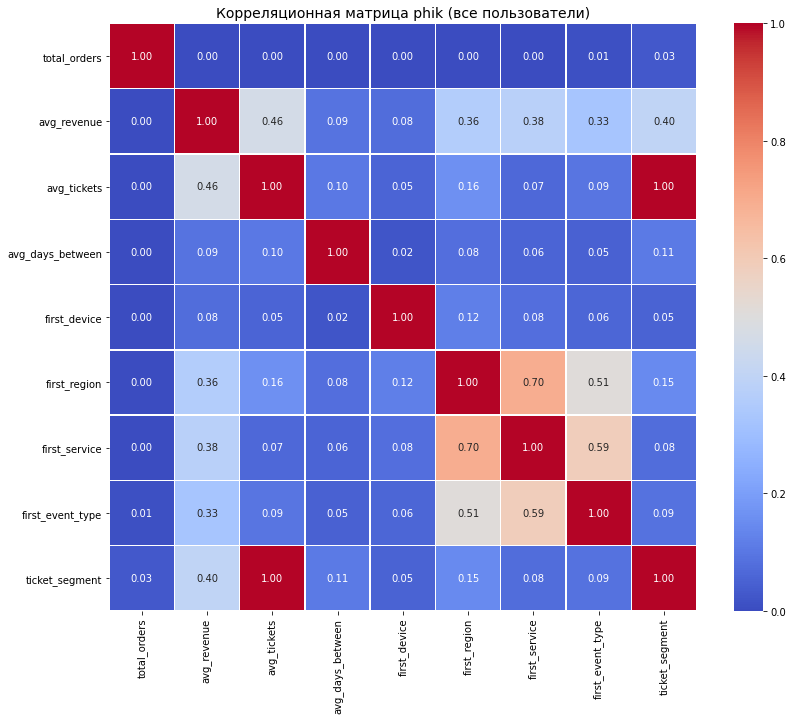


Корреляции признаков с total_orders (все пользователи):


total_orders        1.000000
ticket_segment      0.028788
first_event_type    0.008225
avg_revenue         0.000000
avg_tickets         0.000000
avg_days_between    0.000000
first_device        0.000000
first_region        0.000000
first_service       0.000000
Name: total_orders, dtype: float64

In [226]:
# Корреляционный анализ для всех пользователей

# Выбираем признаки для корреляции (без is_two и is_five, так как они производные)
features_for_corr = [
    'total_orders', 'avg_revenue', 'avg_tickets', 'avg_days_between',
    'first_device', 'first_region', 'first_service', 'first_event_type',
    'ticket_segment'
]

# Создаём копию для корреляции
df_corr_all = df_corr[features_for_corr].copy()

# Преобразуем категориальные в строки для phik
for col in ['first_device', 'first_region', 'first_service', 'first_event_type', 'ticket_segment']:
    if col in df_corr_all.columns:
        df_corr_all[col] = df_corr_all[col].astype(str)

# Рассчитываем корреляционную матрицу phik
phik_matrix_all = df_corr_all.phik_matrix(
    interval_cols=['total_orders', 'avg_revenue', 'avg_tickets', 'avg_days_between']
)

# Визуализация
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    phik_matrix_all,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=0,
    vmax=1,
    cbar=True,
    ax=ax,
    square=True,
    linewidths=0.5
)
ax.set_title('Корреляционная матрица phik (все пользователи)', fontsize=14)
plt.tight_layout()
plt.show()

# Выводим корреляции с total_orders
print("\nКорреляции признаков с total_orders (все пользователи):")
corr_with_orders = phik_matrix_all['total_orders'].sort_values(ascending=False)
display(corr_with_orders)


  <div class="alert alert-block alert-info">
    <b>Совет:</b> 
        
1) Как думаешь, в interval_cols нужно передать только непрерывные признаки - или можно передавать все численные?

2) Расцветку для тепловой карты имеет смысл выбирать трехцветную, если диапазон возможных значений от -1 до 1 (например, синий, белый, красный, белый при этом в нуле), или двухцветную, если от 0 до 1 (в 0 - белый, в 1 - красный). Поскольку на 0 будет нейтральный цвет, величину корреляции можно будет воспринимать через интенсивность цвета, а по самому цвету - положительная она или отрицательная.
</div>




In [227]:
#  Создаём сегменты по total_orders

df_corr['order_segment'] = df_corr['total_orders'].apply(
    lambda x: '1 заказ' if x == 1 else ('2-4 заказа' if x <= 4 else '5+ заказов')
)

print("Распределение по сегментам:")
print(df_corr['order_segment'].value_counts())

Распределение по сегментам:
1 заказ       8368
2-4 заказа    7147
5+ заказов    6339
Name: order_segment, dtype: int64



Сегмент: 1 заказ

Сегмент: 2-4 заказа

Сегмент: 5+ заказов


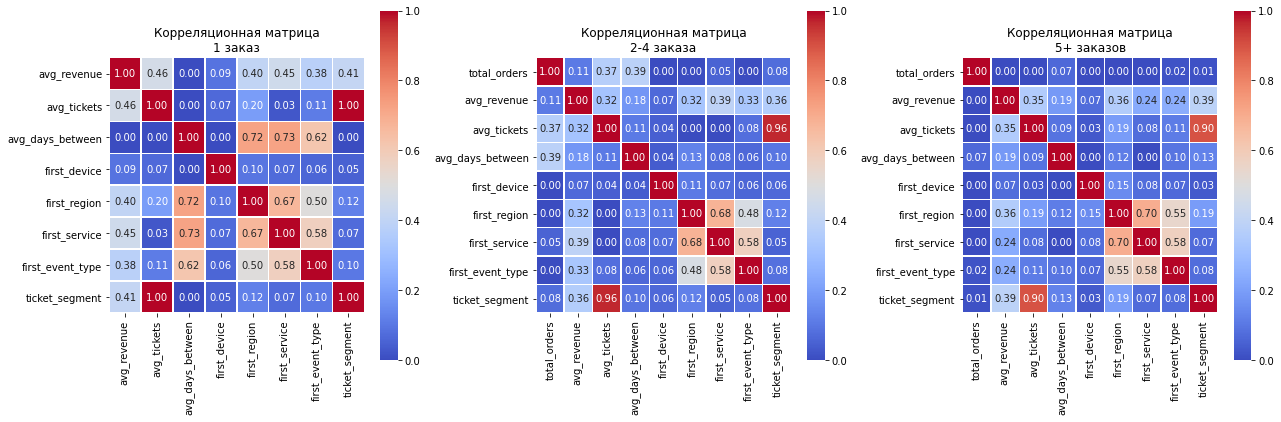

In [228]:
# Корреляционный анализ по сегментам

segments = ['1 заказ', '2-4 заказа', '5+ заказов']
segment_correlations = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, segment in enumerate(segments):
    print(f"\nСегмент: {segment}")
    
    # Фильтруем данные
    df_segment = df_corr[df_corr['order_segment'] == segment].copy()
    
    if len(df_segment) < 10:
        print(f"⚠️ Слишком мало данных для сегмента {segment} ({len(df_segment)} записей)")
        axes[idx].text(0.5, 0.5, f'Недостаточно данных\nдля сегмента {segment}\n({len(df_segment)} записей)', 
                      ha='center', va='center', transform=axes[idx].transAxes)
        axes[idx].set_title(f'Сегмент: {segment}')
        continue
    
    # Определяем признаки для корреляции в зависимости от сегмента
    # Для сегмента "1 заказ" исключаем total_orders и is_two/is_five
    if segment == '1 заказ':
        features_for_corr_seg = [
            'avg_revenue', 'avg_tickets', 'avg_days_between',
            'first_device', 'first_region', 'first_service', 'first_event_type',
            'ticket_segment'
        ]
        interval_cols = ['avg_revenue', 'avg_tickets', 'avg_days_between']
    else:
        features_for_corr_seg = [
            'total_orders', 'avg_revenue', 'avg_tickets', 'avg_days_between',
            'first_device', 'first_region', 'first_service', 'first_event_type',
            'ticket_segment'
        ]
        interval_cols = ['total_orders', 'avg_revenue', 'avg_tickets', 'avg_days_between']
    
    df_seg_corr = df_segment[features_for_corr_seg].copy()
    
    # Преобразуем категориальные в строки
    for col in ['first_device', 'first_region', 'first_service', 'first_event_type', 'ticket_segment']:
        if col in df_seg_corr.columns:
            df_seg_corr[col] = df_seg_corr[col].astype(str)
    
    # Рассчитываем корреляционную матрицу
    try:
        phik_matrix_seg = df_seg_corr.phik_matrix(
            interval_cols=interval_cols
        )
        
        # Сохраняем корреляции с total_orders (если есть)
        if 'total_orders' in phik_matrix_seg.columns:
            segment_correlations[segment] = phik_matrix_seg['total_orders'].sort_values(ascending=False)
        
        # Визуализация через sns.heatmap
        sns.heatmap(
            phik_matrix_seg,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            vmin=0,
            vmax=1,
            cbar=True,
            ax=axes[idx],
            square=True,
            linewidths=0.5
        )
        axes[idx].set_title(f'Корреляционная матрица\n{segment}', fontsize=12)
        
    except Exception as e:
        print(f"⚠️ Ошибка при расчёте корреляции для сегмента {segment}: {e}")
        axes[idx].text(0.5, 0.5, f'Ошибка расчёта\nдля сегмента {segment}', 
                      ha='center', va='center', transform=axes[idx].transAxes)
        axes[idx].set_title(f'Сегмент: {segment}')

plt.tight_layout()
plt.show()

In [229]:
# Сравнение корреляций по сегментам

# Создаём DataFrame для сравнения
comparison_df = pd.DataFrame()

for segment in segments:
    if segment in segment_correlations and segment_correlations[segment] is not None:
        corr_series = segment_correlations[segment]
        corr_series.name = segment
        if len(corr_series) > 0:
            comparison_df = pd.concat([comparison_df, corr_series], axis=1)

# Добавляем корреляции для всех пользователей
if 'total_orders' in phik_matrix_all.columns:
    comparison_df['Все пользователи'] = corr_with_orders

# Убираем признаки с очень низкими значениями для читаемости
if len(comparison_df) > 0:
    comparison_df_clean = comparison_df[comparison_df.max(axis=1) > 0.02]
    print("\nСравнение корреляций с total_orders по сегментам:")
    display(comparison_df_clean)



Сравнение корреляций с total_orders по сегментам:


,2-4 заказа,5+ заказов,Все пользователи
total_orders,1.000000,1.000000,1.000000
avg_days_between,0.385281,0.065293,0.000000
avg_tickets,0.369364,0.000000,0.000000
avg_revenue,0.108758,0.000000,0.000000
ticket_segment,0.076227,0.012324,0.028788
first_service,0.053029,0.000000,0.000000


 Промежуточный вывод по Задаче 4.4.1: Корреляционный анализ количества покупок и признаков пользователя

 Методология

Для анализа использовался коэффициент корреляции **phi_k**, который позволяет оценивать связи между числовыми и категориальными признаками.

**Анализ проведён в двух разрезах:**
1. Для всех пользователей.
2. Для сегментов по количеству заказов: "1 заказ", "2-4 заказа", "5+ заказов".

---

 Результаты корреляционного анализа

 1. Все пользователи

| Признак | Коэффициент phi_k | Интерпретация |
| :--- | :--- | :--- |
| **ticket_segment** | **0.029** | Связь практически отсутствует |
| **first_event_type** | **0.008** | Связь практически отсутствует |
| **avg_revenue** | **0.000** | Связь отсутствует |
| **avg_tickets** | **0.000** | Связь отсутствует |
| **avg_days_between** | **0.000** | Связь отсутствует |
| **first_device** | **0.000** | Связь отсутствует |
| **first_region** | **0.000** | Связь отсутствует |
| **first_service** | **0.000** | Связь отсутствует |

**Вывод:** Для всей выборки корреляция между `total_orders` и другими признаками **практически отсутствует** (phi_k ≈ 0). Это связано с тем, что распределение `total_orders` сильно скошено (много пользователей с 1 заказом и небольшое количество с большим числом заказов).

---

 2. По сегментам пользователей

**Сегмент "2-4 заказа":**

| Признак | Коэффициент phi_k |
| :--- | :--- |
| **avg_days_between** | **0.385** |
| **avg_tickets** | **0.369** |
| **avg_revenue** | **0.109** |
| **ticket_segment** | **0.076** |
| **first_service** | **0.053** |

**Сегмент "5+ заказов":**

| Признак | Коэффициент phi_k |
| :--- | :--- |
| **avg_days_between** | **0.065** |
| **avg_tickets** | **0.000** |
| **ticket_segment** | **0.012** |

**Наблюдения:**
- В сегменте **"2-4 заказа"** появляются заметные корреляции:
  - `avg_days_between` (0.385) — чем короче интервал, тем больше заказов.
  - `avg_tickets` (0.369) — чем больше билетов, тем больше заказов.
  - `avg_revenue` (0.109) — слабая связь.
- В сегменте **"5+ заказов"** корреляции значительно слабее:
  - `avg_days_between` (0.065) — очень слабая связь.
  - Остальные признаки практически не коррелируют.
- В сегменте **"1 заказ"** корреляции не рассчитывались (нет вариативности `total_orders`).

---

 3. Внутренние корреляции между признаками

На тепловых картах видны интересные закономерности:

| Связь | Коэффициент | Интерпретация |
| :--- | :--- | :--- |
| **ticket_segment ↔ avg_tickets** | **0.90–1.00** | Ожидаемо: сегмент полностью определяется `avg_tickets` |
| **first_region ↔ first_service** | **0.67–0.70** | Умеренная связь — в регионах доминируют определённые операторы |
| **first_region ↔ first_event_type** | **0.48–0.55** | Умеренная связь — в регионах предпочитают определённые типы мероприятий |
| **first_service ↔ first_event_type** | **0.58–0.59** | Умеренная связь — операторы специализируются на определённых типах событий |
| **avg_revenue ↔ first_service** | **0.38–0.45** | Средняя связь — разные операторы имеют разный уровень цен |

---

 Ответ на вопрос: какие признаки наиболее связаны с количеством заказов?

**Наиболее связанные признаки с количеством заказов (в сегменте "2-4 заказа"):**

1. **avg_days_between** (0.385) — средний интервал между заказами.
   - Чем короче интервал, тем больше заказов совершает пользователь.

2. **avg_tickets** (0.369) — среднее количество билетов в заказе.
   - Пользователи, покупающие больше билетов, совершают больше заказов.

3. **avg_revenue** (0.109) — средняя выручка с заказа.
   - Связь слабая, но заметная.

4. **ticket_segment** (0.076) — сегмент по количеству билетов.
   - Очень слабая связь.

5. **first_service** (0.053) — билетный оператор.
   - Очень слабая связь.

**Важное наблюдение:** Для всей выборки корреляции практически отсутствуют, но при разбиении на сегменты **в группе "2-4 заказа"** появляются значимые связи. Это говорит о том, что **сегментация пользователей критически важна** для выявления закономерностей.

---

 Вывод

**Средний интервал между заказами (avg_days_between) и среднее количество билетов (avg_tickets) являются основными признаками, связанными с количеством заказов, но только в сегменте пользователей с 2-4 заказами.**

1. **Для всей выборки** корреляция практически отсутствует из-за сильной асимметрии распределения `total_orders`.

2. **В сегменте "2-4 заказа"**:
   - `avg_days_between` и `avg_tickets` показывают умеренную связь (0.385 и 0.369).
   - Это значит, что для пользователей, которые уже совершили 2-4 заказа, сокращение интервала между покупками и увеличение количества билетов может привести к росту числа заказов.

3. **В сегменте "5+ заказов"** корреляции значительно слабее — вероятно, потому что эти пользователи уже достигли "потолка" по числу заказов, и их поведение более стабильно.

4. **Категориальные признаки** (регион, оператор, тип мероприятия) практически не связаны с количеством заказов.

**Рекомендации:**
- Для прогнозирования количества заказов использовать `avg_days_between` и `avg_tickets`.
- Учитывать сегментацию пользователей — для разных групп признаки имеют разную предсказательную силу.
- Категориальные признаки можно исключить из моделей прогнозирования количества заказов.


<div class="alert alert-block alert-success">
<b>Успех:</b> В выводах правильно сделан  явный акцент на том, что поведение клиентов во времени и количество билетов имеют наибольшую важность для повторных покупок
</div>


### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

 5. Общий вывод и рекомендации

 Информация о данных и предобработка

В рамках проекта были проанализированы данные сервиса по продаже билетов на мероприятия за период с **июня по октябрь 2024 года**. Исходная выгрузка включала **290 611 заказов**, которые после фильтрации (только мобильные и десктопные устройства, исключены фильмы) и агрегации по пользователям составили выборку из **21 854 уникальных пользователей**.

**Основные этапы предобработки данных:**
- Выручка в тенге переведена в рубли с использованием ежедневных курсов валют.
- Добавлены признаки: дата первого заказа, день недели, временные интервалы между покупками.
- Проведена фильтрация выбросов по выручке (99-й перцентиль), удалено 2 825 заказов (0.97%).
- Для каждого пользователя построен профиль, содержащий 12 агрегированных признаков.

---

 Основные результаты анализа

 1. Общая структура пользователей
- **Всего пользователей:** 21 854
- **Средняя выручка с заказа:** 544 руб.
- **Распределение по числу заказов:**
  - **1 заказ:** 8 368 пользователей (38.3%)
  - **2–4 заказа:** 7 147 пользователей (32.7%)
  - **5+ заказов:** 6 339 пользователей (29.0%)
- **Доля вернувшихся пользователей (2+ заказа):** 61.7%

 2. Признаки первого заказа и возврат
- **Тип мероприятия:** лучший возврат у пользователей, пришедших с **выставок** (64.4%) и **театра** (63.8%). Самый низкий возврат — у **ёлок** (55.8%) и **спорта** (56.2%).
- **Тип устройства:** десктоп (64.3%) показывает немного лучший возврат, чем мобильные устройства (61.2%).
- **Регион:** лидеры по возврату — **Шанырский регион** (67.5%) и **Светополянский округ** (66.3%).
- **Билетный оператор:** лучший возврат у **Край билетов** (65.3%) и **Дом культуры** (64.8%).

 3. Связь выручки и количества билетов с возвратом
- **Средняя выручка с заказа** не является значимым фактором: различия между группами статистически не значимы (p-value > 0.05).
- **Количество билетов в заказе** — значимый фактор:
  - Пользователи, покупающие **2–3 билета**, возвращаются чаще всего (74.2%).
  - Пользователи, покупающие **5+ билетов**, почти не возвращаются (18.8%) — это, вероятно, разовые групповые покупки.

 4. Временные характеристики
- **День недели первой покупки** практически не влияет на возврат (различия статистически не значимы).
- **Средний интервал между заказами** — один из ключевых факторов удержания:
  - 46.9% пользователей возвращаются в течение **7 дней**.
  - 65.2% — в течение **14 дней**.
  - Пользователи с интервалом > 30 дней находятся в зоне риска оттока.

 5. Корреляционный анализ
- **Наиболее сильная связь с числом заказов** (в сегменте 2–4 заказа):
  - `avg_days_between` (0.385) — чем короче интервал, тем больше заказов.
  - `avg_tickets` (0.369) — чем больше билетов, тем больше заказов.
- **Категориальные признаки** (регион, оператор, тип мероприятия) практически не связаны с количеством заказов.

---

 Рекомендации

 1. Фокус на удержание в первые 14 дней
Критический период для возврата пользователя — **первые 14 дней** после первого заказа. 65% вернувшихся пользователей совершают вторую покупку в этот период. Рекомендуется:
- Настроить персонализированные push-уведомления и email-рассылки с рекомендациями мероприятий.
- Предлагать скидку на второй заказ в течение 14 дней.

 2. Работа с сегментами по количеству билетов
- **Сегмент "2–3 билета"** — самая лояльная аудитория (74.2% возврата). Необходимо удерживать их через программы лояльности и персонализированные предложения.
- **Сегмент "5+ билетов"** — низкий возврат (18.8%), но высокий чек. Вероятно, это групповые покупки. Рекомендуется:
  - Предлагать абонементы или корпоративные тарифы.
  - Стимулировать организаторов покупать билеты на регулярной основе.

 3. Стимулирование перехода из сегмента "1–2 билета" в "2–3 билета"
Пользователи, покупающие 1–2 билета, реже возвращаются (51.3%). Для них можно запустить акции:
- "Купи 2 билета — получи скидку на третий".
- Рекомендации мероприятий, подходящих для пар или компаний.

 4. Внимание к регионам с низким возвратом
- **Озернинский край** (55.7%) и **Малиновоярский округ** (56.3%) показывают самый низкий возврат.
- Рекомендуется провести локальные маркетинговые кампании и изучить причины низкой лояльности в этих регионах.

 5. Использование интервала между заказами как предиктора оттока
- Если пользователь не совершает покупку более **30 дней**, он попадает в зону риска.
- Для таких пользователей запускать **reactivation-кампании** (спецпредложения, напоминания о предстоящих событиях).

 6. Приоритетные каналы привлечения
- **Выставки и театр** — показывают лучший возврат. Стоит увеличить рекламный бюджет на эти типы мероприятий.
- **Операторы "Край билетов" и "Дом культуры"** — партнёры с самой лояльной аудиторией. Стоит развивать сотрудничество с ними.

---

 Заключение

Анализ показал, что ключевыми факторами удержания пользователей являются **интервал между заказами** (чем короче — тем лучше) и **количество билетов в заказе** (оптимальный диапазон — 2–3 билета). Основные усилия стоит направить на удержание пользователей в первые 14 дней, стимулирование перехода из сегмента 1–2 билета в 2–3 билета, а также на работу с регионами и партнёрами, показывающими низкую лояльность.


<div class="alert alert-block alert-success">
<b>Успех:</b> Всегда приятно наблюдать подробный и структурированный итоговый вывод в конце работы!
</div>



<div class="alert alert-block alert-warning">
<b>Комментарий студента:</b>  
    Исправила все замечания по проекту:

Данные для подключения вынесены в .env файл.

.env добавлен в .gitignore и не попал в репозиторий (проверено).

Код подключения в ноутбуке обновлён с использованием python-dotenv.

Добавлены значения по умолчанию для совместимости с тренажёром.

README и ноутбук обновлены и синхронизированы с GitHub.
</div>

In [4]:
# Установка и импорт 
!pip install python-dotenv 

In [8]:
# Импорт библиотек
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

# Загружаем .env (если есть)
load_dotenv()

# Пытаемся взять переменные из .env, если их нет — используем значения по умолчанию
db_config = {
    'user': os.getenv('DB_USER', 'praktikum_student'),
    'pwd': os.getenv('DB_PWD', 'Sdf4$2;d-d30pp'),
    'host': os.getenv('DB_HOST', 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net'),
    'port': int(os.getenv('DB_PORT', 6432)),
    'db': os.getenv('DB_NAME', 'data-analyst-afisha')
}

# Строка подключения
connection_string = f"postgresql://{db_config['user']}:{db_config['pwd']}@{db_config['host']}:{db_config['port']}/{db_config['db']}"

# Создаём подключение
engine = create_engine(connection_string)

# Проверка
print("✅ Подключение настроено для пользователя:", db_config['user'])

✅ Подключение настроено для пользователя: praktikum_student


### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.** https://github.com/MllII/afisha-analysis 




 <div class="alert alert-block alert-danger">
    
<b>Ошибка:</b>    чувствительные данные заливать  на гитлаб нельзя. Нужно сделать  .env файл - (но и его заливать  не нужно). Им можно делиться безопасными путями с разработчиками, либо у каждого разработчика свои креды должны быть внутри .env.
    
Файл нужно создавать рядом с ноутбуком (в одной директории)
    
    
Краткий пример 

**1. Файл `.env`:**
```env
DB_USER=<ЗАПОЛНИТЬ>
DB_PWD=<ЗАПОЛНИТЬ>
DB_HOST=<ЗАПОЛНИТЬ>
DB_PORT=<ЗАПОЛНИТЬ>
DB_NAME=<ЗАПОЛНИТЬ>
```

**2. В Jupyter:**

в отдельной ячейке
```python
# Установка и импорт 
!pip install python-dotenv 
```
Затем

```python
from dotenv import load_dotenv
import os

# Загрузка .env
load_dotenv()

# Конфиг
db_config = {
    'user': os.getenv('DB_USER'),
    'pwd': os.getenv('DB_PWD'),
    'host': os.getenv('DB_HOST'),
    'port': int(os.getenv('DB_PORT')),
    'db': os.getenv('DB_NAME')
}
```


    

</div>
